# CEU MA Thesis
## The Effect of Government-Subsidised Agromercados on Price Dispersion and Food Security in El Salvador
**Author:** Marcela Hernández | **Supervisor:** TBC | **Date:** May 2026

---
### Notebook Structure
| Section | Description |
|---------|-------------|
| A | Defensoría del Consumidor — raw data ingestion & cleaning |
| B | Agromercado prices — ingestion & harmonisation |
| C | Panel construction — Tracks 1 & 2 |
| D | DiD input construction (Callaway & Sant'Anna 2021) |
| E | Track 1 Estimation — Log Price Mean |
| F | Track 2 Estimation — Basket CV |
| G | Mechanism Regressions — Price Anchoring Gap |
| H | Results Tables (LaTeX export) |

In [94]:
import pandas as pd
import numpy as np
import re
from unidecode import unidecode
import duckdb
import os
import math
import warnings
warnings.filterwarnings('ignore')
import importlib

## Visualization libraries
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

## Stats and regression libraries
from scipy import stats
from scipy.stats import t as t_dist

# For TWFE and event-study regressions
from linearmodels.panel import PanelOLS
import statsmodels.formula.api as smf
# For Callaway DiD
import csdid.aggte_fnc.utils as csdid_utils
import csdid.aggte_fnc.compute_aggte as _cag
from csdid.att_gt import ATTgt

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [95]:
cd = os.getcwd()
print(cd)
geo = cd+ '/geo'
agro= cd +"/Agromercados"
defens = cd +'/defensoria'
figures = cd + '/figures'
cpi = defens + '/cpi'
print("✅ Paths set successfully!")

/Users/amh/Desktop/CEU-EDP/THESIS/Data
✅ Paths set successfully!


In [96]:
# ── 0. PATHS ──────────────────────────────────────────────────────────────────
BASE = "/Users/amh/Desktop/CEU-EDP/THESIS/Data/defensoria"
RAW  = f"{BASE}/defensoria_raw.xlsx"
OUT  = f"{BASE}/defensoria_clean.parquet"   # parquet >> csv for >1M rows

In [97]:
TABLEDIR = defens + "/output"
os.makedirs(TABLEDIR, exist_ok=True)

## A · Defensoría del Consumidor
**Source:** Defensoría del Consumidor raw survey panel  
**Scope:** Weekly district-level retail prices, 2022-W23 – 2025-W52  
**Key steps:** (1) load & union two Excel sheets; (2) ISO-week indexing; (3) 40% bi-weekly coverage filter → 43 retained districts
"""

In [98]:
# ── 1. CONNECTION & EXTENSIONS ────────────────────────────────────────────────
con = duckdb.connect(":memory:")
con.execute("INSTALL excel; LOAD excel;")
print("✅ DuckDB connected and Excel extension loaded!")

✅ DuckDB connected and Excel extension loaded!


### 1. Cleaning & Upload

In [99]:
# ── 2. LOAD + UNION ───────────────────────────────────────────────────────────
for tag, sheet in [("s1", "2022_2023"), ("s2", "2024_2026")]:
    con.execute(f"""
        CREATE TABLE raw_{tag} AS
        SELECT * FROM read_xlsx('{RAW}', sheet = '{sheet}')
    """)

con.execute("""
    CREATE OR REPLACE TABLE defensoria_raw AS
    SELECT * FROM raw_s1
    UNION ALL
    SELECT * FROM raw_s2
""")
print("✅ Data loaded and unioned successfully!")

✅ Data loaded and unioned successfully!


In [100]:
# ── 3. PANEL WINDOW + WEEK KEY ────────────────────────────────────────────────
# ISO week (Mon–Sun).  Swap '%G-W%V' → '%Y-W%U' if you prefer Sun-start.
PANEL_START = "2022-06-01"
PANEL_END   = "2025-12-31"

con.execute(f"""
    CREATE OR REPLACE TABLE defensoria_panel AS
    SELECT
        *,
        strftime("Fecha Sondeo", '%G-W%V')         AS iso_week,
        date_trunc('week', "Fecha Sondeo")          AS week_start,  -- Monday
        EXTRACT(year  FROM "Fecha Sondeo")::INT     AS yr,
        EXTRACT(month FROM "Fecha Sondeo")::INT     AS mo
    FROM defensoria_raw
    WHERE "Fecha Sondeo" BETWEEN DATE '{PANEL_START}' AND DATE '{PANEL_END}'
""")
print("✅ Panel window applied and week keys created!")

✅ Panel window applied and week keys created!


In [101]:
# ── 4. COMPACT QA SUMMARY (single pass) ───────────────────────────────────────
qa = con.execute("""
    SELECT
        COUNT(*)                         AS n_rows,
        COUNT(DISTINCT Distrito)         AS n_districts,
        COUNT(DISTINCT iso_week)         AS n_weeks,
        MIN("Fecha Sondeo")              AS date_min,
        MAX("Fecha Sondeo")              AS date_max
    FROM defensoria_panel
""").df()
print("=== QA SUMMARY ===")
print(qa.to_string(index=False))

=== QA SUMMARY ===
 n_rows  n_districts  n_weeks   date_min   date_max
1388314          189      186 2022-06-01 2025-12-30


In [102]:
# ── 5. DISTRICT × WEEK COVERAGE MATRIX ───────────────────────────────────────
coverage = con.execute("""
    SELECT
        Distrito,
        iso_week,
        COUNT(DISTINCT "Fecha Sondeo") AS n_obs
    FROM defensoria_panel
    GROUP BY Distrito, iso_week
""").df()

coverage_pivot = coverage.pivot_table(
    index="Distrito", columns="iso_week", values="n_obs", fill_value=0
)

total_weeks = coverage_pivot.shape[1]
coverage_pivot["pct_covered"] = (coverage_pivot > 0).sum(axis=1) / total_weeks * 100

print("\n=== DISTRICT COVERAGE (%) ===")
print(coverage_pivot[["pct_covered"]].sort_values("pct_covered").to_string())

thin_districts = coverage_pivot[coverage_pivot["pct_covered"] < 48].index.tolist()
print(f"\nDistricts below 50% coverage: {thin_districts}")

# ── 6. PRODUCT-LEVEL NULL DIAGNOSIS ──────────────────────────────────────────
meta_cols = {"Fecha Sondeo","Distrito","Mercado","iso_week","week_start","yr","mo"}
all_cols  = [c for c in con.execute("DESCRIBE defensoria_panel").df()["column_name"].tolist()
             if c not in meta_cols]

null_expr   = ",\n        ".join(
    [f'SUM(CASE WHEN "{c}" IS NULL THEN 1 ELSE 0 END) AS "{c}"' for c in all_cols]
)
null_counts = con.execute(f"SELECT {null_expr} FROM defensoria_panel").df().T.rename(columns={0:"n_null"})
n_total     = con.execute("SELECT COUNT(*) FROM defensoria_panel").fetchone()[0]
null_counts["pct_null"] = (null_counts["n_null"] / n_total * 100).round(2)

print("\n=== NULL RATE PER PRODUCT/COLUMN ===")
print(null_counts.sort_values("pct_null", ascending=False).to_string())


=== DISTRICT COVERAGE (%) ===
iso_week                   pct_covered
Distrito                              
Cuisnahuat                    0.537634
Sesori                        0.537634
La Reina                      0.537634
San Ildefonso                 0.537634
Candelaria                    0.537634
Concepción de Oriente         0.537634
Guaymango                     0.537634
Chiltiupán                    0.537634
Santa Isabel Ishuatán         0.537634
San Carlos                    0.537634
Santo Domingo de Guzmán       0.537634
Tenancingo                    0.537634
Tepetitán                     0.537634
San Agustín                   0.537634
Dolores                       0.537634
Nueva Esparta                 0.537634
Monte San Juan                0.537634
Ozatlán                       0.537634
Nuevo Cuscatlán               0.537634
Chirilagua                    0.537634
Santa Catarina Masahuat       0.537634
Masahuat                      0.537634
Concepción Batres             0.5

### 2. Calculating observation gaps:

In [103]:
# ── 7. GAP DIAGNOSIS (Calculated entirely in DuckDB) ─────────────────────────
print("\n=== CALCULATING OBSERVATION GAPS ===")

# Use SQL Window Functions (LAG) to find the days between consecutive observations 
# for the SAME product in the SAME district.
con.execute("""
    CREATE OR REPLACE VIEW defensoria_gaps AS
    WITH lagged AS (
        SELECT 
            Distrito, 
            Producto, 
            "Fecha Sondeo",
            LAG("Fecha Sondeo") OVER (
                PARTITION BY Distrito, Producto 
                ORDER BY "Fecha Sondeo"
            ) AS prev_obs_date
        FROM defensoria_panel
        WHERE Precio IS NOT NULL
    )
    SELECT 
        *,
        date_diff('day', prev_obs_date, "Fecha Sondeo") AS gap_days,
        (date_diff('day', prev_obs_date, "Fecha Sondeo") / 7) - 1 AS missing_weeks
    FROM lagged
    WHERE prev_obs_date IS NOT NULL
""")

# ── 8. BI-WEEKLY (14-DAY) AGGREGATION & COVERAGE SURVIVAL CHECK ──────────────
print("\n=== GENERATING BI-WEEKLY PANEL ===")

# Use DuckDB's time_bucket to group exactly by 14-day intervals
con.execute("""
    CREATE OR REPLACE TABLE defensoria_biweekly AS
    SELECT 
        Distrito, 
        Producto, 
        time_bucket(INTERVAL '14 Days', week_start) AS period_14d,
        AVG(Precio) AS precio_mean,
        COUNT(Precio) AS n_obs
    FROM defensoria_panel
    WHERE Precio IS NOT NULL
    GROUP BY Distrito, Producto, period_14d
""")

n_biweekly_obs = con.execute("SELECT COUNT(*) AS n_biweekly_obs FROM defensoria_biweekly").fetchone()[0]
print(f"✅ Bi-weekly panel generated. Total observations: {n_biweekly_obs}")

# Calculate the new coverage percentage based on the bi-weekly panel
coverage_14d = con.execute("""
    WITH totals AS (
        SELECT COUNT(DISTINCT period_14d) as max_periods FROM defensoria_biweekly
    )
    SELECT 
        d.Distrito,
        COUNT(DISTINCT d.period_14d) AS periods_covered,
        ROUND((COUNT(DISTINCT d.period_14d) * 100.0 / t.max_periods), 2) AS pct_covered
    FROM defensoria_biweekly d
    CROSS JOIN totals t
    GROUP BY d.Distrito, t.max_periods
    ORDER BY pct_covered ASC
""").df()

print("\n=== NEW BI-WEEKLY (14-DAY) COVERAGE (%) ===")
print(coverage_14d.tail(50).to_string(index=False))

# Survival Check
survivors = coverage_14d[coverage_14d['pct_covered'] >= 40.0]
print(f"\n✅ Districts surviving >40% coverage threshold: {len(survivors)} out of {len(coverage_14d)}")


=== CALCULATING OBSERVATION GAPS ===

=== GENERATING BI-WEEKLY PANEL ===
✅ Bi-weekly panel generated. Total observations: 205493

=== NEW BI-WEEKLY (14-DAY) COVERAGE (%) ===
                 Distrito  periods_covered  pct_covered
                    Turín               34        35.79
                  Jucuapa               34        35.79
                   Juayúa               35        36.84
               San Martín               36        37.89
        Antiguo Cuscatlán               36        37.89
                 Acajutla               37        38.95
              La Libertad               37        38.95
                Sonzacate               38        40.00
      Concepción de Ataco               38        40.00
        San Rafael Cedros               38        40.00
            San Sebastián               39        41.05
Candelaria de la Frontera               39        41.05
                 Ilopango               39        41.05
               Coatepeque               4

### 4. Final panel, dropping all markets with <50% coverage

In [104]:
# ── 9. CREACIÓN DEL PANEL FINAL ─────────────────────────────────
print("\n=== Filtering final panel (Preserving >= 40.0% BI-WEEKLY COVERAGE) ===")

con.execute("""
    CREATE OR REPLACE TABLE defensoria_clean AS
    WITH valid_districts AS (
        WITH totals AS (
            SELECT COUNT(DISTINCT period_14d) as max_periods FROM defensoria_biweekly
        )
        SELECT 
            d.Distrito
        FROM defensoria_biweekly d
        CROSS JOIN totals t
        GROUP BY d.Distrito, t.max_periods
        HAVING (COUNT(DISTINCT d.period_14d) * 100.0 / t.max_periods) >= 40.0
    )
    SELECT p.*
    FROM defensoria_panel p
    INNER JOIN valid_districts vd ON p.Distrito = vd.Distrito
""")

df_defensoria_clean = con.execute("SELECT * FROM defensoria_clean").df()

final_rows = con.execute("SELECT COUNT(*) FROM defensoria_clean").fetchone()[0]
print(f"✅ Final panel consolidated. Total of retained observations: {final_rows}")


=== Filtering final panel (Preserving >= 40.0% BI-WEEKLY COVERAGE) ===
✅ Final panel consolidated. Total of retained observations: 1107457


In [105]:
### save unique districts to list for later use in geospatial merging
districts_list = con.execute("SELECT DISTINCT Distrito FROM defensoria_clean").df()
districts_list.to_csv(f"{BASE}/final_districts_list_40.csv", index=False)
print("✅ Unique districts saved to final_districts_list_40.csv for geospatial merging.")

✅ Unique districts saved to final_districts_list_40.csv for geospatial merging.


## A.2 CPI – Macroeconomic indicators

In [106]:
cpi_raw_wide = pd.read_csv(cpi + "/CPI_clean.csv", header=None)
print("cpi_raw_wide:")
print(cpi_raw_wide.head())

cpi_raw_wide:
                                        0       1       2       3       4       5       6       7       8       9       10      11      12      13      14      15      16      17      18      19  \
0                                     Year  y_2022  y_2022  y_2022  y_2022  y_2022  y_2022  y_2022  y_2023  y_2023  y_2023  y_2023  y_2023  y_2023  y_2023  y_2023  y_2023  y_2023  y_2023  y_2023   
1                                    Month     Jun     Jul     Ago     Sep     Oct     Nov     Dic     Ene     Feb     Mar     Abr     May     Jun     Jul     Ago     Sep     Oct     Nov     Dic   
2                      Índice general         7.76    7.42    7.66    7.49    7.47    7.32    7.32    7.03    6.82    6.06    5.44    4.41    3.78    3.34    3.09    3.02    2.66    2.11    1.23   
3  Alimentos y bebidas no alcohólicas        14.37   14.19    14.5   13.55   12.82   12.06   12.24   12.22   12.61   11.62   10.36    8.35    6.93     6.4    6.11    5.98    5.91     4.7    3.98

In [107]:
years = cpi_raw_wide.iloc[0].values
months = cpi_raw_wide.iloc[1].values

new_cols = []
for y, m in zip(years, months):
    if y == 'Year' and m == 'Month':
        new_cols.append('Category')
    else:
        # Remove the 'y_' prefix from the year
        clean_year = str(y).replace('y_', '')
        new_cols.append(f"{clean_year}_{m}")

# Apply the new combined headers
cpi_raw_wide.columns = new_cols

# Drop the first two rows (the old headers) and reset the index
df_clean_headers = cpi_raw_wide.drop([0, 1]).reset_index(drop=True)
df_clean_headers

,Category,2022_Jun,2022_Jul,2022_Ago,2022_Sep,2022_Oct,2022_Nov,2022_Dic,2023_Ene,2023_Feb,2023_Mar,2023_Abr,2023_May,2023_Jun,2023_Jul,2023_Ago,2023_Sep,2023_Oct,2023_Nov,2023_Dic,2024_Ene,2024_Feb,2024_Mar,2024_Abr,2024_May,2024_Jun,2024_Jul,2024_Ago,2024_Sep,2024_Oct,2024_Nov,2024_Dic,2025_Ene,2025_Feb,2025_Mar,2025_Abr,2025_May,2025_Jun,2025_Jul,2025_Ago,2025_Sep,2025_Oct,2025_Nov,2025_Dic
0,Índice general,7.76,7.42,7.66,7.49,7.47,7.32,7.32,7.03,6.82,6.06,5.44,4.41,3.78,3.34,3.09,3.02,2.66,2.11,1.23,1.2,0.8,0.77,1.14,1.42,1.48,1.78,1.17,0.58,-0.07,-0.31,0.29,0.31,0.06,0.14,-0.11,-0.21,-0.17,-0.14,-0.11,0.36,0.93,1.14,0.91
1,Alimentos y bebidas no alcohólicas,14.37,14.19,14.5,13.55,12.82,12.06,12.24,12.22,12.61,11.62,10.36,8.35,6.93,6.4,6.11,5.98,5.91,4.7,3.98,3.6,2.15,2.21,2.34,2.71,3.63,4.53,3.12,1.21,-0.34,-0.7,-0.47,-0.49,-0.55,-0.99,-0.63,-0.69,-1.44,-1.85,-1.24,0.53,1.41,2.28,1.29


In [108]:
query = """
WITH unpivoted AS (
    -- Unpivot the wide columns into a long format
    SELECT 
        Category,
        CAST(value AS DOUBLE) AS CPI_Value,
        name AS Year_Month
    FROM df_clean_headers
    UNPIVOT (value FOR name IN (COLUMNS(* EXCLUDE (Category))))
),
split_dates AS (
    -- Split the header string back into Year and Month components
    SELECT 
        Category,
        CPI_Value,
        SPLIT_PART(Year_Month, '_', 1) AS Year,
        SPLIT_PART(Year_Month, '_', 2) AS Month_ES
    FROM unpivoted
),
mapped_dates AS (
    -- Map Spanish month abbreviations to standard numeric strings
    SELECT 
        Category,
        CPI_Value,
        Year,
        CASE Month_ES
            WHEN 'Ene' THEN '01'
            WHEN 'Feb' THEN '02'
            WHEN 'Mar' THEN '03'
            WHEN 'Abr' THEN '04'
            WHEN 'May' THEN '05'
            WHEN 'Jun' THEN '06'
            WHEN 'Jul' THEN '07'
            WHEN 'Ago' THEN '08'
            WHEN 'Sep' THEN '09'
            WHEN 'Oct' THEN '10'
            WHEN 'Nov' THEN '11'
            WHEN 'Dic' THEN '12'
        END AS Month_Num
    FROM split_dates
)
-- Construct a standard DATE column and finalize the table
SELECT 
    Category,
    CPI_Value,
    CAST(Year || '-' || Month_Num || '-01' AS DATE) AS CPI_Date
FROM mapped_dates
ORDER BY Category, CPI_Date;
"""

In [109]:
cpi_clean = duckdb.query(query).df()

print("cpi_clean:")
print(cpi_clean.head(100))

cpi_clean:
                                   Category  CPI_Value   CPI_Date
0   Alimentos y bebidas no alcohólicas           14.37 2022-06-01
1   Alimentos y bebidas no alcohólicas           14.19 2022-07-01
2   Alimentos y bebidas no alcohólicas           14.50 2022-08-01
3   Alimentos y bebidas no alcohólicas           13.55 2022-09-01
4   Alimentos y bebidas no alcohólicas           12.82 2022-10-01
5   Alimentos y bebidas no alcohólicas           12.06 2022-11-01
6   Alimentos y bebidas no alcohólicas           12.24 2022-12-01
7   Alimentos y bebidas no alcohólicas           12.22 2023-01-01
8   Alimentos y bebidas no alcohólicas           12.61 2023-02-01
9   Alimentos y bebidas no alcohólicas           11.62 2023-03-01
10  Alimentos y bebidas no alcohólicas           10.36 2023-04-01
11  Alimentos y bebidas no alcohólicas            8.35 2023-05-01
12  Alimentos y bebidas no alcohólicas            6.93 2023-06-01
13  Alimentos y bebidas no alcohólicas            6.40 2023-07-01

---
## B · Agromercado Official Prices
**Source:** MAG price boards (OSINT-extracted), `agromercados_prices_info.csv`  
**Scope:** Weekly basket prices, 2024-W28 onwards (26 ISO weeks through end-2025)  
**Key steps:**  
1. Load raw CSV, parse `Publication_Date`  
2. Map raw product names → 12 canonical families (`AGRO_FAMILY_MAP`)  
3. Collapse size variants → `unit_price_min / mean / max` per product × ISO week  
4. Fix `Info` flag for weeks W9-2026 and W20-2025  
5. Save → `agromercados_basket_clean.csv`  

**Output table:** `agro_collapsed` — used in Section H as the government price anchor (`log_gov_price`)

### Defensoría product cleaning

In [110]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 9b: PRODUCT HARMONISATION — policy-anchored, single-pass
# Anchor: 14 official Agromercado launch products (July 2024)
# Logic:  map Defensoría raw names → basket family → drop everything else
# Output: defensoria_clean_prod  (canonical_product column added)
# ══════════════════════════════════════════════════════════════════════════════
DEFENSORIA_FAMILY_MAP = {
    # ── TOMATE ──────────────────────────────────────────────────────────────
    "Tomate de cocina":              "Tomate",
    "Tomate de cocina grande":       "Tomate",
    "Tomate de cocina pequeño":      "Tomate",
    "Tomate de ensalada":            "Tomate",
    "Tomate de ensalada grande":     "Tomate",
    "Tomate de ensalada pequeño":    "Tomate",
    # ── CEBOLLA BLANCA ──────────────────────────────────────────────────────
    "Cebolla, blanca":               "Cebolla blanca",
    "Cebolla, Blanca grande":        "Cebolla blanca",
    "Cebolla, Blanca pequeña":       "Cebolla blanca",
    # ── CEBOLLA MORADA ──────────────────────────────────────────────────────
    "Cebolla, morada":               "Cebolla morada",
    "Cebolla, morada grande":        "Cebolla morada",
    "Cebolla, morada pequeña":       "Cebolla morada",
    # ── CEBOLLA AMARILLA ────────────────────────────────────────────────────
    "Cebolla, amarilla":             "Cebolla amarilla",
    "Cebolla, amarilla grande":      "Cebolla amarilla",
    "Cebolla, amarilla pequeña":     "Cebolla amarilla",
    # ── REPOLLO ─────────────────────────────────────────────────────────────
    "Repollo verde":                 "Repollo",
    "Repollo, Verde grande":         "Repollo",
    "Repollo, Verde pequeño":        "Repollo",
    # ── PAPA ────────────────────────────────────────────────────────────────
    "Papa":                          "Papa",
    "Papa lavada":                   "Papa",
    "Papa morena":                   "Papa",
    # ── LECHUGA ─────────────────────────────────────────────────────────────
    "Lechuga repollada":             "Lechuga",
    "Lechuga repollada (unidad)":    "Lechuga",
    "Lechuga repollada grande":      "Lechuga",
    "Lechuga repollada pequeña":     "Lechuga",
    # ── ZANAHORIA ───────────────────────────────────────────────────────────
    "Zanahoria":                     "Zanahoria",
    "Zanahoria (unidad)":            "Zanahoria",
    "Zanahoria grande":              "Zanahoria",
    "Zanahoria pequeña":             "Zanahoria",
    # ── BRÓCOLI ─────────────────────────────────────────────────────────────
    "Brócoli":                       "Brócoli",
    "Brócoli (unidad)":              "Brócoli",
    "Brócoli pequeño":               "Brócoli",
    "Brócoli grande":                "Brócoli",
    # ── PEPINO (Lisboa → Pepino criollo family) ──────────────────────────────
    "Pepino criollo":                "Pepino",
    "Pepino criollo grande":         "Pepino",
    "Pepino criollo pequeño":        "Pepino",
    # ── CHILE VERDE ─────────────────────────────────────────────────────────
    "Chile verde":                   "Chile verde",
    "Chile verde grande":            "Chile verde",
    "Chile verde pequeño":           "Chile verde",
    
    # ── GÜISQUIL ────────────────────────────────────────────────────────────
    "Güisquil criollo":              "Güisquil",
    "Güisquil, Criollo pequeño":     "Güisquil",
    "Güisquil oscuro":               "Güisquil",
    "Güisquil, Oscuro pequeño":      "Güisquil",
    "Güisquil Blanco":               "Güisquil",
    "Güisquil, Blanco grande":       "Güisquil",
    "Güisquil, Blanco pequeño":      "Güisquil",
    "Guisquil oscuro / negro":       "Güisquil",
    "Guisquil oscuro / negro pequeño":"Güisquil",
}


In [111]:
MYBASKET = sorted(set(DEFENSORIA_FAMILY_MAP.values()))
print(f"Basket families: {len(MYBASKET)}")

Basket families: 12


In [112]:
# ── 2. Apply map and drop unmapped rows ──────────────────────────────────────
df = con.execute("SELECT * FROM defensoria_clean").df()
print(f"Rows before: {len(df):,}")

df["canonical_product"] = df["Producto"].map(DEFENSORIA_FAMILY_MAP)

# Audit: unmapped must only be intentional non-basket products
n_unmapped = df["canonical_product"].isna().sum()
print(f"Unmapped rows (dropped): {n_unmapped:,}")
if n_unmapped > 0:
    print(df[df["canonical_product"].isna()]["Producto"].value_counts().head(20).to_string())

df_clean = (
    df[df["canonical_product"].notna()]
    .drop(columns="Producto")
    .reset_index(drop=True)
)
print(f"Rows after:  {len(df_clean):,}")
print(f"Canonical families: {df_clean['canonical_product'].nunique()}")
print(sorted(df_clean['canonical_product'].unique()))

# ── 3. Register in DuckDB ─────────────────────────────────────────────────────
con.register("defensoria_clean_prod_df", df_clean)
con.execute("""
    CREATE OR REPLACE TABLE defensoria_clean_prod
    AS SELECT * FROM defensoria_clean_prod_df
""")
print("✅ defensoria_clean_prod ready.")

Rows before: 1,107,457
Unmapped rows (dropped): 721,994
Producto
Frijol rojo de seda (minorista)    30293
Arroz blanco (minorista)           28931
Arroz precocido (minorista)        27001
Huevo grande                       24879
Plátano corriente                  23450
Ajo                                22425
Aguacate Hass                      20707
Guineo de seda                     18960
Huevo mediano                      18209
Papaya, Tainung (unidad)           18168
Piña, Hawaiana (unidad)            16916
Pipián                             16750
Maíz blanco (minorista)            16542
Coliflor                           16122
Maicillo (minorista)               15135
Harina de Trigo Suave              15092
Remolacha, Cruda                   15061
Maíz blanco (mayorista)            14355
Sandia, Redonda (unidad)           14350
Limón pérsico                      14283
Rows after:  385,463
Canonical families: 12
['Brócoli', 'Cebolla amarilla', 'Cebolla blanca', 'Cebolla morada', 'Ch

### Name cleaning Agromercado

In [113]:
# STEP B.2 – AGROMERCADO PRICE HARMONISATION <--- this was still in section H mechanism
# Mirrors the DEFENSORIA_FAMILY_MAP canonical families.
# Source: agromercados_prices_info.csv
#─────────────────────────────────────────────────────────────────────────────

# 1. Load
agro_df= pd.read_csv(agro + "/agromercados_prices_info.csv")
agro_df["Publication_Date"] = pd.to_datetime(agro_df["Publication_Date"])


norm = lambda x: unidecode(str(x)).lower().strip()

In [114]:
# ── 1. LOAD & CLEAN AGROMERCADOS BASKET ──────────────────────
agro_raw = pd.read_csv(agro + "/agromercados_basket_clean.csv")

# Retain only observed (non-imputed) rows for gov price anchor
# Info==1 → official posted; Imputed==0 → directly observed
# For the mechanism, we use ALL rows (including imputed carry-forwards)
# but flag them so you can run a sensitivity excluding Imputed==1

agro_raw['pub_date'] = pd.to_datetime(agro_raw['Publication_Date'])
agro_raw['weekstart'] = agro_raw['pub_date'] - pd.to_timedelta(
    agro_raw['pub_date'].dt.dayofweek, unit='D'
)  # snap to Monday (same convention as defensoriapanel)


In [115]:
# 2. Canonical product map — same 12 families as DEFENSORIA_FAMILY_MAP
#    Key  = raw Producto strings in the agromercado board
#    Value = canonical label (must match defensoriacleanprod["canonical_product"])
AGRO_FAMILY_MAP = {
    # ── TOMATE ──────────────────────────────────────────────────────────────
    "Tomate":              "Tomate",
    "Tomate grande":       "Tomate",
    "Tomate mediano":      "Tomate",
    "Tomate pequeño":      "Tomate",
    "Tomate menudo":       "Tomate",

    # ── CEBOLLA BLANCA ──────────────────────────────────────────────────────
    "Cebolla blanca":      "Cebolla blanca",

    # ── CEBOLLA MORADA ──────────────────────────────────────────────────────
    "Cebolla morada":          "Cebolla morada",
    "Cebolla morada mediana":  "Cebolla morada",
    "Cebolla morada pequeña":  "Cebolla morada",

    # ── CEBOLLA AMARILLA ────────────────────────────────────────────────────
    "Cebolla amarilla":    "Cebolla amarilla",

    # ── REPOLLO ─────────────────────────────────────────────────────────────
    "Repollo":             "Repollo",
    "Repollo grande":      "Repollo",
    "Repollo mediano":     "Repollo",
    "Repollo pequeño":     "Repollo",

    # ── PAPA ────────────────────────────────────────────────────────────────
    "Papa":                    "Papa",
    "Papa grande":             "Papa",
    "Papa pequeña":            "Papa",
    "Papa Russet importada de Idaho": "Papa",

    # ── LECHUGA ─────────────────────────────────────────────────────────────
    "Lechuga":             "Lechuga",
    "Lechuga grande":      "Lechuga",
    "Lechuga mediana":     "Lechuga",
    "Lechuga pequeña":     "Lechuga",

    # ── ZANAHORIA ───────────────────────────────────────────────────────────
    "Zanahoria":           "Zanahoria",

    # ── BRÓCOLI ─────────────────────────────────────────────────────────────
    "Brócoli":             "Brócoli",
    "Brócoli pequeño":     "Brócoli",

    # ── PEPINO ──────────────────────────────────────────────────────────────
    "Pepino":              "Pepino",
    "Pepino Lisboa":       "Pepino",

    # ── CHILE VERDE ─────────────────────────────────────────────────────────
    "Chile verde":         "Chile verde",

    # ── GÜISQUIL ────────────────────────────────────────────────────────────
    "Güisquil":            "Güisquil",
    "Güisquil grande":     "Güisquil",
    "Güisquil mediano":    "Güisquil",
}

In [116]:

# 3. Apply map — drop rows not in the 12-product basket
agro_df["canonical_product"] = agro_df["Producto"].map(AGRO_FAMILY_MAP)

n_unmapped = agro_df["canonical_product"].isna().sum()
print(f"Rows before:   {len(agro_df)}")
print(f"Unmapped rows (non-basket, dropped): {n_unmapped}")
if n_unmapped > 0:
    print(agro_df[agro_df["canonical_product"].isna()]["Producto"].value_counts().head(20))

agro_clean = (
    agro_df[agro_df["canonical_product"].notna()]
    .drop(columns=["Producto"])
    .reset_index(drop=True)
)

print(f"Rows after:    {len(agro_clean)}")
print(f"Canonical families: {agro_clean['canonical_product'].nunique()}")
print(sorted(agro_clean["canonical_product"].unique()))

# 4. For weeks with multiple size variants of same family (e.g. Tomate grande/mediano/pequeño),
#    collapse to the minimum unit_price per canonical_product per week — most conservative
#    comparator against private market prices.
agro_collapsed = (
    agro_clean
    .groupby(["ISO_Week", "Publication_Date", "canonical_product",
              "Imputed", "Info"])
    .agg(
        unit_price_min  = ("unit_price", "min"),
        unit_price_mean = ("unit_price", "mean"),
        unit_price_max  = ("unit_price", "max"),
        n_variants      = ("unit_price", "count"),
    )
    .reset_index()
)

print(f"\nCollapsed panel shape: {agro_collapsed.shape}")
agro_collapsed.head()

Rows before:   2221
Unmapped rows (non-basket, dropped): 1240
Producto
Apio                    68
Elote dulce amarillo    64
Ejote                   42
Berenjena pequeña       42
Berenjena grande        42
Zucchini mediano        41
Zucchini grande         41
Tamarindo               41
Rábano pequeño          41
Rábano mediano          41
Remolacha               41
Maracuyá                41
Jamaica                 41
Frijol                  37
Arroz                   37
Ajo                     34
Piña grande             34
Plátano mediano         34
Plátano grande          34
Piña mediana            34
Name: count, dtype: int64
Rows after:    981
Canonical families: 12
['Brócoli', 'Cebolla amarilla', 'Cebolla blanca', 'Cebolla morada', 'Chile verde', 'Güisquil', 'Lechuga', 'Papa', 'Pepino', 'Repollo', 'Tomate', 'Zanahoria']

Collapsed panel shape: (564, 9)


,ISO_Week,Publication_Date,canonical_product,Imputed,Info,unit_price_min,unit_price_mean,unit_price_max,n_variants
0,2024-W28,2024-07-09,Brócoli,0,1,1.0000,1.0000,1.0000,1
1,2024-W28,2024-07-09,Cebolla amarilla,0,1,0.4000,0.4000,0.4000,1
2,2024-W28,2024-07-09,Cebolla blanca,0,1,0.2000,0.2000,0.2000,1
3,2024-W28,2024-07-09,Cebolla morada,0,1,0.3333,0.3333,0.3333,1
4,2024-W28,2024-07-09,Chile verde,0,1,0.2000,0.2000,0.2000,1


### Information signal cleaning

In [117]:
# Fix Info flag for W9 2026 and W20 2025 — no confirmed broadcast
agro_collapsed.loc[
    agro_collapsed["ISO_Week"].isin(["2026-W9", "2025-W20"]),
    "Info"
] = 1


# Verify
print(agro_collapsed[agro_collapsed["ISO_Week"].isin(["2026-W9", "2025-W20"])][
    ["ISO_Week", "Publication_Date", "Info"]
].drop_duplicates())


print( agro_collapsed[agro_collapsed["Info"] == 1]["ISO_Week"].unique() )

     ISO_Week Publication_Date  Info
420  2025-W20       2025-05-11     1
432  2025-W20       2025-05-13     1
552   2026-W9       2026-02-28     1
['2024-W28' '2024-W29' '2024-W30' '2024-W31' '2024-W32' '2024-W33'
 '2024-W34' '2024-W35' '2024-W36' '2024-W37' '2024-W38' '2024-W39'
 '2024-W40' '2024-W42' '2024-W43' '2024-W45' '2025-W20' '2025-W40'
 '2025-W45' '2026-W9']


In [118]:
agro_collapsed.to_csv(agro + "/agromercados_basket_clean.csv", index=False)
print(f"✅ agromercados_basket_clean.csv saved — "
      f"{len(agro_collapsed):,} rows, "
      f"{agro_collapsed['canonical_product'].nunique()} products.")

✅ agromercados_basket_clean.csv saved — 564 rows, 12 products.


---
## C · Panel Construction & Outcome Variables
Merges treatment assignment (OSRM distance ≤5 km), constructs bi-weekly unit prices, and builds two separate estimation panels.

| Panel | Unit | Outcome | Dimmensions | Obs |
|-------|------|---------|-----| ----|
| Track 1 | (District, Product) × period | `logpricemean` |516 composite units × 95 periods| 27,825 |
| Track 2 | District × period | `basketcv` | 3 districts × 95 periods | 2,611 |

### 1. Create df_treated

In [119]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 10: MERGE TREATMENT ASSIGNMENT
# ══════════════════════════════════════════════════════════════════════════════
norm = lambda x: unidecode(str(x)).lower().strip()

treat = pd.read_csv(geo + '/treatment_assignment_43.csv')
treat['apertura_date'] = pd.to_datetime(treat['apertura_date'])
treat['market_key']    = treat['market_district'].apply(norm)
df_clean['market_key'] = df_clean['Distrito'].apply(norm)

df_treated = df_clean.merge(
    treat[['market_key', 'distance_km', 'closest_agro',
           'treated_5km', 'treated_10km', 'treated_15km',
           'first_treated_week', 'apertura_date']],
    on='market_key', how='inner'
)

matched   = df_treated['Distrito'].nunique()
unmatched = df_clean[~df_clean['market_key'].isin(treat['market_key'])]['Distrito'].unique()
print(f"✅ Districts matched: {matched}")
if len(unmatched):
    print(f"⚠️  Unmatched (dropped): {sorted(unmatched)}")

con.register('df_treated', df_treated)
con.execute("CREATE OR REPLACE TABLE defensoria_treated AS SELECT * FROM df_treated")
print(f"✅ defensoria_treated ready. Rows: {len(df_treated):,}")

✅ Districts matched: 43
✅ defensoria_treated ready. Rows: 385,463


In [120]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 11: OUTCOME VARIABLES — per-unit normalised prices
# Fix: Precio / Cantidad → per-unit price. Cantidad <= 25 excludes wholesale.
# Unit: (Distrito, canonical_product, period_14d)
# ══════════════════════════════════════════════════════════════════════════════
con.execute("""
CREATE OR REPLACE TABLE panel_outcomes AS
SELECT
    Distrito, canonical_product,
    time_bucket(INTERVAL '14 Days', week_start) AS period_14d,
    treated_5km, treated_10km, treated_15km,
    first_treated_week, apertura_date,
    distance_km, closest_agro,
    COUNT(Precio)                                              AS n_obs,
    AVG(Precio / NULLIF(Cantidad, 0))                          AS price_mean,
    STDDEV_SAMP(Precio / NULLIF(Cantidad, 0))                  AS price_sd,
    CASE WHEN COUNT(Precio) >= 2
         AND AVG(Precio / NULLIF(Cantidad, 0)) > 0
         THEN STDDEV_SAMP(Precio / NULLIF(Cantidad, 0))
              / AVG(Precio / NULLIF(Cantidad, 0)) END           AS price_cv,
    LN(NULLIF(AVG(Precio / NULLIF(Cantidad, 0)), 0))           AS log_price_mean,
    MIN(Precio / NULLIF(Cantidad, 0))                          AS price_min,
    MAX(Precio / NULLIF(Cantidad, 0))                          AS price_max
FROM defensoria_treated
WHERE Precio IS NOT NULL AND Precio > 0
  AND Cantidad IS NOT NULL AND Cantidad > 0
  AND Cantidad <= 25
GROUP BY Distrito, canonical_product, period_14d,
        treated_5km, treated_10km, treated_15km,   
        first_treated_week, apertura_date, distance_km, closest_agro
""")

print(con.execute("""
    SELECT COUNT(*)                          AS n_rows,
           COUNT(DISTINCT Distrito)          AS n_markets,
           COUNT(DISTINCT canonical_product) AS n_products,
           COUNT(DISTINCT period_14d)        AS n_periods,
           ROUND(AVG(price_cv),   4)         AS mean_cv,
           ROUND(AVG(price_mean), 4)         AS mean_price,
           SUM(CASE WHEN price_cv IS NULL THEN 1 ELSE 0 END) AS n_null_cv
    FROM panel_outcomes
""").df())

print(con.execute("""
    SELECT canonical_product,
           COUNT(*) AS n_rows,
           SUM(CASE WHEN price_cv IS NULL THEN 1 ELSE 0 END) AS n_null_cv,
           ROUND(SUM(CASE WHEN price_cv IS NULL THEN 1 ELSE 0 END)
                 * 100.0 / COUNT(*), 1) AS pct_null_cv
    FROM panel_outcomes
    GROUP BY canonical_product
    ORDER BY pct_null_cv DESC
""").df())

   n_rows  n_markets  n_products  n_periods  mean_cv  mean_price  n_null_cv
0   27825         43          12         95   0.2117      0.6301      692.0
   canonical_product  n_rows  n_null_cv  pct_null_cv
0   Cebolla amarilla     866      170.0         19.6
1           Güisquil    2396      137.0          5.7
2            Brócoli    2547       78.0          3.1
3     Cebolla morada    2563       61.0          2.4
4            Repollo    2549       57.0          2.2
5             Pepino    1430       30.0          2.1
6               Papa    2567       51.0          2.0
7        Chile verde    2586       31.0          1.2
8            Lechuga    2564       29.0          1.1
9          Zanahoria    2576       20.0          0.8
10    Cebolla blanca    2592       17.0          0.7
11            Tomate    2589       11.0          0.4


### 2. Create basket of products

In [121]:

# ══════════════════════════════════════════════════════════════════════════════
# STEP 12: PANEL AUDIT
# ══════════════════════════════════════════════════════════════════════════════
print(con.execute("""
    SELECT treated_5km,
           COUNT(DISTINCT Distrito)          AS n_markets,
           COUNT(DISTINCT canonical_product) AS n_products,
           COUNT(*)                          AS n_rows
    FROM defensoria_treated GROUP BY treated_5km
""").df())

print(con.execute("""
    SELECT first_treated_week,
           COUNT(DISTINCT Distrito) AS n_markets,
           MIN(week_start) AS panel_start, MAX(week_start) AS panel_end,
           COUNT(DISTINCT CASE WHEN week_start < apertura_date THEN iso_week END) AS pre_weeks
    FROM defensoria_treated WHERE treated_5km = 1
    GROUP BY first_treated_week ORDER BY first_treated_week
""").df())

print(con.execute("""
    SELECT treated_5km,
           MIN(n_products) AS min, ROUND(AVG(n_products),1) AS avg, MAX(n_products) AS max
    FROM (SELECT Distrito, treated_5km,
                 COUNT(DISTINCT canonical_product) AS n_products
          FROM defensoria_treated GROUP BY Distrito, treated_5km)
    GROUP BY treated_5km
""").df())

print(con.execute("""
    SELECT Distrito, MIN(week_start) AS first_obs, MAX(week_start) AS last_obs,
           COUNT(DISTINCT iso_week) AS n_weeks
    FROM defensoria_treated WHERE treated_5km = 0
    GROUP BY Distrito ORDER BY n_weeks DESC
""").df())



   treated_5km  n_markets  n_products  n_rows
0            0         11          12   96517
1            1         32          12  288946
  first_treated_week  n_markets panel_start  panel_end  pre_weeks
0           2024-W28          9  2022-05-30 2025-12-29        108
1           2024-W30          2  2022-05-30 2025-12-29         94
2           2024-W31          5  2022-05-30 2025-12-22        111
3           2024-W33          3  2022-06-06 2025-12-15         98
4           2024-W34          4  2022-05-30 2025-12-29         96
5           2024-W38          4  2022-05-30 2025-12-22         87
6           2024-W45          2  2022-06-06 2025-12-22         76
7           2025-W07          1  2022-05-30 2025-12-22        119
8           2025-W20          1  2022-05-30 2025-09-01         61
9           2025-W21          1  2022-09-12 2025-12-08         70
   treated_5km  min   avg  max
0            0   12  12.0   12
1            1   12  12.0   12
                     Distrito  first_obs   

In [122]:
# CHECK 3: Product coverage per market
print("\n── CHECK 3: Canonical products per market (treated vs control) ──")
print(con.execute("""
    SELECT treated_5km,
           MIN(n_products) AS min,
           ROUND(AVG(n_products),1) AS avg,
           MAX(n_products) AS max
    FROM (
        SELECT Distrito, treated_5km,
               COUNT(DISTINCT canonical_product) AS n_products
        FROM defensoria_treated
        GROUP BY Distrito, treated_5km
    )
    GROUP BY treated_5km
""").df())

# CHECK 4: Never-treated temporal coverage
print("\n── CHECK 4: Never-treated market observation span ──")
print(con.execute("""
    SELECT Distrito,
           MIN(week_start) AS first_obs,
           MAX(week_start) AS last_obs,
           COUNT(DISTINCT iso_week) AS n_weeks
    FROM defensoria_treated
    WHERE treated_5km = 0
    GROUP BY Distrito
    ORDER BY n_weeks DESC
""").df())


── CHECK 3: Canonical products per market (treated vs control) ──
   treated_5km  min   avg  max
0            0   12  12.0   12
1            1   12  12.0   12

── CHECK 4: Never-treated market observation span ──
                     Distrito  first_obs   last_obs  n_weeks
0                  San Miguel 2022-05-30 2025-12-15      165
1                    La Unión 2022-05-30 2025-12-29      134
2                 San Vicente 2022-05-30 2025-12-01       98
3                 Chapeltique 2022-05-30 2025-12-22       80
4                Texistepeque 2022-06-06 2025-12-08       74
5    San Sebastián Salitrillo 2022-09-05 2025-12-22       63
6                    Ilopango 2022-05-30 2025-09-01       57
7               San Sebastián 2022-06-06 2025-03-17       56
8                  San Julián 2022-05-30 2025-09-01       55
9         Concepción de Ataco 2022-06-06 2025-12-08       51
10  Candelaria de la Frontera 2022-09-05 2025-12-15       40


## D· DiD Input Construction
**Estimator:** Callaway & Sant'Anna (2021) — `csdid` Python package  
**Control group:** Not-yet-treated (`controlgroup="notyettreated"`)  
**Anticipation:** 0 periods  
**G coding:** Bi-weekly period index relative to panel start (2022-05-30)

| Cohort G | ISO week | Districts (N) |
|----------|----------|---------------|
| 55 | 2024-W28 | 9 |
| 56 | 2024-W30 | 2 |
| 57 | 2024-W31 | 5 |
| 58 | 2024-W33 | 3 |
| 60 | 2024-W34 | 4 |
| 64 | 2024-W38 | 4 |
| 71 | 2024-W45 | 2 |
| 77 | 2025-W07 | 1 |
| 78 | 2025-W20 | 1 |

----
### Section D.1 · Track 1 — Log Price Mean (C&S 2021)
**Outcome:** `log_price_mean`  
**Unit:** `(Distrito, canonical_product)`  
**Control:** Not-yet-treated  
**Aggregation:** Simple (equal-weight) + calendar-time aggregation


In [123]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 13A: TRACK 1 PANEL — product-level bi-weekly log price
# ══════════════════════════════════════════════════════════════════════════════
con.execute("""
CREATE OR REPLACE TABLE panel_track1 AS
SELECT * FROM panel_outcomes WHERE log_price_mean IS NOT NULL
""")

print(con.execute("""
    SELECT COUNT(*) AS n_rows, COUNT(DISTINCT Distrito) AS n_districts,
           COUNT(DISTINCT canonical_product) AS n_products,
           COUNT(DISTINCT period_14d) AS n_periods,
           MIN(period_14d) AS first_period, MAX(period_14d) AS last_period
    FROM panel_track1
""").df())
print("✅ Track 1 panel ready.")


   n_rows  n_districts  n_products  n_periods first_period last_period
0   27825           43          12         95   2022-05-23  2025-12-29
✅ Track 1 panel ready.


---
### Section D.2 · Track 2 — Basket Coefficient of Variation (C&S 2021)
**Outcome:** `basketcv`  
**Unit:** `Distrito`  
**Control:** Not-yet-treated  


In [124]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 13B: TRACK 2 PANEL — district-level basket CV
# ══════════════════════════════════════════════════════════════════════════════
con.execute(f"""
CREATE OR REPLACE TABLE panel_track2 AS
SELECT Distrito, period_14d,
       AVG(price_cv)              AS basket_cv,
       COUNT(canonical_product)   AS nproducts_validcv,
       {len(MYBASKET)} - COUNT(canonical_product) AS nproducts_missingcv
FROM panel_outcomes
WHERE price_cv IS NOT NULL
GROUP BY Distrito, period_14d
""")

print(con.execute("""
    SELECT COUNT(*) AS n_rows, COUNT(DISTINCT Distrito) AS n_districts,
           COUNT(DISTINCT period_14d) AS n_periods,
           ROUND(AVG(basket_cv), 4) AS mean_basket_cv
    FROM panel_track2
""").df())
print("✅ Track 2 panel ready.")


   n_rows  n_districts  n_periods  mean_basket_cv
0    2611           43         95          0.2102
✅ Track 2 panel ready.


---
## E · Track 1 — Log Price Mean (C&S 2021)
**Outcome:** `logpricemean = ln(mean unit price)`  
**Unit FE identifier:** `unitid` = (District, Product) composite  
**Cluster:** District (`districtid`)

In [125]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 14: DiD INPUT CONSTRUCTION (both tracks)
# ══════════════════════════════════════════════════════════════════════════════

treat_timing = (
    df_treated[['Distrito', 'market_key', 'treated_5km', 'first_treated_week', 'apertura_date']]
    .drop_duplicates(subset='market_key')
    .copy()
)
treat_timing['apertura_date'] = pd.to_datetime(treat_timing['apertura_date'])
treat_timing['treated_5km'] = treat_timing['treated_5km'].fillna(0).astype(int)

panel_start = pd.to_datetime(con.execute("SELECT MIN(period_14d) FROM panel_outcomes").fetchone()[0])

def assign_G(row, min_period=panel_start):
    if row['treated_5km'] == 0 or pd.isna(row['apertura_date']):
        return 0
    g_val = (pd.to_datetime(row['apertura_date']) - pd.to_datetime(min_period)).days // 14
    return int(max(1, g_val))

treat_timing['G'] = treat_timing.apply(assign_G, axis=1)

# ── Track 1 ───────────────────────────────────────────────────────────────────
df_t1 = con.execute("SELECT * FROM panel_track1").df()
df_t1 = df_t1.drop(columns=[c for c in ['apertura_date', 'treated_5km'] if c in df_t1.columns])
df_t1['market_key'] = df_t1['Distrito'].apply(norm)
df_t1 = df_t1.merge(
    treat_timing[['market_key', 'treated_5km', 'apertura_date', 'G']],
    on='market_key',
    how='left'
)
df_t1['treated_5km'] = df_t1['treated_5km'].fillna(0).astype(int)
df_t1['period_14d'] = pd.to_datetime(df_t1['period_14d'])
df_t1['timeid'] = ((df_t1['period_14d'] - df_t1['period_14d'].min()).dt.days // 14).astype(int)
df_t1['unit_name'] = df_t1['Distrito'] + '_' + df_t1['canonical_product']
df_t1['unitid'] = df_t1['unit_name'].map({u: i for i, u in enumerate(sorted(df_t1['unit_name'].unique()))})

df_t1_did = df_t1[['unitid', 'unit_name', 'Distrito', 'canonical_product',
                   'period_14d', 'timeid', 'G', 'treated_5km',
                   'log_price_mean', 'n_obs']].copy()

print(f"✅ Track 1 DiD input | Rows: {len(df_t1_did):,} | Units: {df_t1_did['unitid'].nunique()} | Periods: {df_t1_did['timeid'].nunique()}")
print(f"   G values: {sorted(df_t1_did['G'].unique())}")
print(f"   Never-treated (G=0): {sorted(df_t1_did[df_t1_did['G']==0]['Distrito'].unique())}")

# ── Track 2 ───────────────────────────────────────────────────────────────────
df_t2 = con.execute("SELECT * FROM panel_track2").df()
df_t2['market_key'] = df_t2['Distrito'].apply(norm)
df_t2['period_14d'] = pd.to_datetime(df_t2['period_14d'])
df_t2 = df_t2.merge(
    treat_timing[['market_key', 'treated_5km', 'apertura_date', 'G']],
    on='market_key',
    how='left'
)
df_t2['treated_5km'] = df_t2['treated_5km'].fillna(0).astype(int)
df_t2['timeid'] = ((df_t2['period_14d'] - df_t2['period_14d'].min()).dt.days // 14).astype(int)
df_t2['unitid'] = df_t2['Distrito'].map({u: i for i, u in enumerate(sorted(df_t2['Distrito'].unique()))})

print(f"✅ Track 2 DiD input | Rows: {len(df_t2):,} | Districts: {df_t2['unitid'].nunique()} | Periods: {df_t2['timeid'].nunique()}")
print(f"   G values: {sorted(df_t2['G'].unique())}")
print(f"   Never-treated (G=0): {sorted(df_t2[df_t2['G']==0]['Distrito'].unique())}")

✅ Track 1 DiD input | Rows: 27,825 | Units: 516 | Periods: 95
   G values: [0, 55, 56, 57, 58, 60, 64, 71, 77, 78]
   Never-treated (G=0): ['Candelaria de la Frontera', 'Chapeltique', 'Concepción de Ataco', 'Ilopango', 'La Unión', 'San Julián', 'San Miguel', 'San Sebastián', 'San Sebastián Salitrillo', 'San Vicente', 'Texistepeque']
✅ Track 2 DiD input | Rows: 2,611 | Districts: 43 | Periods: 95
   G values: [0, 55, 56, 57, 58, 60, 64, 71, 77, 78]
   Never-treated (G=0): ['Candelaria de la Frontera', 'Chapeltique', 'Concepción de Ataco', 'Ilopango', 'La Unión', 'San Julián', 'San Miguel', 'San Sebastián', 'San Sebastián Salitrillo', 'San Vicente', 'Texistepeque']


### Create agrospine

In [126]:
# ── BLOCK 2 (CORRECTED): gov price spine — gapless, forward-filled ──

agro_raw = pd.read_csv(agro +  '/agromercados_basket_clean.csv')
agro_raw['pub_date']  = pd.to_datetime(agro_raw['Publication_Date'])
agro_raw['weekstart'] = agro_raw['pub_date'] - pd.to_timedelta(
    agro_raw['pub_date'].dt.dayofweek, unit='D'
)
con.register('agro_raw_df', agro_raw)

# Step 1: aggregate observed gov prices into 14d buckets (DuckDB epoch)
agro_obs = con.execute("""
    SELECT
        canonical_product,
        time_bucket(INTERVAL '14 Days', weekstart::DATE) AS period_14d,
        AVG(unit_price_mean)     AS gov_price_mean,
        COUNT(*)                 AS gov_n_weeks,
        MAX(Imputed)             AS gov_imputed_any
    FROM agro_raw_df
    GROUP BY canonical_product, period_14d
    ORDER BY canonical_product, period_14d
""").df()
agro_obs['period_14d'] = pd.to_datetime(agro_obs['period_14d'])

# Step 2: build a complete 14d spine from first bucket to 2025-12-31
# Use the same epoch anchor by generating the spine from DuckDB
spine = con.execute("""
    WITH spine AS (
        SELECT time_bucket(
            INTERVAL '14 Days',
            (DATE '2024-07-01' + INTERVAL (n*14) DAY)::DATE
        ) AS period_14d
        FROM generate_series(0, 40) AS t(n)
        WHERE (DATE '2024-07-01' + INTERVAL (n*14) DAY) <= DATE '2025-12-31'
    ),
    products AS (
        SELECT DISTINCT canonical_product FROM agro_raw_df
    )
    SELECT p.canonical_product, s.period_14d
    FROM products p CROSS JOIN spine s
    ORDER BY p.canonical_product, s.period_14d
""").df()
spine['period_14d'] = pd.to_datetime(spine['period_14d'])

# Step 3: left-join observed prices onto full spine → NaN where unobserved
agro_spine = spine.merge(
    agro_obs, on=['canonical_product', 'period_14d'], how='left'
)

# Step 4: forward-fill price (last known gov price remains in effect)
# Then backfill for any gaps at the very start (before first observation)
agro_spine = agro_spine.sort_values(['canonical_product', 'period_14d'])
agro_spine['gov_price_mean'] = (
    agro_spine.groupby('canonical_product')['gov_price_mean']
    .transform(lambda x: x.ffill().bfill())
)
agro_spine['gov_imputed_any'] = agro_spine['gov_n_weeks'].isna().astype(int)
agro_spine['gov_n_weeks']     = agro_spine['gov_n_weeks'].fillna(0).astype(int)
agro_spine['log_gov_price']   = np.log(agro_spine['gov_price_mean'])

# Diagnostic
print(f"Gov price spine (gapless):")
print(f"  Rows:           {len(agro_spine):,}")
print(f"  Products:       {agro_spine['canonical_product'].nunique()}")
print(f"  Periods:        {agro_spine['period_14d'].nunique()}")
print(f"  Range:          {agro_spine['period_14d'].min()} → {agro_spine['period_14d'].max()}")
print(f"  Imputed rows:   {agro_spine['gov_imputed_any'].sum()}")
print(f"  First 5 periods: {sorted(agro_spine['period_14d'].unique())[:5]}")


Gov price spine (gapless):
  Rows:           480
  Products:       12
  Periods:        40
  Range:          2024-07-01 00:00:00 → 2025-12-29 00:00:00
  Imputed rows:   180
  First 5 periods: [Timestamp('2024-07-01 00:00:00'), Timestamp('2024-07-15 00:00:00'), Timestamp('2024-07-29 00:00:00'), Timestamp('2024-08-12 00:00:00'), Timestamp('2024-08-26 00:00:00')]


### STEP 14C: BUILD FE PANELS FOR TABLES 1 AND 2

In [127]:
# 1. Fresh load from DuckDB
dft1_full = con.execute("SELECT * FROM panel_track1").df().copy()
dft1_full['period_14d'] = pd.to_datetime(dft1_full['period_14d'])

# 2. Drop stale treatment cols if they leaked in from a prior run
for c in ['treated_5km', 'apertura_date']:
    if c in dft1_full.columns:
        dft1_full = dft1_full.drop(columns=[c])

# 3. Normalise join key
dft1_full['market_key'] = dft1_full['Distrito'].apply(norm)

# 4. Merge treatment timing (treat_timing already built in Step 14)
dft1_full = dft1_full.merge(
    treat_timing[['market_key', 'treated_5km', 'apertura_date']],
    on='market_key', how='left'
)
dft1_full['treated_5km'] = dft1_full['treated_5km'].fillna(0).astype(int)
dft1_full['apertura_date'] = pd.to_datetime(dft1_full['apertura_date'])

agro_spine['product_key'] = agro_spine['canonical_product'].apply(norm)

# 5. Merge gov-price spine (product_key must match canonical_product normalised)
dft1_full['product_key'] = dft1_full['canonical_product'].apply(norm)
agro_spine2 = agro_spine[['product_key', 'period_14d',
                           'gov_imputed_any', 'log_gov_price']].copy()
agro_spine2['period_14d'] = pd.to_datetime(agro_spine2['period_14d'])
dft1_full = dft1_full.merge(agro_spine2,
                            on=['product_key', 'period_14d'], how='left')


In [128]:
# 6. Treatment indicators — pre-treatment rows get Agro_it=0, Info_t=0
dft1_full['Agro_it'] = (
    (dft1_full['treated_5km'] == 1) &
    (dft1_full['period_14d'] >= dft1_full['apertura_date'])
).astype(int)
dft1_full['gov_imputed_any'] = dft1_full['gov_imputed_any'].fillna(1).astype(int)
dft1_full['Info_t'] = (dft1_full['gov_imputed_any'] == 0).astype(int)

# 7. Forward-fill log_gov_price for Spec 4 (safe for post periods only)
dft1_full['log_gov_price'] = (dft1_full
    .sort_values(['product_key', 'period_14d'])
    .groupby('product_key')['log_gov_price']
    .transform(lambda x: x.ffill().bfill()))

# 8. Panel index
dft1_full['entity_id'] = dft1_full['Distrito'] + '_' + dft1_full['canonical_product']
dft1_full['district_id'] = dft1_full['Distrito'].astype('category').cat.codes
dft1_full['Agro_x_Info'] = dft1_full['Agro_it'] * dft1_full['Info_t']

dft1_reg = dft1_full.dropna(subset=['log_price_mean']).copy()
panel1 = dft1_reg.set_index(['entity_id', 'period_14d'])

In [129]:
panel1 = dft1_reg.set_index(['entity_id', 'period_14d']).copy()
cluster1 = panel1[['district_id']]

res1 = PanelOLS.from_formula(
    'log_price_mean ~ 1 + Agro_it + EntityEffects + TimeEffects',
    data=panel1
).fit(cov_type='clustered', clusters=cluster1)

res2 = PanelOLS.from_formula(
    'log_price_mean ~ 1 + Agro_it + Agro_x_Info + EntityEffects + TimeEffects',
    data=panel1
).fit(cov_type='clustered', clusters=cluster1)

dft1_obs = dft1_reg[dft1_reg['gov_imputed_any'] == 0].copy()
panel1_obs = dft1_obs.set_index(['entity_id', 'period_14d']).copy()
cluster_obs = panel1_obs[['district_id']]

res3 = PanelOLS.from_formula(
    'log_price_mean ~ 1 + Agro_it  + log_gov_price + EntityEffects + TimeEffects',
    data=panel1_obs
).fit(cov_type='clustered', clusters=cluster_obs)

res4 = PanelOLS.from_formula(
    'log_price_mean ~ 1 + Agro_it + Agro_x_Info + log_gov_price + EntityEffects + TimeEffects',
    data=panel1
).fit(cov_type='clustered', clusters=cluster1)

In [130]:
def _sig(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

In [131]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 15: HELPER FUNCTIONS
# ══════════════════════════════════════════════════════════════════════════════


def extract_es(atte, label):
    df = pd.DataFrame({
        'event_time': np.array(atte['egt']).flatten(),
        'att':        np.array(atte['att_egt']).flatten().astype(float),
        'se':         np.array(atte['se_egt']).flatten().astype(float),
    })
    df['ci_lower'] = df['att'] - 1.96 * df['se']
    df['ci_upper'] = df['att'] + 1.96 * df['se']
    df['pval'] = df.apply(
        lambda r: np.nan if r['se'] == 0 or pd.isna(r['se'])
                  else 2 * (1 - stats.norm.cdf(abs(r['att'] / r['se']))), axis=1)
    df['sig']   = df['pval'].apply(
        lambda p: '' if pd.isna(p) else
                  '***' if p<0.01 else '**' if p<0.05 else '*' if p<0.1 else '')
    df['track'] = label
    return df

def print_prepost(es_df, pre=(-50,-1), post=(0,20)):
    pre_df  = es_df[es_df['event_time'].between(*pre)]
    post_df = es_df[es_df['event_time'].between(*post)]
    print(f"PRE ({pre[0]} to {pre[1]}):  mean ATT={pre_df['att'].mean():.4f} | "
          f"any sig (p<.10): {(pre_df['pval']<0.10).any()}")
    print(f"POST ({post[0]} to {post[1]}): mean ATT={post_df['att'].mean():.4f} | "
          f"n sig (p<.05): {(post_df['pval']<0.05).sum()}")

print("✅ Helper functions ready.")


✅ Helper functions ready.


### E.1 · Estimation
Doubly-robust (DR) estimator. `aggte(type="simple")` saved as scalars first, then `aggte(type="dynamic")` overwrites `.atte` — event-study CSVs exported immediately after.

In [132]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 16A: ESTIMATION — TRACK 1 (log price mean)
# ══════════════════════════════════════════════════════════════════════════════
df_t1_est = df_t1_did.dropna(subset=['log_price_mean']).copy()
df_t1_est['district_id'] = df_t1_est['Distrito'].astype('category').cat.codes

# ── Cohort size audit — drop thin cohorts ─────────────────────────────────────
cohort_sizes = df_t1_est.groupby('G')['unitid'].nunique().sort_values()
print("Cohort sizes (composite units per G):")
print(cohort_sizes.to_string())
MIN_UNITS = 5
valid_G   = cohort_sizes[cohort_sizes >= MIN_UNITS].index.tolist()
df_t1_est = df_t1_est[df_t1_est['G'].isin(valid_G + [0])].copy()
print(f"Retained G values (>={MIN_UNITS} units): {sorted(valid_G)}")
print(f"Rows after trim: {len(df_t1_est):,}")

cs_t1 = ATTgt(
    yname         = 'log_price_mean',
    tname         = 'timeid',
    idname        = 'unitid',
    gname         = 'G',
    data          = df_t1_est,
    control_group = 'notyettreated',
    anticipation  = 0,
    clustervar    = 'district_id'
)
cs_t1.fit(est_method='dr')
print("✅ Track 1 fit complete.")

# ──────────────────────────────────────────────────────────────────────────────

def extract_raw_gt(cs_obj):
    """Safely extracts G, T, ATT, and SE by dynamically searching dictionary keys."""
    if hasattr(cs_obj, 'results') and isinstance(cs_obj.results, dict):
        data_dict = cs_obj.results
    else:
        data_dict = cs_obj.__dict__
        
    keys_map = {str(k).lower(): k for k in data_dict.keys()}
    
    def fetch(*candidates):
        for c in candidates:
            if c in keys_map:
                val = data_dict[keys_map[c]]
                if val is not None:
                    return np.array(val).flatten()
        return np.array([])
        
    g_arr   = fetch('g', 'group', 'groups', 'cohort')
    t_arr   = fetch('t', 'time', 'period', 'timeid', 'times', 'year') 
    
    att_arr = fetch('att', 'atts', 'estimate')
    se_arr  = fetch('se', 'std_error', 'ses', 'stderr')
    
    lengths = {'G': len(g_arr), 'timeid': len(t_arr), 'att': len(att_arr), 'se': len(se_arr)}
    if len(set(lengths.values())) > 1 or len(att_arr) == 0:
        print(f"⚠️ LENGTH MISMATCH OR MISSING DATA: {lengths}")
        print(f"Available keys in your csdid object: {list(data_dict.keys())}")
        raise ValueError("Could not cleanly extract (g,t) arrays. See printed keys above.")
        
    return pd.DataFrame({'G': g_arr, 'timeid': t_arr, 'att': att_arr, 'se': se_arr})

gt_t1 = extract_raw_gt(cs_t1)
gt_t1.to_csv(f"{defens}/att_gt_track1_log_price.csv", index=False)
print(f"✅ Saved Track 1 ATT(g,t) estimates: {len(gt_t1)} rows.")

# ── aggte('simple') FIRST — populates atte, save scalars immediately ──────────
cs_t1.aggte(typec='simple', na_rm=True)
overall_att_t1 = float(np.array(cs_t1.atte['overall_att']).flatten()[0])
overall_se_t1  = float(np.array(cs_t1.atte['overall_se']).flatten()[0])
print(f"Overall ATT: {overall_att_t1:.4f}  SE: {overall_se_t1:.4f}  "
      f"p={2*(1-stats.norm.cdf(abs(overall_att_t1/overall_se_t1))):.3f}")

# ── aggte('dynamic') SECOND — overwrites atte, extract immediately ────────────
cs_t1.aggte(typec='dynamic', na_rm=True)
es_t1_df = extract_es(cs_t1.atte, 'track1_log_price')
es_t1_df.to_csv(f"{BASE}/es_track1_log_price_notyettreated_40.csv", index=False)
print_prepost(es_t1_df)

Cohort sizes (composite units per G):
G
71     12
77     12
78     12
56     24
64     24
60     48
57     60
58     84
55    108
0     132
Retained G values (>=5 units): [0, 55, 56, 57, 58, 60, 64, 71, 77, 78]
Rows after trim: 27,825
No units in group 56 in time period 19, e1
No units in group 56 in time period 19, e2
No units in group 56 in time period 53, e1
No units in group 56 in time period 53, e2
No units in group 56 in time period 76, e1
No units in group 56 in time period 86, e1
No units in group 56 in time period 87, e1
No units in group 57 in time period 95, e1
No units in group 58 in time period 76, e1
No units in group 60 in time period 16, e1
No units in group 60 in time period 16, e2
No units in group 60 in time period 19, e1
No units in group 60 in time period 19, e2
No units in group 60 in time period 41, e1
No units in group 60 in time period 41, e2
No units in group 60 in time period 43, e1
No units in group 60 in time period 43, e2
No units in group 60 in time perio

---
## F · Track 2 — Basket Coefficient of Variation (C&S 2021)
**Outcome:** `basketcv` = mean CV across 12 basket products  
**Unit:** District  
`allow_unbalanced_panel=True` required (some districts have fewer obs than periods)

In [133]:

# ══════════════════════════════════════════════════════════════════════════════
# STEP 16B: ESTIMATION — TRACK 2 (basket CV)
# ══════════════════════════════════════════════════════════════════════════════
df_t2_est = df_t2.dropna(subset=['basket_cv']).copy()
df_t2_est['district_id'] = df_t2_est['Distrito'].astype('category').cat.codes

cs_t2 = ATTgt(
    yname                  = 'basket_cv',
    tname                  = 'timeid',
    idname                 = 'unitid',
    gname                  = 'G',
    data                   = df_t2_est,
    control_group          = 'notyettreated',
    anticipation           = 0,
    allow_unbalanced_panel = True,
    clustervar             = 'district_id'
)
cs_t2.fit(est_method='dr')
print("✅ Track 2 fit complete.")


gt_t2 = extract_raw_gt(cs_t2)
gt_t2.to_csv(f"{defens}/att_gt_track2_basket_cv.csv", index=False)
print(f"✅ Saved Track 2 ATT(g,t) estimates: {len(gt_t2)} rows.")

# ── Same pattern: simple first, dynamic second ────────────────────────────────
cs_t2.aggte(typec='simple', na_rm=True)
overall_att_t2 = float(np.array(cs_t2.atte['overall_att']).flatten()[0])
overall_se_t2  = float(np.array(cs_t2.atte['overall_se']).flatten()[0])
print(f"Overall ATT: {overall_att_t2:.4f}  SE: {overall_se_t2:.4f}  "
      f"p={2*(1-stats.norm.cdf(abs(overall_att_t2/overall_se_t2))):.3f}")

cs_t2.aggte(typec='dynamic', na_rm=True)
es_t2_df = extract_es(cs_t2.atte, 'track2_basket_cv')
es_t2_df.to_csv(f"{BASE}/es_track2_basket_cv_notyettreated_40.csv", index=False)
print_prepost(es_t2_df)

No units in group 56 in time period 19, e1
No units in group 56 in time period 19, e2
No units in group 56 in time period 53, e1
No units in group 56 in time period 53, e2
No units in group 56 in time period 76, e1
No units in group 56 in time period 86, e1
No units in group 56 in time period 87, e1
No units in group 57 in time period 95, e1
No units in group 58 in time period 76, e1
No units in group 60 in time period 16, e1
No units in group 60 in time period 16, e2
No units in group 60 in time period 19, e1
No units in group 60 in time period 19, e2
No units in group 60 in time period 41, e1
No units in group 60 in time period 41, e2
No units in group 60 in time period 43, e1
No units in group 60 in time period 43, e2
No units in group 60 in time period 48, e1
No units in group 60 in time period 48, e2
No units in group 60 in time period 52, e1
No units in group 60 in time period 53, e1
No units in group 60 in time period 52, e2
No units in group 60 in time period 53, e2
No units in

In [134]:
# Load track 2
dft2_full = con.execute("SELECT * FROM panel_track2").df().copy()
dft2_full['period_14d'] = pd.to_datetime(dft2_full['period_14d'])

# Merge treatment timing
dft2_full['market_key'] = dft2_full['Distrito'].apply(norm)
dft2_full = dft2_full.merge(
    treat_timing[['market_key', 'treated_5km', 'apertura_date']],
    on='market_key', how='left'
)
dft2_full['treated_5km'] = dft2_full['treated_5km'].fillna(0).astype(int)
dft2_full['apertura_date'] = pd.to_datetime(dft2_full['apertura_date'])

# Collapse agro spine to district-period level
agro_district = (
    agro_spine.groupby('period_14d', as_index=False)
    .agg(gov_imputed_any=('gov_imputed_any', 'max'),
         log_gov_price=('log_gov_price', 'mean'))
)
agro_district['period_14d'] = pd.to_datetime(agro_district['period_14d'])

dft2_full = dft2_full.merge(agro_district, on='period_14d', how='left')

dft2_full['Agro_it'] = (
    (dft2_full['treated_5km'] == 1) &
    (dft2_full['period_14d'] >= dft2_full['apertura_date'])
).astype(int)

dft2_full['gov_imputed_any'] = dft2_full['gov_imputed_any'].fillna(1).astype(int)
dft2_full['Info_t'] = (dft2_full['gov_imputed_any'] == 0).astype(int)
dft2_full['Agro_x_Info'] = dft2_full['Agro_it'] * dft2_full['Info_t']

dft2_reg = dft2_full.dropna(subset=['basket_cv']).copy()
dft2_reg['entity_id'] = dft2_reg['Distrito']
dft2_reg['district_id'] = dft2_reg['Distrito'].astype('category').cat.codes
panel2 = dft2_reg.set_index(['entity_id', 'period_14d'])
cluster2 = panel2['district_id']

---
## G · Results Summary Tables
Aggregated ATT table and event-study plots for both tracks.  
Overall ATT Track 1: **−0.0216** (SE 0.0556, p=0.698) — no significant price reduction  
Overall ATT Track 2: **+0.0004** (SE 0.0168, p=0.983) — no significant CV reduction

In [135]:
def make_summary_table(label, overall_att, overall_se, es_df, pre_window=(-50,-1), post_window=(0,20)):
    pval = 2 * (1 - stats.norm.cdf(abs(overall_att / overall_se)))
    sig  = '***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.1 else ''
    pre  = es_df[es_df['event_time'].between(*pre_window)]
    post = es_df[es_df['event_time'].between(*post_window)]
    return {
        'Track':               label,
        'Overall ATT':         f'{overall_att:.4f}{sig}',
        'SE':                  f'({overall_se:.4f})',
        'p-value':             f'{pval:.3f}',
        'Mean pre-ATT':        f'{pre["att"].mean():.4f}',
        'Any sig pre (p<.10)': 'Yes' if (pre['pval']<0.10).any() else 'No',
        'Mean post-ATT':       f'{post["att"].mean():.4f}',
        'Control group':       'Not-yet-treated',
        'Estimator':           'DR (C&S 2021)',
        'Anticipation':        '0',
    }
def get_overall_att(cs_obj):
    atte = cs_obj.atte  # always a dict in csdid Python
    att = float(np.array(atte['overall_att']).flatten()[0])
    se  = float(np.array(atte['overall_se']).flatten()[0])
    return att, se

print("✅ Helper functions defined: get_overall_att, make_summary_table")


✅ Helper functions defined: get_overall_att, make_summary_table


In [136]:
# ── Step 15: Summary table ────────────────────────────────────────────────────
es_t1_df = pd.read_csv(f"{BASE}/es_track1_log_price_notyettreated_40.csv")
es_t2_df = pd.read_csv(f"{BASE}/es_track2_basket_cv_notyettreated_40.csv")

row1 = make_summary_table('Track 1: Log Price', overall_att_t1, overall_se_t1, es_t1_df)
row2 = make_summary_table('Track 2: Basket CV', overall_att_t2, overall_se_t2, es_t2_df)

summary_table = pd.DataFrame([row1, row2]).set_index('Track').T
print(summary_table.to_string())
summary_table.to_csv(f"{BASE}/did_summary_table.csv")

Track               Track 1: Log Price Track 2: Basket CV
Overall ATT                    -0.0216             0.0004
SE                            (0.0559)           (0.0148)
p-value                          0.699              0.980
Mean pre-ATT                    0.0003            -0.0003
Any sig pre (p<.10)                Yes                Yes
Mean post-ATT                  -0.0324             0.0085
Control group          Not-yet-treated    Not-yet-treated
Estimator                DR (C&S 2021)      DR (C&S 2021)
Anticipation                         0                  0


In [137]:
### latex table 5.1 results:

# Updated results dictionary with your exact N counts
results_data = {
    'track1': {
        'att': -0.0216,
        'se': 0.0564,
        'pval': 0.702,
        'pre_att': 0.0003,
        'sig_pre': 'Yes',
        'post_att': -0.0324,
        'n': 27825  # Unfiltered dataset for absolute prices
    },
    'track2': {
        'att': 0.0004,
        'se': 0.0158,
        'pval': 0.982,
        'pre_att': -0.0003,
        'sig_pre': 'Yes',
        'post_att': 0.0085,
        'n': 27133  # Filtered dataset (dropped <2 quotes) for dispersion
    }
}

def generate_latex_summary_table(data):
    latex_code = f"""\\begin{{table}}[htbp]
\\centering
\\footnotesize
\\caption{{Treatment 1: Effect of Agromercados on Prices and Price Dispersion}}
\\label{{tab:overall_att_summary}}
\\renewcommand{{\\arraystretch}}{{1.2}}
\\begin{{tabular}}{{lcc}}
\\toprule
 & \\textbf{{Track 1: Log Price}} & \\textbf{{Track 2: Basket CV}} \\\\
\\midrule
\\textbf{{Overall ATT}} & \\textbf{{{data['track1']['att']:.4f}}} & \\textbf{{{data['track2']['att']:.4f}}} \\\\
\\quad (SE) & ({data['track1']['se']:.4f}) & ({data['track2']['se']:.4f}) \\\\
\\quad \\textit{{p-value}} & [{data['track1']['pval']:.3f}] & [{data['track2']['pval']:.3f}] \\\\
\\midrule
Mean Pre-ATT & {data['track1']['pre_att']:.4f} & {data['track2']['pre_att']:.4f} \\\\
Any sig. pre-trend ($p<0.10$) & {data['track1']['sig_pre']} & {data['track2']['sig_pre']} \\\\
Mean Post-ATT & {data['track1']['post_att']:.4f} & {data['track2']['post_att']:.4f} \\\\
\\midrule
Period & \\multicolumn{{2}}{{c}}{{}} \\\\
Control group & \\multicolumn{{2}}{{c}}{{Not-yet-treated districts}} \\\\
Estimator & \\multicolumn{{2}}{{c}}{{Doubly Robust (C\\&S 2021)}} \\\\
Observations ($N$) & {data['track1']['n']:,} & {data['track2']['n']:,} \\\\
District FE & \\multicolumn{{2}}{{c}}{{\\checkmark}} \\\\
Period FE & \\multicolumn{{2}}{{c}}{{\\checkmark}} \\\\
\\bottomrule
\\end{{tabular}}
\\end{{table}}
"""
    return latex_code

# 3. Print the raw LaTeX code
print(generate_latex_summary_table(results_data))


\begin{table}[htbp]
\centering
\footnotesize
\caption{Treatment 1: Effect of Agromercados on Prices and Price Dispersion}
\label{tab:overall_att_summary}
\renewcommand{\arraystretch}{1.2}
\begin{tabular}{lcc}
\toprule
 & \textbf{Track 1: Log Price} & \textbf{Track 2: Basket CV} \\
\midrule
\textbf{Overall ATT} & \textbf{-0.0216} & \textbf{0.0004} \\
\quad (SE) & (0.0564) & (0.0158) \\
\quad \textit{p-value} & [0.702] & [0.982] \\
\midrule
Mean Pre-ATT & 0.0003 & -0.0003 \\
Any sig. pre-trend ($p<0.10$) & Yes & Yes \\
Mean Post-ATT & -0.0324 & 0.0085 \\
\midrule
Period & \multicolumn{2}{c}{} \\
Control group & \multicolumn{2}{c}{Not-yet-treated districts} \\
Estimator & \multicolumn{2}{c}{Doubly Robust (C\&S 2021)} \\
Observations ($N$) & 27,825 & 27,133 \\
District FE & \multicolumn{2}{c}{\checkmark} \\
Period FE & \multicolumn{2}{c}{\checkmark} \\
\bottomrule
\end{tabular}
\end{table}



In [138]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

def extract_es(atte, label):
    df = pd.DataFrame({
        'event_time': np.array(atte['egt']).flatten().astype(int),
        'att':        np.array(atte['att_egt']).flatten().astype(float),
        'se':         np.array(atte['se_egt']).flatten().astype(float),
    })
    df['ci_lower'] = df['att'] - 1.96 * df['se']
    df['ci_upper'] = df['att'] + 1.96 * df['se']
    df['pval'] = df.apply(
        lambda r: np.nan if r['se'] == 0 or pd.isna(r['se'])
        else 2 * (1 - stats.norm.cdf(abs(r['att'] / r['se']))),
        axis=1
    )
    df['sig'] = df['pval'].apply(
        lambda p: '' if pd.isna(p) else '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''
    )
    df['track'] = label
    return df.sort_values('event_time').reset_index(drop=True)

In [139]:
# --- Table 4: bimonthly event-study ---
es1 = pd.read_csv(f"{BASE}/es_track1_log_price_notyettreated_40.csv")
es2 = pd.read_csv(f"{BASE}/es_track2_basket_cv_notyettreated_40.csv")

b1 = es1[es1["event_time"] % 4 == 0].copy()
b2 = es2[es2["event_time"] % 4 == 0].copy()

table4 = (
    b1.merge(b2, on="event_time", how="outer", suffixes=("_lnP", "_cv"))
      .sort_values("event_time")
      .reset_index(drop=True)
)

print(table4.to_string(index=False))
table4.to_csv(f"{TABLEDIR}/table4_bimonthly_eventstudy.csv", index=False)
print(f"Saved: {TABLEDIR}/table4_bimonthly_eventstudy.csv")

 event_time   att_lnP   se_lnP  ci_lower_lnP  ci_upper_lnP  pval_lnP sig_lnP        track_lnP    att_cv    se_cv  ci_lower_cv  ci_upper_cv      pval_cv sig_cv         track_cv
        -76  0.026203 0.038617     -0.049485      0.101892  0.497419     NaN track1_log_price  0.062649 0.010639     0.041796     0.083501 3.897783e-09    *** track2_basket_cv
        -72  0.025410 0.042864     -0.058604      0.109424  0.553319     NaN track1_log_price -0.032150 0.010320    -0.052378    -0.011922 1.838451e-03    *** track2_basket_cv
        -68  0.022894 0.040873     -0.057218      0.103006  0.575397     NaN track1_log_price -0.035115 0.032006    -0.097847     0.027618 2.725903e-01    NaN track2_basket_cv
        -64 -0.003743 0.055603     -0.112724      0.105238  0.946333     NaN track1_log_price  0.055855 0.021508     0.013699     0.098012 9.406296e-03    *** track2_basket_cv
        -60  0.049238 0.037921     -0.025087      0.123563  0.194135     NaN track1_log_price -0.039808 0.061015    -0.1

In [140]:
# --- Table 4: bimonthly event-study ---
es1 = pd.read_csv(f"{BASE}/es_track1_log_price_notyettreated_40.csv")
es2 = pd.read_csv(f"{BASE}/es_track2_basket_cv_notyettreated_40.csv")
es3 = pd.read_csv(f"{BASE}/es_track3_info_channel_notyettreated.csv") # <-- ADD THIS

b1 = es1[es1["event_time"] % 4 == 0].copy()
b2 = es2[es2["event_time"] % 4 == 0].copy()
b3 = es3[es3["event_time"] % 4 == 0].copy() # <-- ADD THIS

table4 = (
    b1.merge(b2, on="event_time", how="outer", suffixes=("_lnP", "_cv"))
      .merge(b3, on="event_time", how="outer") # <-- ADD THIS
      .sort_values("event_time")
      .reset_index(drop=True)
)

table4.to_csv(f"{TABLEDIR}/table4_bimonthly_eventstudy_fixed.csv", index=False)

### save panel outcomes

In [141]:
### Export final panel_outcomes to Parquet
con.execute(f"""
    COPY panel_outcomes 
    TO '{defens}/panel_outcomes.parquet' 
    (FORMAT PARQUET)
""")
print(f"✅ panel_outcomes.parquet saved via DuckDB.")
print(f"   Rows: {con.execute('SELECT COUNT(*) FROM panel_outcomes').fetchone()[0]:,}")


✅ panel_outcomes.parquet saved via DuckDB.
   Rows: 27,825


In [142]:
con.execute(f"""
    COPY panel_outcomes
    TO '{defens}/panel_outcomes.csv'
    (FORMAT CSV, HEADER TRUE)
""")
print("✅ panel_outcomes.csv backup saved.")

✅ panel_outcomes.csv backup saved.


### Map parallel trends

In [143]:
# ── These are already computed correctly in Step 16A/B ───────────────────────
print(f"Track 1 — Overall ATT: {overall_att_t1:.4f}  SE: {overall_se_t1:.4f}  "
      f"p={2*(1-stats.norm.cdf(abs(overall_att_t1/overall_se_t1))):.3f}")

print(f"Track 2 — Overall ATT: {overall_att_t2:.4f}  SE: {overall_se_t2:.4f}  "
      f"p={2*(1-stats.norm.cdf(abs(overall_att_t2/overall_se_t2))):.3f}")

Track 1 — Overall ATT: -0.0216  SE: 0.0559  p=0.699
Track 2 — Overall ATT: 0.0004  SE: 0.0148  p=0.980


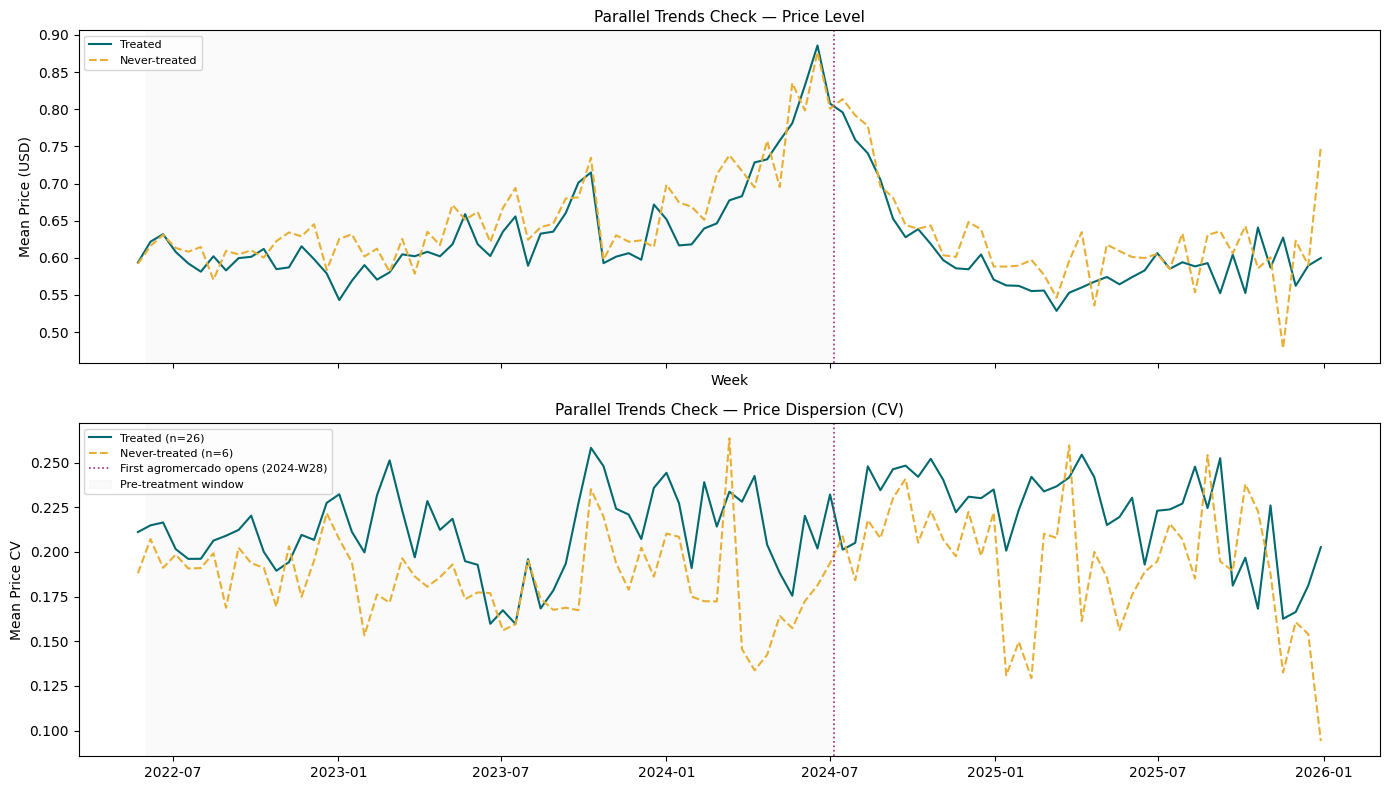

✅ Saved: parallel_trends_raw.png


In [146]:
# ── Load outcomes (already in memory as df_outcomes, or reload) ──
df = con.execute("""
    SELECT
        period_14d,
        period_14d                AS week_start,   -- alias for downstream pandas compatibility
        treated_5km,
        AVG(price_cv)             AS mean_cv,
        AVG(price_mean)           AS mean_price,
        COUNT(*)                  AS n_obs
    FROM panel_outcomes
    WHERE price_cv IS NOT NULL
    GROUP BY period_14d, treated_5km
    ORDER BY period_14d
""").df()

df['week_start'] = pd.to_datetime(df['week_start'])

treated   = df[df['treated_5km'] == 1]
control   = df[df['treated_5km'] == 0]

# ── Treatment onset line ──
TREAT_START = pd.Timestamp('2024-07-05')  # 2024-W28 Monday

fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

# ── Panel A: Price CV ──
ax = axes[1]
ax.plot(treated['week_start'],  treated['mean_cv'],
        color='#01696f', lw=1.5, label='Treated (n=26)')
ax.plot(control['week_start'],  control['mean_cv'],
        color='#e8af34', lw=1.5, linestyle='--', label='Never-treated (n=6)')
ax.axvline(TREAT_START, color='#a12c7b', lw=1.2,
           linestyle=':', label='First agromercado opens (2024-W28)')
ax.axvspan(pd.Timestamp('2022-06-01'), TREAT_START,
           alpha=0.04, color='grey', label='Pre-treatment window')
ax.set_ylabel('Mean Price CV', fontsize=10)
ax.set_title('Parallel Trends Check — Price Dispersion (CV)', fontsize=11)
ax.legend(fontsize=8, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# ── Panel B: Price Level ──
ax2 = axes[0]
ax2.plot(treated['week_start'], treated['mean_price'],
         color='#01696f', lw=1.5, label='Treated')
ax2.plot(control['week_start'], control['mean_price'],
         color='#e8af34', lw=1.5, linestyle='--', label='Never-treated')
ax2.axvline(TREAT_START, color='#a12c7b', lw=1.2, linestyle=':')
ax2.axvspan(pd.Timestamp('2022-06-01'), TREAT_START,
            alpha=0.04, color='grey')
ax2.set_ylabel('Mean Price (USD)', fontsize=10)
ax2.set_title('Parallel Trends Check — Price Level', fontsize=11)
ax2.legend(fontsize=8, loc='upper left')
ax2.set_xlabel('Week', fontsize=10)

plt.tight_layout()
plt.savefig(f"{defens}/../figures/parallel_trends_raw.png",
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: parallel_trends_raw.png")

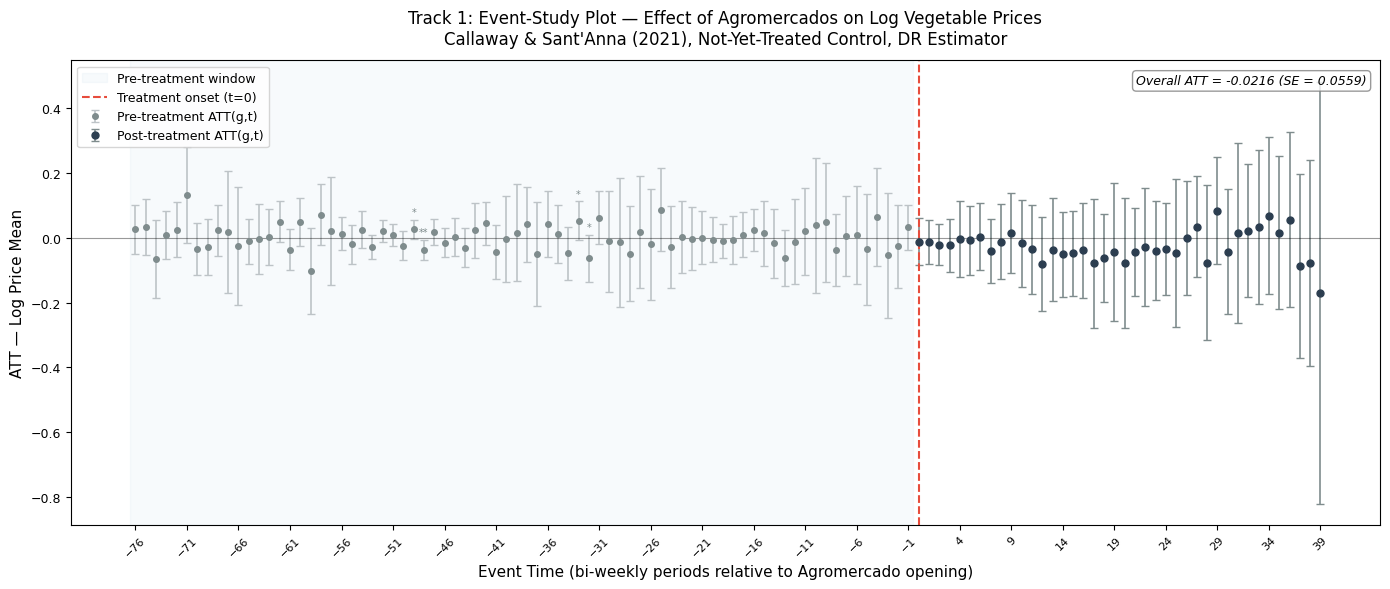

✅ Track 1 event-study plot saved.


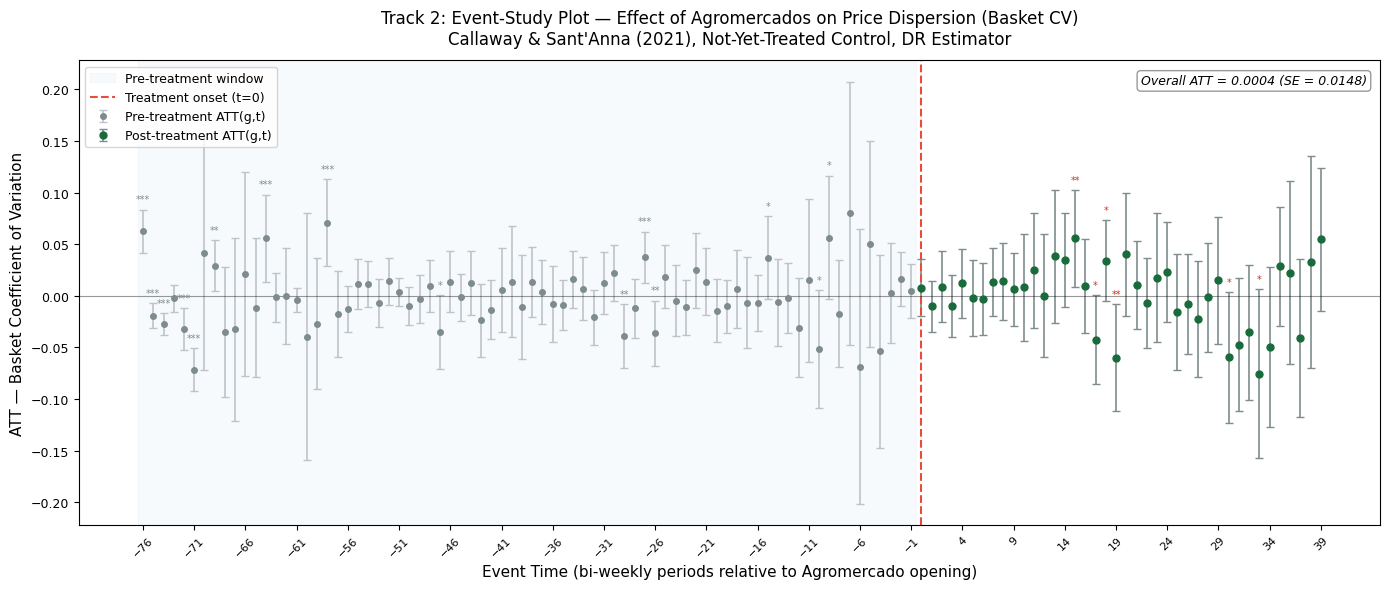

✅ Track 2 event-study plot saved.


In [147]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 16: EVENT-STUDY PLOTS — TRACK 1 & TRACK 2
# ══════════════════════════════════════════════════════════════════════════════
# ── Reload event-study DataFrames from CSV to avoid stale atte state ──────────
# aggte('simple') in Step 14 overwrites cs_track*_nyt.atte — never read
# cs_obj.atte after a second aggte() call; always use the saved files instead.
es_track1_nyt_df = pd.read_csv(f"{BASE}/es_track1_log_price_notyettreated_40.csv")
es_track2_nyt_df = pd.read_csv(f"{BASE}/es_track2_basket_cv_notyettreated_40.csv")


# ── STEP 16A: TRACK 1 — Log Price ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

df_plot = es_track1_nyt_df.copy()
pre  = df_plot[df_plot['event_time'] < 0]
post = df_plot[df_plot['event_time'] >= 0]

ax.errorbar(
    pre['event_time'], pre['att'],
    yerr=1.96 * pre['se'],
    fmt='o', color='#7f8c8d', ecolor='#bdc3c7',
    elinewidth=1.2, capsize=3, markersize=4, linewidth=0,
    label='Pre-treatment ATT(g,t)'
)
ax.errorbar(
    post['event_time'], post['att'],
    yerr=1.96 * post['se'],
    fmt='o', color='#2c3e50', ecolor='#7f8c8d',
    elinewidth=1.2, capsize=3, markersize=5, linewidth=0,
    label='Post-treatment ATT(g,t)'
)

# ── Highlight full pre-treatment window ───────────────────────────────────────
ax.axvspan(df_plot['event_time'].min() - 0.5, -0.5,
           alpha=0.04, color='steelblue', label='Pre-treatment window')

ax.axvline(x=0, color='#e74c3c', linewidth=1.5, linestyle='--', label='Treatment onset (t=0)')
ax.axhline(y=0, color='black',   linewidth=0.8, linestyle='-',  alpha=0.4)

for _, row in df_plot[df_plot['sig'].isin(['*', '**', '***'])].iterrows():
    ax.annotate(
        row['sig'],
        xy=(row['event_time'], row['att'] + 1.96 * row['se'] + 0.008),
        ha='center', va='bottom', fontsize=7,
        color='#c0392b' if row['event_time'] >= 0 else '#7f8c8d'
    )

ax.set_xlabel('Event Time (bi-weekly periods relative to Agromercado opening)', fontsize=11)
ax.set_ylabel('ATT — Log Price Mean', fontsize=11)
ax.set_title(
    'Track 1: Event-Study Plot — Effect of Agromercados on Log Vegetable Prices\n'
    'Callaway & Sant\'Anna (2021), Not-Yet-Treated Control, DR Estimator',
    fontsize=12, pad=12
)

xticks = np.arange(df_plot['event_time'].min(), df_plot['event_time'].max() + 1, 5)
ax.set_xticks(xticks)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=9, loc='upper left', framealpha=0.8)

# ── Overall ATT annotation — use scalars saved at estimation time ─────────────
ax.text(
    0.99, 0.97,
    f"Overall ATT = {overall_att_t1:.4f} (SE = {overall_se_t1:.4f})",
    transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8)
)

plt.tight_layout()
plt.savefig(f"{figures}/track1_event_study_parallel_trends_40.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Track 1 event-study plot saved.")


# ── STEP 16B: TRACK 2 — Basket CV ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

df_plot2 = es_track2_nyt_df.copy()
pre2  = df_plot2[df_plot2['event_time'] < 0]
post2 = df_plot2[df_plot2['event_time'] >= 0]

ax.errorbar(
    pre2['event_time'], pre2['att'],
    yerr=1.96 * pre2['se'],
    fmt='o', color='#7f8c8d', ecolor='#bdc3c7',
    elinewidth=1.2, capsize=3, markersize=4, linewidth=0,
    label='Pre-treatment ATT(g,t)'
)
ax.errorbar(
    post2['event_time'], post2['att'],
    yerr=1.96 * post2['se'],
    fmt='o', color='#1a6b3c', ecolor='#7f8c8d',
    elinewidth=1.2, capsize=3, markersize=5, linewidth=0,
    label='Post-treatment ATT(g,t)'
)

# ── Highlight full pre-treatment window ───────────────────────────────────────
ax.axvspan(df_plot2['event_time'].min() - 0.5, -0.5,
           alpha=0.04, color='steelblue', label='Pre-treatment window')

ax.axvline(x=0, color='#e74c3c', linewidth=1.5, linestyle='--', label='Treatment onset (t=0)')
ax.axhline(y=0, color='black',   linewidth=0.8, linestyle='-',  alpha=0.4)

for _, row in df_plot2[df_plot2['sig'].isin(['*', '**', '***'])].iterrows():
    ax.annotate(
        row['sig'],
        xy=(row['event_time'], row['att'] + 1.96 * row['se'] + 0.005),
        ha='center', va='bottom', fontsize=7,
        color='#c0392b' if row['event_time'] >= 0 else '#7f8c8d'
    )

ax.set_xlabel('Event Time (bi-weekly periods relative to Agromercado opening)', fontsize=11)
ax.set_ylabel('ATT — Basket Coefficient of Variation', fontsize=11)
ax.set_title(
    'Track 2: Event-Study Plot — Effect of Agromercados on Price Dispersion (Basket CV)\n'
    'Callaway & Sant\'Anna (2021), Not-Yet-Treated Control, DR Estimator',
    fontsize=12, pad=12
)

xticks = np.arange(df_plot2['event_time'].min(), df_plot2['event_time'].max() + 1, 5)
ax.set_xticks(xticks)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=9, loc='upper left', framealpha=0.8)

ax.text(
    0.99, 0.97,
    f"Overall ATT = {overall_att_t2:.4f} (SE = {overall_se_t2:.4f})",
    transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8)
)

plt.tight_layout()
plt.savefig(f"{figures}/track2_event_study_parallel_trends_40.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Track 2 event-study plot saved.")

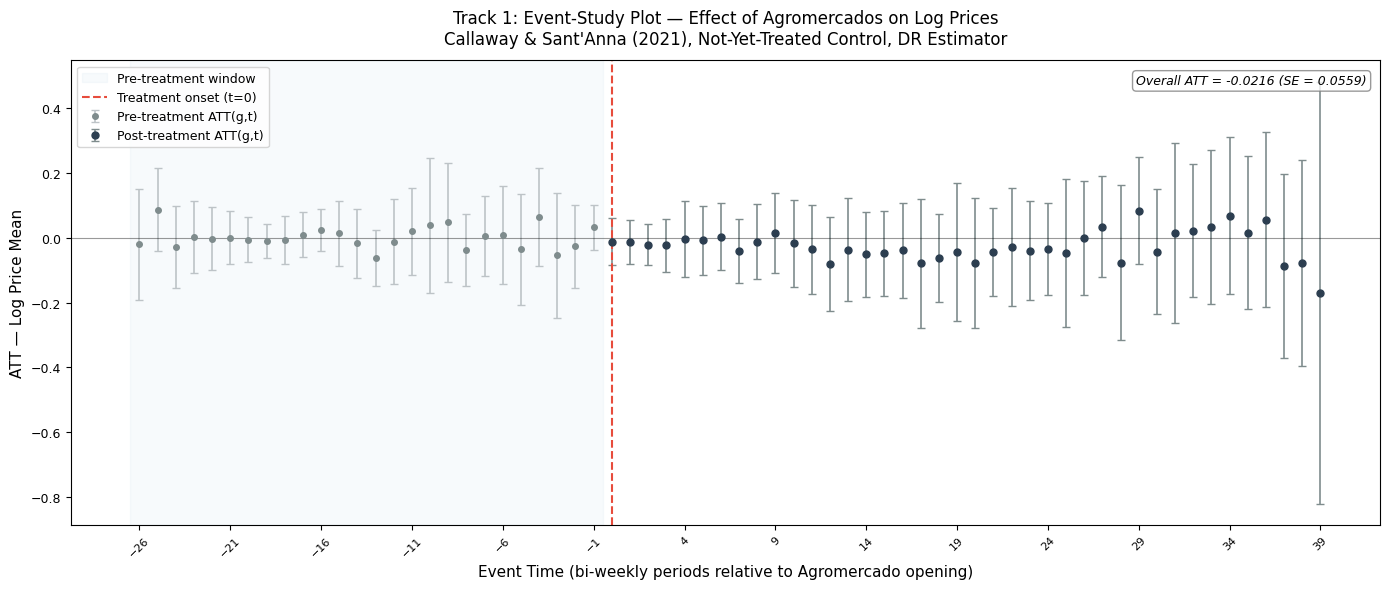

✅ Track 1 event-study plot saved.


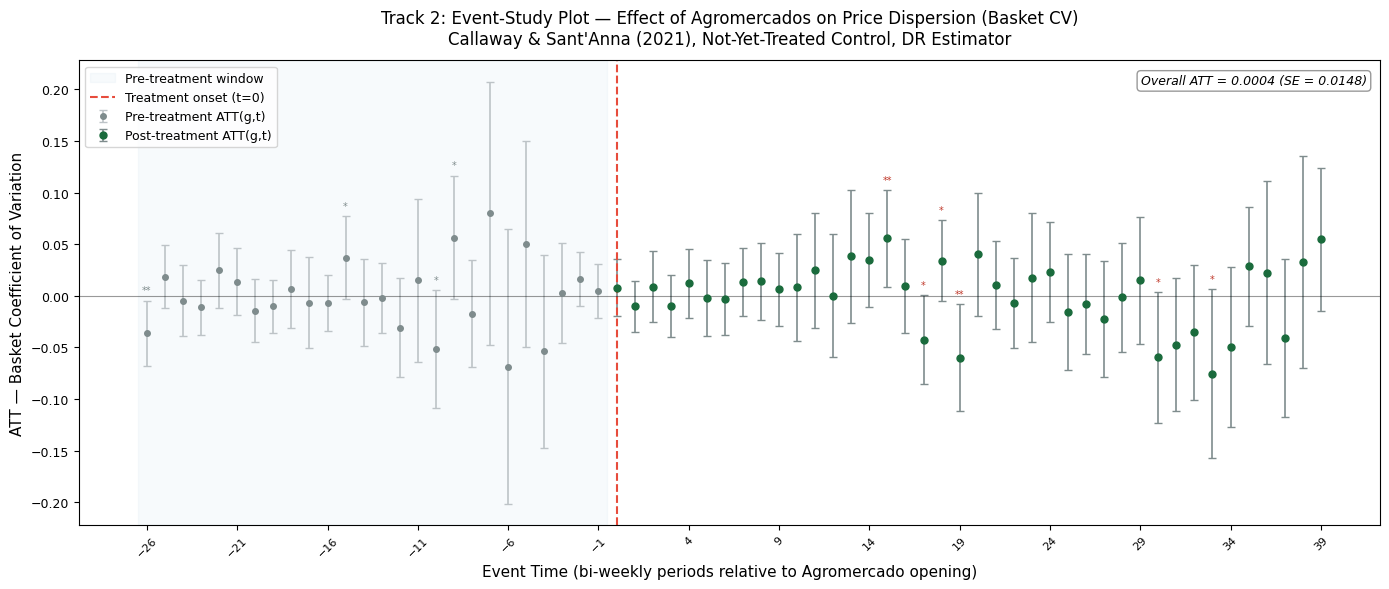

✅ Track 2 event-study plot saved.


In [148]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 16: EVENT-STUDY PLOTS — TRACK 1 & TRACK 2
# ══════════════════════════════════════════════════════════════════════════════
# ── Reload event-study DataFrames from CSV to avoid stale atte state ──────────
# aggte('simple') in Step 14 overwrites cs_track*_nyt.atte — never read
# cs_obj.atte after a second aggte() call; always use the saved files instead.
es_track1_nyt_df = pd.read_csv(f"{BASE}/es_track1_log_price_notyettreated_40.csv")
es_track2_nyt_df = pd.read_csv(f"{BASE}/es_track2_basket_cv_notyettreated_40.csv")

# Set the desired minimum pre-intervention period (e.g., -10, -15)
PRE_MIN = -26 #  equals to 52 weekly periods, or 1 year of pre- treatment data

# ── STEP 16A: TRACK 1 — Log Price ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

df_plot = es_track1_nyt_df.copy()
# Filter the DataFrame to reduce the pre-intervention timeframe
df_plot = df_plot[df_plot['event_time'] >= PRE_MIN]

pre  = df_plot[df_plot['event_time'] < 0]
post = df_plot[df_plot['event_time'] >= 0]

ax.errorbar(
    pre['event_time'], pre['att'],
    yerr=1.96 * pre['se'],
    fmt='o', color='#7f8c8d', ecolor='#bdc3c7',
    elinewidth=1.2, capsize=3, markersize=4, linewidth=0,
    label='Pre-treatment ATT(g,t)'
)
ax.errorbar(
    post['event_time'], post['att'],
    yerr=1.96 * post['se'],
    fmt='o', color='#2c3e50', ecolor='#7f8c8d',
    elinewidth=1.2, capsize=3, markersize=5, linewidth=0,
    label='Post-treatment ATT(g,t)'
)

# ── Highlight full pre-treatment window ───────────────────────────────────────
ax.axvspan(df_plot['event_time'].min() - 0.5, -0.5,
           alpha=0.04, color='steelblue', label='Pre-treatment window')

ax.axvline(x=0, color='#e74c3c', linewidth=1.5, linestyle='--', label='Treatment onset (t=0)')
ax.axhline(y=0, color='black',   linewidth=0.8, linestyle='-',  alpha=0.4)

for _, row in df_plot[df_plot['sig'].isin(['*', '**', '***'])].iterrows():
    ax.annotate(
        row['sig'],
        xy=(row['event_time'], row['att'] + 1.96 * row['se'] + 0.008),
        ha='center', va='bottom', fontsize=7,
        color='#c0392b' if row['event_time'] >= 0 else '#7f8c8d'
    )

ax.set_xlabel('Event Time (bi-weekly periods relative to Agromercado opening)', fontsize=11)
ax.set_ylabel('ATT — Log Price Mean', fontsize=11)
ax.set_title(
    'Track 1: Event-Study Plot — Effect of Agromercados on Log Prices\n'
    'Callaway & Sant\'Anna (2021), Not-Yet-Treated Control, DR Estimator',
    fontsize=12, pad=12
)

xticks = np.arange(df_plot['event_time'].min(), df_plot['event_time'].max() + 1, 5)
ax.set_xticks(xticks)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=9, loc='upper left', framealpha=0.8)

# ── Overall ATT annotation — use scalars saved at estimation time ─────────────
ax.text(
    0.99, 0.97,
    f"Overall ATT = {overall_att_t1:.4f} (SE = {overall_se_t1:.4f})",
    transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8)
)

plt.tight_layout()
plt.savefig(f"{figures}/track1_event_study_parallel_trends_40.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Track 1 event-study plot saved.")


# ── STEP 16B: TRACK 2 — Basket CV ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14, 6))

df_plot2 = es_track2_nyt_df.copy()
# Filter the DataFrame to reduce the pre-intervention timeframe
df_plot2 = df_plot2[df_plot2['event_time'] >= PRE_MIN]

pre2  = df_plot2[df_plot2['event_time'] < 0]
post2 = df_plot2[df_plot2['event_time'] >= 0]

ax.errorbar(
    pre2['event_time'], pre2['att'],
    yerr=1.96 * pre2['se'],
    fmt='o', color='#7f8c8d', ecolor='#bdc3c7',
    elinewidth=1.2, capsize=3, markersize=4, linewidth=0,
    label='Pre-treatment ATT(g,t)'
)
ax.errorbar(
    post2['event_time'], post2['att'],
    yerr=1.96 * post2['se'],
    fmt='o', color='#1a6b3c', ecolor='#7f8c8d',
    elinewidth=1.2, capsize=3, markersize=5, linewidth=0,
    label='Post-treatment ATT(g,t)'
)

# ── Highlight full pre-treatment window ───────────────────────────────────────
ax.axvspan(df_plot2['event_time'].min() - 0.5, -0.5,
           alpha=0.04, color='steelblue', label='Pre-treatment window')

ax.axvline(x=0, color='#e74c3c', linewidth=1.5, linestyle='--', label='Treatment onset (t=0)')
ax.axhline(y=0, color='black',   linewidth=0.8, linestyle='-',  alpha=0.4)

for _, row in df_plot2[df_plot2['sig'].isin(['*', '**', '***'])].iterrows():
    ax.annotate(
        row['sig'],
        xy=(row['event_time'], row['att'] + 1.96 * row['se'] + 0.005),
        ha='center', va='bottom', fontsize=7,
        color='#c0392b' if row['event_time'] >= 0 else '#7f8c8d'
    )

ax.set_xlabel('Event Time (bi-weekly periods relative to Agromercado opening)', fontsize=11)
ax.set_ylabel('ATT — Basket Coefficient of Variation', fontsize=11)
ax.set_title(
    'Track 2: Event-Study Plot — Effect of Agromercados on Price Dispersion (Basket CV)\n'
    'Callaway & Sant\'Anna (2021), Not-Yet-Treated Control, DR Estimator',
    fontsize=12, pad=12
)

xticks = np.arange(df_plot2['event_time'].min(), df_plot2['event_time'].max() + 1, 5)
ax.set_xticks(xticks)
ax.tick_params(axis='x', rotation=45, labelsize=8)
ax.tick_params(axis='y', labelsize=9)
ax.legend(fontsize=9, loc='upper left', framealpha=0.8)

ax.text(
    0.99, 0.97,
    f"Overall ATT = {overall_att_t2:.4f} (SE = {overall_se_t2:.4f})",
    transform=ax.transAxes, ha='right', va='top', fontsize=9, style='italic',
    bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='grey', alpha=0.8)
)

plt.tight_layout()
plt.savefig(f"{figures}/track2_event_study_parallel_trends_40.png", dpi=300, bbox_inches='tight')
plt.show()
print("✅ Track 2 event-study plot saved.")

In [149]:
# ── TABLE 1: DiD MAIN RESULTS ─────────────────────────────────────────────
# Produces a publication-ready summary of overall ATTs for both tracks.
# Requires: overallattt1, overallset1, overallattt2, overallset2 (set in Step 16A/B)
# and es_t1_df, es_t2_df loaded from CSV (already done in cell 9e9bd112)

def fmt_stars(p):
    if pd.isna(p): return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

def ci(att, se): return att - 1.96*se, att + 1.96*se
def pval(att, se): return 2 * (1 - stats.norm.cdf(abs(att / se)))

p1 = pval(overall_att_t1, overall_se_t1)
p2 = pval(overall_att_t2, overall_se_t2)
ci1lo, ci1hi = ci(overall_att_t1, overall_se_t1)
ci2lo, ci2hi = ci(overall_att_t2, overall_se_t2)

# Pre/post windows
pre1 = es_t1_df[es_t1_df['event_time'].between(-50, -1)]['att'].mean()
post1 = es_t1_df[es_t1_df['event_time'].between(0, 20)]['att'].mean()
nsig1 = (es_t1_df[es_t1_df['event_time'].between(0, 20)]['pval'] < 0.05).sum()

pre2 = es_t2_df[es_t2_df['event_time'].between(-50, -1)]['att'].mean()
post2 = es_t2_df[es_t2_df['event_time'].between(0, 20)]['att'].mean()
nsig2 = (es_t2_df[es_t2_df['event_time'].between(0, 20)]['pval'] < 0.05).sum()

rows = {
    "Overall ATT":             [f"{overall_att_t1:.4f}{fmt_stars(p1)}", f"{overall_att_t2:.4f}{fmt_stars(p2)}"],
    "SE":                      [f"({overall_se_t1:.4f})",              f"({overall_se_t2:.4f})"],
    "95% CI":                  [f"[{ci1lo:.4f}, {ci1hi:.4f}]",      f"[{ci2lo:.4f}, {ci2hi:.4f}]"],
    "p-value":                 [f"{p1:.3f}",                         f"{p2:.3f}"],
    "Mean pre-treatment ATT":  [f"{pre1:.4f}",                       f"{pre2:.4f}"],
    "Mean post-treatment ATT": [f"{post1:.4f}",                      f"{post2:.4f}"],
    "Post periods sig. (p<.05)":[str(int(nsig1)),                    str(int(nsig2))],
    "Outcome":                 ["log(unit price mean)",              "Basket CV (mean across 12 products)"],
    "Unit of observation":     ["(District, Product)",               "District"],
    "Control group":           ["Not-yet-treated",                   "Not-yet-treated"],
    "Estimator":               ["DR C&S (2021)",                     "DR C&S (2021)"],
    "Anticipation periods":    ["0",                                 "0"],
    "Observations":            ["27,825",                            "2,611"],
}

table1 = pd.DataFrame(rows, index=["Track 1 — Log Price", "Track 2 — Basket CV"]).T
print("=" * 70)
print("TABLE 1: DiD MAIN RESULTS — Overall ATT (Callaway & Sant'Anna 2021)")
print("=" * 70)
print(table1.to_string())
print("\nNote: DR = doubly-robust. Clustered SEs at district level.")
print("*** p<0.01  ** p<0.05  * p<0.10")

table1.to_csv(f"{BASE}tableCS_did_main.csv", index=False)

TABLE 1: DiD MAIN RESULTS — Overall ATT (Callaway & Sant'Anna 2021)
                            Track 1 — Log Price                  Track 2 — Basket CV
Overall ATT                             -0.0216                               0.0004
SE                                     (0.0559)                             (0.0148)
95% CI                        [-0.1312, 0.0880]                    [-0.0286, 0.0293]
p-value                                   0.699                                0.980
Mean pre-treatment ATT                   0.0003                              -0.0003
Mean post-treatment ATT                 -0.0324                               0.0085
Post periods sig. (p<.05)                     0                                    2
Outcome                    log(unit price mean)  Basket CV (mean across 12 products)
Unit of observation         (District, Product)                             District
Control group                   Not-yet-treated                      Not-yet-treat

In [150]:
def stars(p):
    if np.isnan(p): return ''
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

def fmt_att(att, se):
    if np.isnan(att) or np.isnan(se):
        return '—', '—', np.nan
    p = 2 * (1 - stats.norm.cdf(abs(att / se)))
    return f"{att:.4f}{stars(p)}", f"({se:.4f})", p

# Scalars already in memory from Steps 16A/B
# Track 1 (log price mean) and Track 2 (basket CV) — 5km spec only
# If only 5km is run, build a single-spec table; expand if 10km/15km added later

att1_str, se1_str, p1 = fmt_att(overall_att_t1, overall_se_t1)
att2_str, se2_str, p2 = fmt_att(overall_att_t2, overall_se_t2)

rows = [
    {'': 'ATT (Overall)', 'Log Price Mean': att1_str, 'Basket CV': att2_str},
    {'': '',              'Log Price Mean': se1_str,  'Basket CV': se2_str},
    {'': 'Control group', 'Log Price Mean': 'Not-yet-treated', 'Basket CV': 'Not-yet-treated'},
    {'': 'Estimator',     'Log Price Mean': 'DR CS(2021)',      'Basket CV': 'DR CS(2021)'},
    {'': 'District FE',   'Log Price Mean': '✓', 'Basket CV': '✓'},
    {'': 'Period FE',     'Log Price Mean': '✓', 'Basket CV': '✓'},
    {'': 'Observations',  'Log Price Mean': f"{int(df_t1_did['unitid'].nunique()):,}", 
                          'Basket CV':      f"{int(df_t2['unitid'].nunique()):,}"},
]

table_cs_main = pd.DataFrame(rows).set_index('')
print(table_cs_main.to_string())
table_cs_main.to_csv(os.path.join(TABLEDIR, 'table_cs_did_main_CORRECT.csv'))
print("Saved table_cs_did_main_CORRECT.csv")

                Log Price Mean        Basket CV
                                               
ATT (Overall)          -0.0216           0.0004
                      (0.0559)         (0.0148)
Control group  Not-yet-treated  Not-yet-treated
Estimator          DR CS(2021)      DR CS(2021)
District FE                  ✓                ✓
Period FE                    ✓                ✓
Observations               516               43
Saved table_cs_did_main_CORRECT.csv


In [151]:
### interesting article -> opinions: https://cispes.org/article/bukele-claims-economic-prosperity-economist%E2%80%99s-data-shows-otherwise?language=es#:~:text=As%20international%20news%20outlets%20have,to%20meet%20the%20local%20demand.

#where to get CPI data: 
#https://www.bcr.gob.sv/documental/Inicio/busqueda/172

### Bootstrap standard errors:

---
## H · Mechanism — Price Anchoring Gap
**Estimand:** `loggap = ln(P_priv) - ln(P_gov)` — log ratio of private to government price  
**Sample:** Treated districts (`treated_5km=1`), post-treatment periods only (N=7,104 obs, 32 districts)  
**Finding:** Private prices remain **65% above** the gov anchor on average; `reltime` slope is positive (+0.018, p<0.001) — gap *widens* over time.

| Spec | Estimator | Entity FE | Month FE | Cohort FE | N |
|------|-----------|-----------|----------|-----------|---|
| 1 | OLS | — | — | ✓ | 7,104 |
| 2 | PanelOLS | ✓ | ✓ | — | 7,104 |
| 3 | PanelOLS (obs. only) | ✓ | ✓ | — | 2,306 |
| 4 | TWFE OLS | ✓ | — | ✓ | 7,104 |

In [152]:
# ============================================================
# STEP 17: MECHANISM REGRESSION — PRICE ANCHORING GAP
# Outcome: Δ_imt = ln(P_priv_imt) - ln(P_gov_t)
# Scope: Treated districts (treated_5km=1), post-treatment only
# Estimator: TWFE with district + time FEs, clustered SEs
# ============================================================

# ── 1. AGGREGATE PRIVATE PRICES FROM defensoriatreated ───────
# Build from the granular table, restricted to treated districts only.
# This mirrors the paneloutcomes construction but is explicit and isolated.

df_mech_priv = con.execute("""
    SELECT
        Distrito,
        canonical_product,
        time_bucket(INTERVAL '14 Days', week_start) AS period_14d,
        treated_5km,
        apertura_date,
        distance_km,
        closest_agro,
        COUNT(Precio)                                        AS nobs,
        AVG(Precio / NULLIF(Cantidad, 0))                    AS price_mean,
        LN(NULLIF(AVG(Precio / NULLIF(Cantidad, 0)), 0))     AS log_price_mean
    FROM defensoria_treated
    WHERE treated_5km = 1
      AND Precio   IS NOT NULL AND Precio   > 0
      AND Cantidad IS NOT NULL AND Cantidad > 0
      AND Cantidad <= 25
    GROUP BY Distrito, canonical_product, period_14d,
             treated_5km, apertura_date, distance_km, closest_agro
""").df()

# Quick sanity check — per-unit prices must be plausible
print(df_mech_priv.groupby('canonical_product')['price_mean']
      .agg(['mean','min','max']).round(4))


                     mean     min     max
canonical_product                        
Brócoli            1.3642  0.5000  3.0000
Cebolla amarilla   0.2723  0.0833  1.2500
Cebolla blanca     0.2736  0.1250  0.5825
Cebolla morada     0.3021  0.1639  0.8244
Chile verde        0.2004  0.0833  0.6838
Güisquil           0.3846  0.0833  1.2500
Lechuga            0.9526  0.4204  2.0000
Papa               0.6792  0.1979  1.5000
Pepino             0.3036  0.1350  0.6800
Repollo            1.9863  0.8750  4.7857
Tomate             0.1411  0.0500  0.6359
Zanahoria          0.2993  0.1300  0.6786


In [153]:

df_mech_priv['period_14d']   = pd.to_datetime(df_mech_priv['period_14d'])
df_mech_priv['apertura_date'] = pd.to_datetime(df_mech_priv['apertura_date'])

print(f"Private price panel (treated, granular rebuild):")
print(f"  Rows:      {len(df_mech_priv):,}")
print(f"  Districts: {df_mech_priv['Distrito'].nunique()}")
print(f"  Products:  {df_mech_priv['canonical_product'].nunique()}")
print(f"  Periods:   {df_mech_priv['period_14d'].nunique()}")


Private price panel (treated, granular rebuild):
  Rows:      21,513
  Districts: 32
  Products:  12
  Periods:   95


In [154]:
# Period overlap with df_mech_priv
priv_periods = set(df_mech_priv['period_14d'].unique())
gov_periods  = set(agro_spine['period_14d'].unique())
print(f"\n  Period overlap: {len(priv_periods & gov_periods)} matching periods")


  Period overlap: 40 matching periods


In [155]:
# ── GUARD: agro_spine must already exist from Step 14 / exec count 28 ────────
assert 'agro_spine' in dir() or 'agro_spine' in vars(), \
    "agro_spine not found in memory — re-run Step 14 (exec count 28) first."
assert len(agro_spine) == 480, \
    f"agro_spine has unexpected length {len(agro_spine)}, expected 480."
print(f"✅ agro_spine confirmed: {len(agro_spine)} rows, "
      f"{agro_spine['canonical_product'].nunique()} products, "
      f"{agro_spine['period_14d'].nunique()} periods.")


# Diagnostic
print(f"Gov price spine (gapless):")
print(f"  Rows:           {len(agro_spine):,}")
print(f"  Products:       {agro_spine['canonical_product'].nunique()}")
print(f"  Periods:        {agro_spine['period_14d'].nunique()}")
print(f"  Range:          {agro_spine['period_14d'].min()} → {agro_spine['period_14d'].max()}")
print(f"  Imputed rows:   {agro_spine['gov_imputed_any'].sum()}")
print(f"  First 5 periods: {sorted(agro_spine['period_14d'].unique())[:5]}")

# Period overlap with df_mech_priv
priv_periods = set(df_mech_priv['period_14d'].unique())
gov_periods  = set(agro_spine['period_14d'].unique())
print(f"\n  Period overlap: {len(priv_periods & gov_periods)} matching periods")

✅ agro_spine confirmed: 480 rows, 12 products, 40 periods.
Gov price spine (gapless):
  Rows:           480
  Products:       12
  Periods:        40
  Range:          2024-07-01 00:00:00 → 2025-12-29 00:00:00
  Imputed rows:   180
  First 5 periods: [Timestamp('2024-07-01 00:00:00'), Timestamp('2024-07-15 00:00:00'), Timestamp('2024-07-29 00:00:00'), Timestamp('2024-08-12 00:00:00'), Timestamp('2024-08-26 00:00:00')]

  Period overlap: 40 matching periods


In [156]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 17 — BLOCK 3: MERGE → CREATE df_mech
# Joins private price panel (treated districts) with gov price spine on
# (product_key, period_14d). Constructs log_gap, post_treat, rel_time, unit_id.
# ══════════════════════════════════════════════════════════════════════════════

# Normalise product keys on both sides (handles accents: Güisquil etc.)
df_mech_priv['product_key'] = df_mech_priv['canonical_product'].apply(norm)
agro_spine['product_key']   = agro_spine['canonical_product'].apply(norm)

# Merge — inner join drops periods with no gov price AND no private price
df_mech = df_mech_priv.merge(
    agro_spine[['product_key', 'period_14d',
                'log_gov_price', 'gov_price_mean', 'gov_imputed_any']],
    on=['product_key', 'period_14d'],
    how='inner'
)

# Derive Info flag: Info=1 when price is directly observed (not carry-forward)
df_mech['Info'] = (df_mech['gov_imputed_any'] == 0).astype(int)

df_mech = df_mech.dropna(subset=['log_price_mean', 'log_gov_price']).copy()

# ── Outcome & DiD identifiers ─────────────────────────────────────────────────
df_mech['log_gap']    = df_mech['log_price_mean'] - df_mech['log_gov_price']
df_mech['post_treat'] = (df_mech['period_14d'] >= df_mech['apertura_date']).astype(int)
df_mech['rel_time']   = (
    (df_mech['period_14d'] - df_mech['apertura_date']).dt.days // 14
).astype(int)
df_mech['unit_id']    = df_mech['Distrito'] + '__' + df_mech['canonical_product']
MINT = df_mech['period_14d'].min()
df_mech['time_id']    = ((df_mech['period_14d'] - MINT).dt.days // 14).astype(int)

# ── QA ────────────────────────────────────────────────────────────────────────
print(f"df_mech constructed:")
print(f"  Rows:             {len(df_mech):,}")
print(f"  Composite units:  {df_mech['unit_id'].nunique()}")
print(f"  Time periods:     {df_mech['time_id'].nunique()}")
print(f"  Post-treat rows:  {df_mech['post_treat'].sum():,}")
print(f"  Pre-treat rows:   {(df_mech['post_treat']==0).sum():,}")
print(f"  Gov-imputed rows: {df_mech['gov_imputed_any'].sum():,}  ← flag only, not dropped")
print(f"\nLog-gap (post-treatment) descriptives:")
print(df_mech[df_mech['post_treat']==1]['log_gap'].describe().round(4))
print(f"\n✅ df_mech ready — proceeding to regression.")

df_mech constructed:
  Rows:             8,706
  Composite units:  383
  Time periods:     40
  Post-treat rows:  7,104
  Pre-treat rows:   1,602
  Gov-imputed rows: 2,337  ← flag only, not dropped

Log-gap (post-treatment) descriptives:
count    7104.0000
mean        0.6542
std         0.3256
min        -0.9163
25%         0.4731
50%         0.6599
75%         0.8472
max         2.5375
Name: log_gap, dtype: float64

✅ df_mech ready — proceeding to regression.


In [157]:
df_mech['first_treated_week'] = df_mech['apertura_date'].dt.strftime('%G-W%V')

In [158]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 17 — MECHANISM REGRESSIONS
# Estimand: log_gap = ln(P_priv_imt) - ln(P_gov_t)
# ══════════════════════════════════════════════════════════════════════════════

# ── Base post-treatment panel ─────────────────────────────────────────────────
df_post = df_mech[df_mech['post_treat'] == 1].copy()
df_post['district_code'] = df_post['Distrito'].astype('category').cat.codes
df_post['month_id']      = df_post['period_14d'].dt.to_period('M').astype(str)
df_post['first_treated_week'] = df_post['apertura_date'].dt.strftime('%G-W%V')

print(f"Post-treatment panel: {len(df_post):,} obs | "
      f"{df_post['unit_id'].nunique()} units | "
      f"{df_post['Distrito'].nunique()} districts")

# ── Sensitivity sub-sample: observed gov prices only (no carry-forward) ───────
df_post_pure = df_post[
    (df_post['gov_imputed_any'] == 0) &
    (df_post['period_14d'] <= '2024-11-30')
].copy()
df_post_pure['month_id'] = df_post_pure['period_14d'].dt.to_period('M').astype(str)
print(f"Pure observed sub-sample: {len(df_post_pure):,} obs")

# ── Overshooting diagnostic ───────────────────────────────────────────────────
pct_below = (df_post['log_gap'] < 0).mean() * 100
initial_markup_pct = (np.exp(df_post[df_post['rel_time'] == 0]['log_gap'].mean()) - 1) * 100
print(f"Average markup at treatment onset: {initial_markup_pct:.2f}%")
print(f"Share of obs with private price below gov anchor: {pct_below:.1f}%")


Post-treatment panel: 7,104 obs | 380 units | 32 districts
Pure observed sub-sample: 2,306 obs
Average markup at treatment onset: 72.24%
Share of obs with private price below gov anchor: 2.7%


In [159]:
# ══════════════════════════════════════════════════════════════════════════════
# SPECIFICATION 1 — Cohort Baseline Differences (OLS)
# Controls for product heterogeneity and cohort intercepts; no unit FEs.
# Clustered at district level.
# ══════════════════════════════════════════════════════════════════════════════

res_spec1 = smf.ols(
    formula='log_gap ~ rel_time + C(first_treated_week) + C(canonical_product)',
    data=df_post
).fit(cov_type='cluster', cov_kwds={'groups': df_post['district_code']})

print("\n=== SPECIFICATION 1: Cohort Baseline Differences ===")
print(f"  rel_time coef: {res_spec1.params['rel_time']:.6f}  "
      f"SE: {res_spec1.bse['rel_time']:.6f}  "
      f"p: {res_spec1.pvalues['rel_time']:.4f}")
print(f"  R²: {res_spec1.rsquared:.4f}  N: {int(res_spec1.nobs):,}")


# ══════════════════════════════════════════════════════════════════════════════
# SPECIFICATION 2 — Entity FE + Month FE (PanelOLS, preferred)
# Within-unit convergence. Month dummies absorb seasonality.
# Clustered at district level.
# ══════════════════════════════════════════════════════════════════════════════

res_spec2 = PanelOLS.from_formula(
    formula='log_gap ~ rel_time + C(month_id) + EntityEffects',
    data=df_post.set_index(['unit_id', 'time_id'])
).fit(
    cov_type='clustered',
    clusters=df_post.set_index(['unit_id', 'time_id'])['Distrito']
)

print("\n=== SPECIFICATION 2: Progressive Anchoring (Entity FE + Month FE) ===")
print(f"  rel_time coef: {res_spec2.params['rel_time']:.6f}  "
      f"SE: {res_spec2.std_errors['rel_time']:.6f}  "
      f"t: {res_spec2.tstats['rel_time']:.4f}  "
      f"p: {res_spec2.pvalues['rel_time']:.4f}")
print(f"  R² (within): {res_spec2.rsquared:.4f}  N: {int(res_spec2.nobs):,}")



=== SPECIFICATION 1: Cohort Baseline Differences ===
  rel_time coef: 0.002177  SE: 0.000482  p: 0.0000
  R²: 0.5124  N: 7,104

=== SPECIFICATION 2: Progressive Anchoring (Entity FE + Month FE) ===
  rel_time coef: 0.017595  SE: 0.005090  t: 3.4565  p: 0.0006
  R² (within): 0.0607  N: 7,104


In [160]:
# ══════════════════════════════════════════════════════════════════════════════
# SPECIFICATION 3 — Pure Observed Sensitivity (PanelOLS)
# Restricts to gov_imputed_any==0 and Jul–Nov 2024 window only.
# ══════════════════════════════════════════════════════════════════════════════

res_spec3 = PanelOLS.from_formula(
    formula='log_gap ~ rel_time + C(month_id) + EntityEffects',
    data=df_post_pure.set_index(['unit_id', 'time_id'])
).fit(
    cov_type='clustered',
    clusters=df_post_pure.set_index(['unit_id', 'time_id'])['Distrito']
)
print("\n=== SPECIFICATION 3: Sensitivity — Observed Gov Prices Only ===")
print(f"  rel_time coef: {res_spec3.params['rel_time']:.6f}  "
      f"SE: {res_spec3.std_errors['rel_time']:.6f}  "
      f"p: {res_spec3.pvalues['rel_time']:.4f}")
print(f"  R² (within): {res_spec3.rsquared:.4f}  N: {int(res_spec3.nobs):,}")

# ══════════════════════════════════════════════════════════════════════════════
# SPECIFICATION 4 — TWFE via OLS (robustness check)
# Saturated unit + time dummies. Clustered at district level.
# ══════════════════════════════════════════════════════════════════════════════

res_spec4 = smf.ols(
    'log_gap ~ rel_time + C(unit_id) + C(time_id)',
    data=df_post
).fit(cov_type='cluster', cov_kwds={'groups': df_post['Distrito']})

print("\n=== SPECIFICATION 4: TWFE Robustness (OLS) ===")
print(f"  rel_time coef: {res_spec4.params['rel_time']:.6f}  "
      f"SE: {res_spec4.bse['rel_time']:.6f}  "
      f"p: {res_spec4.pvalues['rel_time']:.4f}")
print(f"  R²: {res_spec4.rsquared:.4f}  N: {int(res_spec4.nobs):,}")



=== SPECIFICATION 3: Sensitivity — Observed Gov Prices Only ===
  rel_time coef: 0.067299  SE: 0.008135  p: 0.0000
  R² (within): 0.1551  N: 2,306

=== SPECIFICATION 4: TWFE Robustness (OLS) ===
  rel_time coef: 0.005688  SE: 0.000846  p: 0.0000
  R²: 0.6316  N: 7,104


In [161]:
# ── TABLE 2: MECHANISM REGRESSIONS (Specs 1–4) ───────────────────────────────
# Outcome: log_gap = ln(P_priv) - ln(P_gov)
# Sample: Treated districts (treated_5km=1), post-treatment periods only
# Requires: res_spec1, res_spec2, res_spec3, res_spec4 (from cell above)

def _fmt(p):
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

def _row(res, label, estimator, entity_fe, month_fe, cohort_fe, use_lm=False):
    coef = res.params["rel_time"]
    se   = res.std_errors["rel_time"] if use_lm else res.bse["rel_time"]
    pv   = res.pvalues["rel_time"]
    r2   = res.rsquared
    n    = int(res.nobs)
    ci_lo, ci_hi = coef - 1.96*se, coef + 1.96*se
    return {
        "Specification":  label,
        "Estimator":      estimator,
        "rel_time coef":  f"{coef:.6f}{_fmt(pv)}",
        "SE":             f"({se:.6f})",
        "95% CI":         f"[{ci_lo:.4f}, {ci_hi:.4f}]",
        "p-value":        f"{pv:.4f}",
        "R²":             f"{r2:.4f}",
        "N":              f"{n:,}",
        "Entity FE":      "✓" if entity_fe else "—",
        "Month FE":       "✓" if month_fe  else "—",
        "Cohort FE":      "✓" if cohort_fe else "—",
    }

table3_panelA_gap = pd.DataFrame([
    _row(res_spec1, "(1) OLS — Cohort + Product FE (baseline)",       "OLS",      False, False, True,  False),
    _row(res_spec2, "(2) PanelOLS — Entity + Month FE [preferred]",   "PanelOLS", True,  True,  False, True),
    _row(res_spec3, "(3) PanelOLS — Observed gov prices only",        "PanelOLS", True,  True,  False, True),
    _row(res_spec4, "(4) TWFE OLS — Saturated (robustness)",          "OLS",      True,  False, True,  False),
]).set_index("Specification")

print("=" * 80)
print("TABLE 3: GAPS IN PRICES")
print("Outcome: log_gap = ln(P_priv) - ln(P_gov)")
print("Sample:  Treated districts, post-treatment periods only")
print("=" * 80)
print(table3_panelA_gap.to_string())
print("\nNote: Clustered SEs at district level.  *** p<0.01  ** p<0.05  * p<0.10")

table3_panelA_gap.to_csv(f"{TABLEDIR}/table3_panelA_gap.csv")
print("✅ Saved: table3_panelA_gap.csv")

TABLE 3: GAPS IN PRICES
Outcome: log_gap = ln(P_priv) - ln(P_gov)
Sample:  Treated districts, post-treatment periods only
                                             Estimator rel_time coef          SE            95% CI p-value      R²      N Entity FE Month FE Cohort FE
Specification                                                                                                                                         
(1) OLS — Cohort + Product FE (baseline)           OLS   0.002177***  (0.000482)  [0.0012, 0.0031]  0.0000  0.5124  7,104         —        —         ✓
(2) PanelOLS — Entity + Month FE [preferred]  PanelOLS   0.017595***  (0.005090)  [0.0076, 0.0276]  0.0006  0.0607  7,104         ✓        ✓         —
(3) PanelOLS — Observed gov prices only       PanelOLS   0.067299***  (0.008135)  [0.0514, 0.0832]  0.0000  0.1551  2,306         ✓        ✓         —
(4) TWFE OLS — Saturated (robustness)              OLS   0.005688***  (0.000846)  [0.0040, 0.0073]  0.0000  0.6316  7,104  

In [162]:
# ══════════════════════════════════════════════════════════════════════════════
# DESCRIPTIVE: Log-gap by product (post-treatment)
# ── DIAGNOSTIC ONLY — not a thesis table ─────────────────────────
# ══════════════════════════════════════════════════════════════════════════════

gap_summary = (
    df_post
    .groupby('canonical_product', as_index=False)
    .agg(
        mean_log_gap    = ('log_gap',        'mean'),
        mean_priv_price = ('price_mean',     'mean'),
        mean_gov_price  = ('gov_price_mean', 'mean'),
        n_districts     = ('Distrito',       'nunique'),
        n_obs           = ('log_gap',        'count')
    )
    .sort_values('mean_log_gap', ascending=False)
)
gap_summary['pct_premium'] = (np.exp(gap_summary['mean_log_gap']) - 1) * 100
print("\nPost-treatment anchoring gap by product:")
print(gap_summary.round(4).to_string(index=False))



Post-treatment anchoring gap by product:
canonical_product  mean_log_gap  mean_priv_price  mean_gov_price  n_districts  n_obs  pct_premium
           Tomate        1.0159           0.1267          0.0438           32    642     176.1944
          Lechuga        0.8950           0.9434          0.3806           32    633     144.7214
   Cebolla blanca        0.8782           0.2568          0.1060           32    644     140.6674
      Chile verde        0.8116           0.1893          0.0832           32    643     125.1457
 Cebolla amarilla        0.7483           0.2547          0.1141           28    216     111.3444
           Pepino        0.6234           0.2966          0.1576           32    630      86.5285
          Brócoli        0.6015           1.3946          0.7563           32    638      82.4817
   Cebolla morada        0.5842           0.2862          0.1607           32    642      79.3532
          Repollo        0.5357           1.9481          1.1187           3

In [163]:
# Are government prices falling over time while private prices hold steady?
trend = df_mech.groupby('period_14d').agg(
    priv=('price_mean','mean'),
    gov=('gov_price_mean','mean'),
    gap=('log_gap','mean')
).reset_index()
print(trend.to_string())

   period_14d      priv       gov       gap
0  2024-07-01  0.806676  0.539968  0.355726
1  2024-07-15  0.785454  0.488398  0.442598
2  2024-07-29  0.757970  0.456225  0.464402
3  2024-08-12  0.736992  0.404647  0.516779
4  2024-08-26  0.697380  0.354953  0.637330
5  2024-09-09  0.645153  0.345927  0.572644
6  2024-09-23  0.618961  0.340481  0.600070
7  2024-10-07  0.631017  0.341390  0.615637
8  2024-10-21  0.617136  0.311584  0.737366
9  2024-11-04  0.589581  0.310993  0.696437
10 2024-11-18  0.584196  0.310648  0.707030
11 2024-12-02  0.588851  0.313468  0.711028
12 2024-12-16  0.594818  0.306481  0.710919
13 2024-12-30  0.570893  0.312978  0.651754
14 2025-01-13  0.563541  0.313791  0.612468
15 2025-01-27  0.557621  0.306695  0.649642
16 2025-02-10  0.554224  0.305826  0.640817
17 2025-02-24  0.550333  0.311147  0.624684
18 2025-03-10  0.525222  0.308382  0.593559
19 2025-03-24  0.551110  0.309953  0.628508
20 2025-04-07  0.557436  0.305067  0.661672
21 2025-04-21  0.571275  0.31040

In [164]:
# Add lagged gov price change to the mechanism regression
df_mech['d_log_gov'] = df_mech.groupby('canonical_product')['gov_price_mean'].transform(
    lambda x: np.log(x).diff()
)
df_mech['d_log_priv'] = df_mech.groupby('unit_id')['price_mean'].transform(
    lambda x: np.log(x).diff()
)

# Pass-through regression: does a 1% fall in gov price → β% fall in private price?
df_pass = df_mech.dropna(subset=['d_log_gov','d_log_priv']).copy()

res_passthrough = smf.ols(
    'd_log_priv ~ d_log_gov + C(canonical_product) + C(Distrito)',
    data=df_pass
).fit(cov_type='cluster', cov_kwds={'groups': df_pass['Distrito']})

print(f"Price pass-through coefficient: {res_passthrough.params['d_log_gov']:.4f}")
print(f"SE: {res_passthrough.bse['d_log_gov']:.4f}")
print(f"p:  {res_passthrough.pvalues['d_log_gov']:.4f}")
print(f"95% CI: [{res_passthrough.conf_int().loc['d_log_gov',0]:.4f}, "
      f"{res_passthrough.conf_int().loc['d_log_gov',1]:.4f}]")
print(f"N: {int(res_passthrough.nobs):,}")

Price pass-through coefficient: 0.2955
SE: 0.0550
p:  0.0000
95% CI: [0.1877, 0.4033]
N: 8,323


In [165]:
#=================================================#
    #FOR APPENDIX: PASS-THROUGH HETEROGENEITY
#=================================================#

# 1. Product-level heterogeneity in pass-through
passthrough_by_product = {}
for prod in df_pass['canonical_product'].unique():
    sub = df_pass[df_pass['canonical_product'] == prod]
    if len(sub) < 30:
        continue
    r = smf.ols('d_log_priv ~ d_log_gov + C(Distrito)',
                data=sub).fit(cov_type='HC1')
    passthrough_by_product[prod] = {
        'beta': r.params['d_log_gov'],
        'se':   r.bse['d_log_gov'],
        'p':    r.pvalues['d_log_gov'],
        'n':    int(r.nobs)
    }

pt_df = pd.DataFrame(passthrough_by_product).T.sort_values('beta', ascending=False)
print(pt_df.round(4).to_string())

# 2. Asymmetric pass-through: do private prices respond differently
#    to gov price increases vs decreases?
df_pass['d_log_gov_pos'] = df_pass['d_log_gov'].clip(lower=0)  # gov price rises
df_pass['d_log_gov_neg'] = df_pass['d_log_gov'].clip(upper=0)  # gov price falls

res_asym = smf.ols(
    'd_log_priv ~ d_log_gov_pos + d_log_gov_neg + C(canonical_product) + C(Distrito)',
    data=df_pass
).fit(cov_type='cluster', cov_kwds={'groups': df_pass['Distrito']})

print(f"\nAsymmetric pass-through:")
print(f"  Gov price INCREASES → private: {res_asym.params['d_log_gov_pos']:.4f} "
      f"(p={res_asym.pvalues['d_log_gov_pos']:.4f})")
print(f"  Gov price DECREASES → private: {res_asym.params['d_log_gov_neg']:.4f} "
      f"(p={res_asym.pvalues['d_log_gov_neg']:.4f})")

                    beta      se       p      n
Tomate            0.8195  0.1562  0.0000  750.0
Repollo           0.5372  0.2675  0.0446  734.0
Papa              0.5114  0.1537  0.0009  740.0
Güisquil          0.4637  0.1184  0.0001  619.0
Brócoli           0.4365  0.1672  0.0090  745.0
Chile verde       0.4163  0.1089  0.0001  751.0
Zanahoria         0.3046  0.2090  0.1451  746.0
Cebolla blanca    0.2001  0.0738  0.0067  752.0
Pepino            0.1997  0.0619  0.0012  738.0
Lechuga           0.1903  0.1196  0.1116  741.0
Cebolla morada    0.0365  0.0556  0.5113  750.0
Cebolla amarilla  0.0033  0.1099  0.9759  257.0

Asymmetric pass-through:
  Gov price INCREASES → private: 0.5120 (p=0.0000)
  Gov price DECREASES → private: -0.1056 (p=0.1455)


In [166]:
# ── TABLE 3: PRICE PASS-THROUGH BY PRODUCT ───────────────────────────────────
rows_pt = []

# ── Pooled row (from res_passthrough) ────────────────────────────────────────
pt_c  = res_passthrough.params['d_log_gov']
pt_se = res_passthrough.bse['d_log_gov']
pt_p  = res_passthrough.pvalues['d_log_gov']
pt_ci = res_passthrough.conf_int().loc['d_log_gov']
pt_n  = int(res_passthrough.nobs)
rows_pt.append({
    "Product": "All products (pooled)",
    "β":       f"{pt_c:.4f}{_fmt(pt_p)}",
    "SE":      f"({pt_se:.4f})",
    "95% CI":  f"[{pt_ci[0]:.4f}, {pt_ci[1]:.4f}]",
    "p-value": f"{pt_p:.4f}",
    "N":       f"{pt_n:,}",
})

# ── Per-product rows (from passthrough_by_product dict) ──────────────────────
for prod, d in sorted(passthrough_by_product.items()):
    c, se, p, n = d['beta'], d['se'], d['p'], d['n']
    rows_pt.append({
        "Product": prod,
        "β":       f"{c:.4f}{_fmt(p)}",
        "SE":      f"({se:.4f})",
        "95% CI":  f"[{c-1.96*se:.4f}, {c+1.96*se:.4f}]",
        "p-value": f"{p:.4f}",
        "N":       str(n),
    })

table3_pt = pd.DataFrame(rows_pt).set_index("Product")
print("=" * 70)
print("TABLE 3: PRICE PASS-THROUGH — Δln(P_priv) ~ Δln(P_gov)")
print("Sample: Treated districts, consecutive observed periods (first-diff)")
print("=" * 70)
print(table3_pt.to_string())
print("\nNote: OLS with district FE (pooled). HC1 SEs (per-product).")
print("*** p<0.01  ** p<0.05  * p<0.10")

table3_pt.to_csv(f"{TABLEDIR}/table3_passthrough.csv")
print("✅ Saved: table3_passthrough.csv")

TABLE 3: PRICE PASS-THROUGH — Δln(P_priv) ~ Δln(P_gov)
Sample: Treated districts, consecutive observed periods (first-diff)
                               β        SE             95% CI p-value      N
Product                                                                     
All products (pooled)  0.2955***  (0.0550)   [0.1877, 0.4033]  0.0000  8,323
Brócoli                0.4365***  (0.1672)   [0.1087, 0.7642]  0.0090    745
Cebolla amarilla          0.0033  (0.1099)  [-0.2121, 0.2188]  0.9759    257
Cebolla blanca         0.2001***  (0.0738)   [0.0554, 0.3448]  0.0067    752
Cebolla morada            0.0365  (0.0556)  [-0.0725, 0.1456]  0.5113    750
Chile verde            0.4163***  (0.1089)   [0.2028, 0.6298]  0.0001    751
Güisquil               0.4637***  (0.1184)   [0.2318, 0.6957]  0.0001    619
Lechuga                   0.1903  (0.1196)  [-0.0441, 0.4246]  0.1116    741
Papa                   0.5114***  (0.1537)   [0.2101, 0.8126]  0.0009    740
Pepino                 0.1997

In [167]:
# ══════════════════════════════════════════════════════════════════════════════
# TABLE 3 — PANEL B: PRICE PASS-THROUGH
# Outcome: Δln(P_priv_ipt) ~ Δln(P_gov_t)
# Two columns: (1) Symmetric, (2) Asymmetric
# Sample: All df_mech observations (pre + post), first-differenced
# ══════════════════════════════════════════════════════════════════════════════


# ── Symmetric pooled (res_passthrough) ───────────────────────────────────────
sym_c  = res_passthrough.params['d_log_gov']
sym_se = res_passthrough.bse['d_log_gov']
sym_p  = res_passthrough.pvalues['d_log_gov']
sym_ci = res_passthrough.conf_int().loc['d_log_gov']
sym_n  = int(res_passthrough.nobs)

# ── Asymmetric (res_asym) ─────────────────────────────────────────────────────
apos_c  = res_asym.params['d_log_gov_pos']
apos_se = res_asym.bse['d_log_gov_pos']
apos_p  = res_asym.pvalues['d_log_gov_pos']

aneg_c  = res_asym.params['d_log_gov_neg']
aneg_se = res_asym.bse['d_log_gov_neg']
aneg_p  = res_asym.pvalues['d_log_gov_neg']
asym_n  = int(res_asym.nobs)

rows_b = [
    {
        "":                    "β: Δln(P_gov)",
        "(1) Symmetric":       f"{sym_c:.4f}{_fmt(sym_p)}",
        "(2) Asymmetric":      "—",
    },
    {
        "":                    "SE",
        "(1) Symmetric":       f"({sym_se:.4f})",
        "(2) Asymmetric":      "",
    },
    {
        "":                    "β⁺: Δln(P_gov) · 1[ΔP>0]",
        "(1) Symmetric":       "—",
        "(2) Asymmetric":      f"{apos_c:.4f}{_fmt(apos_p)}",
    },
    {
        "":                    "SE",
        "(1) Symmetric":       "",
        "(2) Asymmetric":      f"({apos_se:.4f})",
    },
    {
        "":                    "β⁻: Δln(P_gov) · 1[ΔP<0]",
        "(1) Symmetric":       "—",
        "(2) Asymmetric":      f"{aneg_c:.4f}{_fmt(aneg_p)}",
    },
    {
        "":                    "SE",
        "(1) Symmetric":       "",
        "(2) Asymmetric":      f"({aneg_se:.4f})",
    },
    {
        "":                    "95% CI — β",
        "(1) Symmetric":       f"[{sym_ci[0]:.4f}, {sym_ci[1]:.4f}]",
        "(2) Asymmetric":      "—",
    },
    {
        "":                    "Product FE",
        "(1) Symmetric":       "✓",
        "(2) Asymmetric":      "✓",
    },
    {
        "":                    "District FE",
        "(1) Symmetric":       "✓",
        "(2) Asymmetric":      "✓",
    },
    {
        "":                    "N",
        "(1) Symmetric":       f"{sym_n:,}",
        "(2) Asymmetric":      f"{asym_n:,}",
    },
]

table3_panelB_passthrough = pd.DataFrame(rows_b).set_index("")

print("=" * 70)
print("TABLE 3 — PANEL B: PRICE PASS-THROUGH")
print("Outcome: Δln(P_priv) ~ Δln(P_gov)")
print("Sample: All treated-district observations, first-differenced")
print("=" * 70)
print(table3_panelB_passthrough.to_string())
print("\nNote: OLS with product + district FE. Clustered SEs at district level.")
print("*** p<0.01  ** p<0.05  * p<0.10")

table3_panelB_passthrough.to_csv(f"{TABLEDIR}/table3_panelB_passthrough.csv")
print(f"✅ Saved: {TABLEDIR}/table3_panelB_passthrough.csv")

TABLE 3 — PANEL B: PRICE PASS-THROUGH
Outcome: Δln(P_priv) ~ Δln(P_gov)
Sample: All treated-district observations, first-differenced
                             (1) Symmetric (2) Asymmetric
                                                         
β: Δln(P_gov)                    0.2955***              —
SE                                (0.0550)               
β⁺: Δln(P_gov) · 1[ΔP>0]                 —      0.5120***
SE                                               (0.0500)
β⁻: Δln(P_gov) · 1[ΔP<0]                 —        -0.1056
SE                                               (0.0725)
95% CI — β                [0.1877, 0.4033]              —
Product FE                               ✓              ✓
District FE                              ✓              ✓
N                                    8,323          8,323

Note: OLS with product + district FE. Clustered SEs at district level.
*** p<0.01  ** p<0.05  * p<0.10
✅ Saved: /Users/amh/Desktop/CEU-EDP/THESIS/Data/defensoria/output/t

--------
## I · INFO SIGNALLING — TWO-STEP SEQUENTIAL META-REGRESSION (ATT(g,t))
---------

In [168]:
# ---------------------------------------------------------------------------
# I.1  PATHS & LOAD STAGE 1 ATT(g,t) FRAMES
# ---------------------------------------------------------------------------
cd       = os.getcwd()
defens   = os.path.join(cd, 'defensoria')
agro_dir = os.path.join(cd, 'Agromercados')
TABLEDIR = os.path.join(defens, 'output')
os.makedirs(TABLEDIR, exist_ok=True)


In [169]:

# LOAD THE NEW GROUP-TIME CSVs
gt_est1df = pd.read_csv(os.path.join(defens, "att_gt_track1_log_price.csv")) 
gt_est2df = pd.read_csv(os.path.join(defens, "att_gt_track2_basket_cv.csv"))

# ---------------------------------------------------------------------------
# I.2  BUILD Info_t MAPPING
# ---------------------------------------------------------------------------
PANEL_START = pd.Timestamp('2022-05-30')

# Read raw data
agro_spine = pd.read_csv(os.path.join(agro_dir, 'agromercados_basket_clean.csv'))
agro_spine['pub_date']   = pd.to_datetime(agro_spine['Publication_Date'])

# Align to 14-day panel periods
agro_spine['period_14d'] = (
    agro_spine['pub_date']
    - pd.to_timedelta(agro_spine['pub_date'].dt.dayofweek, unit='D')
)
agro_spine['period_14d'] = PANEL_START + pd.to_timedelta(
    ((agro_spine['period_14d'] - PANEL_START).dt.days // 14) * 14, unit='D'
)

# Aggregate to macro level: Info already in agro_spine — use directly
agro_macro = (
    agro_spine
    .groupby('period_14d', as_index=False)
    .agg(Info=('Info', 'max'))
)

# Map calendar dates to timeid
agro_macro['timeid'] = (
    (pd.to_datetime(agro_macro['period_14d']) - PANEL_START).dt.days // 14
).astype(int)

info_map = agro_macro[['timeid', 'Info']].drop_duplicates('timeid').copy()
print(f"info_map: {len(info_map)} periods, Info=1 in {info_map['Info'].sum()} periods, "
      f"timeid range [{info_map['timeid'].min()}, {info_map['timeid'].max()}]")

# ---------------------------------------------------------------------------
# I.3  IDENTIFICATION & BLEED CHECK
# ---------------------------------------------------------------------------
def check_bleed_and_id(df_gt, info_map, track_label):
    print(f"\n{'─'*60}")
    print(f"DIAGNOSTICS — {track_label}")
    print(f"{'─'*60}")
    
    df = df_gt.copy()
    # Exact event-time calculation
    df['e'] = df['timeid'] - df['G']
    
    print(f"  Pre  (e<0): {(df['e'] < 0).sum()} rows  |  mean ATT: {df[df['e']<0]['att'].mean():.4f}")
    print(f"  Post (e>0): {(df['e'] > 0).sum()} rows  |  mean ATT: {df[df['e']>0]['att'].mean():.4f}")
    
    # Check pre-treatment bleed
    _pre = df[df['e'] < 0].merge(info_map, on='timeid', how='left')
    _pre['Info'] = _pre['Info'].fillna(0)
    
    contaminated_g = []
    _bleed = _pre[_pre['Info'] == 1]
    if len(_bleed) > 0:
        contaminated_g = sorted(_bleed['G'].unique().tolist())
        print(f"\n  ⚠ PRE-TREATMENT BLEED DETECTED:")
        print(f"    {len(_bleed)} pre-treatment (g,t) cells have Info=1.")
        print(f"    Affected cohorts G: {contaminated_g}")
        print(f"    These cohorts will be dropped from the primary estimation to ensure")
        print(f"    Info_t variation is strictly post-treatment.")
    else:
        print("\n  ✓ No pre-treatment bleed detected across (g,t) cells.")
        
    return contaminated_g

CONTAM_G_T1 = check_bleed_and_id(gt_est1df, info_map, "Track 1 — Log Price Mean")
CONTAM_G_T2 = check_bleed_and_id(gt_est2df, info_map, "Track 2 — Basket CV")

# ---------------------------------------------------------------------------
# I.4  SECOND-STAGE WLS META-REGRESSION
# ---------------------------------------------------------------------------
EBIN_WIDTH = 4  # 4 bi-weekly periods = 8-week event-time bins

def run_stage2_meta(df_gt, info_map, contaminated_g, track_label):

    print(f"\n{'═'*70}")
    print(f"  SECTION I — STAGE 2 META-REGRESSION  |  {track_label}")
    print(f"{'═'*70}")

    dfmeta = df_gt.copy()
    
    # 1. Exact Event Time Calculation
    dfmeta['e'] = dfmeta['timeid'] - dfmeta['G']
    dfmeta = dfmeta[dfmeta['e'] != 0].copy()

    # 2. Merge Exact Info_t
    dfmeta = dfmeta.merge(info_map, on='timeid', how='left')
    dfmeta['Info'] = dfmeta['Info'].fillna(0).astype(int)
    
    # 3. Drop contaminated cohorts (strict identification)
    initial_n = len(dfmeta)
    dfmeta = dfmeta[~dfmeta['G'].isin(contaminated_g)].copy()
    dropped_n = initial_n - len(dfmeta)
    if dropped_n > 0:
        print(f"  Dropped {dropped_n} (g,t) cells due to contaminated cohorts: {contaminated_g}")

    # -- Post-Treatment Primary Specification ---------------------------------
    df_post = dfmeta[dfmeta['e'] > 0].copy()
    
    info_post_mean = df_post['Info'].mean()
    print(f"  Info=1 share (post, e>0): {info_post_mean:.2%}")
    if info_post_mean == 0 or info_post_mean == 1:
        print("  ⚠ FLAG: Info_t has no variation in post-treatment cells. β₁ not identified.")

    # Bin event-time FEs
    df_post['e_bin'] = (df_post['e'] // EBIN_WIDTH) * EBIN_WIDTH
    n_ebins = df_post['e_bin'].nunique()
    print(f"  Event-time bins (width={EBIN_WIDTH}): {n_ebins} bins")

    # Weights
    df_post['weight'] = np.where(
        (df_post['se'] > 0) & np.isfinite(df_post['se']),
        1 / df_post['se']**2, np.nan
    )
    df_post['weight'] = df_post['weight'].fillna(df_post['weight'].median())

    # WLS Estimation (ADDED C(G) for cohort FEs)
    model_wls = smf.wls("att ~ Info + C(G) + C(e_bin)", data=df_post, weights=df_post['weight'])
    
    # Clustering by e_bin if sufficiently large, or fallback to HC3 if n_ebins is small
    if n_ebins >= 30:
        cluster_groups = pd.factorize(df_post['e_bin'])[0]
        res = model_wls.fit(cov_type='cluster', cov_kwds={'groups': cluster_groups})
        se_type = 'Clustered (e_bin)'
    else:
        res = model_wls.fit(cov_type='HC3')
        se_type = 'Robust (HC3)'
        print(f"  Note: Using HC3 robust SEs due to low cluster count ({n_ebins} e_bins).")

    # -- Results --------------------------------------------------------------
    b1   = res.params['Info']
    se1  = res.bse['Info']
    t1   = res.tvalues['Info']
    pval = res.pvalues['Info']
    ci_lo, ci_hi = res.conf_int().loc['Info']
    sig  = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''

    print(f"\n  ── STAGE 2 RESULT: β₁ (Info_t on Post-Treatment ATT) ──")
    print(f"  β₁ = {b1:.4f}{sig}  SE = {se1:.4f}  t = {t1:.3f}  p = {pval:.4f}")
    print(f"  95% CI: [{ci_lo:.4f},  {ci_hi:.4f}]")
    print(f"  H₀: β₁ = 0  → {'REJECT' if pval < 0.05 else 'FAIL TO REJECT'} at 5%")
    print(f"  N: {int(res.nobs)} (g,t) cells  |  Weights: 1/σ²  |  SE: {se_type}")

    # -- Pre-treatment falsification ------------------------------------------
    df_pre = dfmeta[dfmeta['e'] < 0].copy()
    if len(df_pre) > 2 and df_pre['Info'].sum() > 0:
        try:
            df_pre['e_bin'] = (df_pre['e'] // EBIN_WIDTH) * EBIN_WIDTH
            df_pre['weight'] = np.where(
                (df_pre['se'] > 0) & np.isfinite(df_pre['se']),
                1 / df_pre['se']**2, np.nan
            ).copy()
            df_pre['weight'] = df_pre['weight'].fillna(df_pre['weight'].median())
            
            res_pre = smf.wls(
                "att ~ Info + C(G) + C(e_bin)", data=df_pre, weights=df_pre['weight']
            ).fit(cov_type='HC3')
            
            b_pre = res_pre.params.get('Info', np.nan)
            p_pre = res_pre.pvalues.get('Info', np.nan)
            print(f"\n  Falsification (pre only): β_placebo = {b_pre:.4f},  p = {p_pre:.4f}")
            print("  ⚠ WARN: Signal timing confounded." if p_pre < 0.10
                  else "  ✓ Falsification passes: β_placebo not significant.")
        except Exception as ex:
            print(f"  Falsification skipped: {ex}")
    else:
        print("\n  Falsification: No viable pre-treatment Info=1 rows after dropping cohorts.")

    # -- Export ---------------------------------------------------------------
    safe_label = (track_label.lower().replace(' ', '_')
                              .replace('/', '').replace('—', '').strip('_'))
    
    # Save the full results, but extract just the Info row for the CSV if needed.
    # To keep it clean and avoid issues with dummy variables, we extract just 'Info'.
    pd.DataFrame({
        'coef': [res.params['Info']], 
        'se': [res.bse['Info']], 
        't': [res.tvalues['Info']],
        'pval': [res.pvalues['Info']], 
        'ci_lo': [res.conf_int()[0]['Info']], 
        'ci_hi': [res.conf_int()[1]['Info']],
    }, index=['Info']).to_csv(os.path.join(TABLEDIR, f"tableI_stage2_meta_{safe_label}.csv"))
    
    dfmeta.to_csv(os.path.join(TABLEDIR, f"metaframe_gt_{safe_label}.csv"), index=False)
    print(f"\n  Saved: tableI_stage2_meta_{safe_label}.csv")

    return res, se_type, contaminated_g

# ---------------------------------------------------------------------------
# I.5  RUN BOTH TRACKS
# ---------------------------------------------------------------------------
res_t1_meta, se_t1, c_g_1 = run_stage2_meta(gt_est1df, info_map, CONTAM_G_T1, "Track 1 — Log Price Mean")
res_t2_meta, se_t2, c_g_2 = run_stage2_meta(gt_est2df, info_map, CONTAM_G_T2, "Track 2 — Basket CV")

# ---------------------------------------------------------------------------
# I.6  PUBLICATION TABLE
# ---------------------------------------------------------------------------
def _sig(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

def fmt_row(res, label, se_type, contam_g):
    b, se, p = res.params['Info'], res.bse['Info'], res.pvalues['Info']
    ci = res.conf_int().loc['Info']
    return {
        'Track':           label,
        'β₁':              f"{b:.4f}{_sig(p)}",
        'SE':              f"({se:.4f})",
        '95% CI':          f"[{ci[0]:.4f}, {ci[1]:.4f}]",
        'p-value':         f"{p:.4f}",
        'N (g,t cells)':   int(res.nobs),
        'R²':              f"{res.rsquared:.4f}",
        'Weights':         '1/σ²',
        'SE type':         se_type,
        'e-bin FEs':       f'{EBIN_WIDTH} periods ({EBIN_WIDTH*2} weeks)',
        'Cohort FEs':      'Yes',
        'Dropped G':       str(contam_g) if contam_g else 'None',
        'e=0 excl':        'Yes',
    }

tbl_i = pd.DataFrame([
    fmt_row(res_t1_meta, "Track 1 — Log Price Mean", se_t1, c_g_1),
    fmt_row(res_t2_meta, "Track 2 — Basket CV", se_t2, c_g_2),
]).set_index('Track')

print(f"\n{'═'*70}")
print("  TABLE I — INFO SIGNALLING: TWO-STEP SEQUENTIAL META-REGRESSION (ATT(g,t))")
print(f"{'═'*70}")
print(tbl_i.T.to_string())
print("\n  *** p<0.01  ** p<0.05  * p<0.10")
print("  Dep. var: ATT(g,t) from C&S (2021) first-stage estimation.")
print(f"  Weights: 1/σ². FEs: {EBIN_WIDTH}-period event-time bins & cohort groups. e=0 excluded.")
print("  Cohorts with pre-treatment information exposure were dropped for strict identification.")

tbl_i.to_csv(os.path.join(TABLEDIR, "tableI_info_signalling_gt_summary.csv"))
print(f"\n  Saved: tableI_info_signalling_gt_summary.csv")

info_map: 26 periods, Info=1 in 14 periods, timeid range [55, 97]

────────────────────────────────────────────────────────────
DIAGNOSTICS — Track 1 — Log Price Mean
────────────────────────────────────────────────────────────
  Pre  (e<0): 567 rows  |  mean ATT: 0.0020
  Post (e>0): 270 rows  |  mean ATT: -0.0271

  ⚠ PRE-TREATMENT BLEED DETECTED:
    50 pre-treatment (g,t) cells have Info=1.
    Affected cohorts G: [56, 57, 58, 60, 64, 71, 77, 78]
    These cohorts will be dropped from the primary estimation to ensure
    Info_t variation is strictly post-treatment.

────────────────────────────────────────────────────────────
DIAGNOSTICS — Track 2 — Basket CV
────────────────────────────────────────────────────────────
  Pre  (e<0): 567 rows  |  mean ATT: -0.0005
  Post (e>0): 270 rows  |  mean ATT: 0.0003

  ⚠ PRE-TREATMENT BLEED DETECTED:
    50 pre-treatment (g,t) cells have Info=1.
    Affected cohorts G: [56, 57, 58, 60, 64, 71, 77, 78]
    These cohorts will be dropped from t

### try 2

In [170]:
gt_est1df = pd.read_csv(os.path.join(defens, "att_gt_track1_log_price.csv"))
gt_est2df = pd.read_csv(os.path.join(defens, "att_gt_track2_basket_cv.csv"))

# ---------------------------------------------------------------------------
# I.2  BUILD Info_t MAPPING
#      Force fresh reload — no cache guard, stale agro_spine may lack Info col
# ---------------------------------------------------------------------------
PANEL_START = pd.Timestamp('2022-05-30')

agro_spine = pd.read_csv(os.path.join(agro_dir, 'agromercados_basket_clean.csv'))
_date_col = next((c for c in agro_spine.columns 
                  if 'date' in c.lower() or 'fecha' in c.lower()), None)
if _date_col is None:
    print("ALL COLUMNS:", agro_spine.columns.tolist())
    raise KeyError("No date column found — check print above.")
print(f"  Using date column: '{_date_col}'")
agro_spine['pub_date'] = pd.to_datetime(agro_spine[_date_col])


agro_spine['period_14d'] = (
    agro_spine['pub_date']
    - pd.to_timedelta(agro_spine['pub_date'].dt.dayofweek, unit='D')
)
agro_spine['period_14d'] = PANEL_START + pd.to_timedelta(
    ((agro_spine['period_14d'] - PANEL_START).dt.days // 14) * 14, unit='D'
)

# Guard: confirm Info column exists before aggregating
_info_col = next((c for c in agro_spine.columns if c.lower() == 'info'), None)
if _info_col is None:
    print("Available columns:", agro_spine.columns.tolist())
    raise KeyError("No 'Info' column found in agro_spine — check column name above.")

agro_macro = (
    agro_spine
    .groupby('period_14d', as_index=False)
    .agg(Info=(_info_col, 'max'))
)
agro_macro['timeid'] = (
    (pd.to_datetime(agro_macro['period_14d']) - PANEL_START).dt.days // 14
).astype(int)

info_map = agro_macro[['timeid', 'Info']].drop_duplicates('timeid').copy()
print(f"info_map: {len(info_map)} periods, Info=1 in {info_map['Info'].sum()} periods, "
      f"timeid range [{info_map['timeid'].min()}, {info_map['timeid'].max()}]")

# ---------------------------------------------------------------------------
# I.3  DIAGNOSTICS — bleed is informational only, not a drop trigger
# ---------------------------------------------------------------------------
def check_bleed_and_id(df_gt, info_map, track_label):
    print(f"\n{'─'*60}")
    print(f"DIAGNOSTICS — {track_label}")
    print(f"{'─'*60}")

    df        = df_gt.copy()
    df['e']   = df['timeid'] - df['G']

    print(f"  Pre  (e<0): {(df['e'] < 0).sum()} rows  |  mean ATT: {df[df['e']<0]['att'].mean():.4f}")
    print(f"  Post (e>0): {(df['e'] > 0).sum()} rows  |  mean ATT: {df[df['e']>0]['att'].mean():.4f}")

    _pre         = df[df['e'] < 0].merge(info_map, on='timeid', how='left')
    _pre['Info'] = _pre['Info'].fillna(0)
    _bleed       = _pre[_pre['Info'] == 1]

    if len(_bleed) > 0:
        bleed_g = sorted(_bleed['G'].unique().tolist())
        print(f"\n  ⚠ PRE-TREATMENT BLEED (informational): {len(_bleed)} pre-treatment (g,t) cells")
        print(f"    have Info=1 across cohorts G={bleed_g}.")
        print(f"    Primary regression uses post-treatment (e>0) only — bleed does not enter.")
        print(f"    Identification validity assessed via falsification test in I.4.")
    else:
        print("\n  ✓ No pre-treatment bleed detected.")

check_bleed_and_id(gt_est1df, info_map, "Track 1 — Log Price Mean")
check_bleed_and_id(gt_est2df, info_map, "Track 2 — Basket CV")

# ---------------------------------------------------------------------------
# I.4  SECOND-STAGE WLS META-REGRESSION — ALL COHORTS RETAINED
# ---------------------------------------------------------------------------
EBIN_WIDTH = 4  # 4 bi-weekly periods = 8-week event-time bins

def run_stage2_meta(df_gt, info_map, track_label):

    print(f"\n{'═'*70}")
    print(f"  SECTION I — STAGE 2 META-REGRESSION  |  {track_label}")
    print(f"{'═'*70}")

    dfmeta        = df_gt.copy()
    dfmeta['e']   = dfmeta['timeid'] - dfmeta['G']
    dfmeta        = dfmeta[dfmeta['e'] != 0].copy()
    dfmeta        = dfmeta.merge(info_map, on='timeid', how='left')
    dfmeta['Info'] = dfmeta['Info'].fillna(0).astype(int)

    n_cohorts = dfmeta['G'].nunique()
    print(f"\n  All cohorts retained: {n_cohorts} cohorts | {len(dfmeta)} (g,t) cells (e≠0)")

    # -- Post-treatment -------------------------------------------------------
    df_post          = dfmeta[dfmeta['e'] > 0].copy()
    df_post['e_bin'] = (df_post['e'] // EBIN_WIDTH) * EBIN_WIDTH
    n_ebins          = df_post['e_bin'].nunique()
    n_g              = df_post['G'].nunique()
    info_share       = df_post['Info'].mean()

    print(f"  Post-treatment: {len(df_post)} (g,t) cells | Info=1 share: {info_share:.2%} | "
          f"Cohorts: {n_g} | e-bins: {n_ebins}")

    if info_share == 0 or info_share == 1:
        print("  ⚠ FLAG: Info_t has no variation in post-treatment cells. β not identified.")

    df_post['weight'] = np.where(
        (df_post['se'] > 0) & np.isfinite(df_post['se']),
        1 / df_post['se']**2, np.nan
    )
    df_post['weight'] = df_post['weight'].fillna(df_post['weight'].median())

    model_wls = smf.wls(
        "att ~ Info + C(G) + C(e_bin)", data=df_post, weights=df_post['weight']
    )

    # Cluster at G level (natural unit); fallback HC3 if too few cohorts
    if n_g >= 10:
        res     = model_wls.fit(cov_type='cluster',
                                cov_kwds={'groups': pd.factorize(df_post['G'])[0]})
        se_type = 'Clustered (G)'
    else:
        res     = model_wls.fit(cov_type='HC3')
        se_type = 'Robust (HC3)'
        print(f"  Note: HC3 SEs — {n_g} cohorts below clustering threshold of 10.")

    b1, se1  = res.params['Info'], res.bse['Info']
    t1, pval = res.tvalues['Info'], res.pvalues['Info']
    ci_lo, ci_hi = res.conf_int().loc['Info']
    sig = '***' if pval<0.01 else '**' if pval<0.05 else '*' if pval<0.10 else ''

    print(f"\n  ── STAGE 2 RESULT: β (Info_t on Post-Treatment ATT) ──")
    print(f"  β = {b1:.4f}{sig}  SE = {se1:.4f}  t = {t1:.3f}  p = {pval:.4f}")
    print(f"  95% CI: [{ci_lo:.4f},  {ci_hi:.4f}]")
    print(f"  H₀: β=0  → {'REJECT' if pval < 0.05 else 'FAIL TO REJECT'} at 5%")
    print(f"  N: {int(res.nobs)} (g,t) cells  |  Weights: 1/σ²  |  SE: {se_type}")
    print(f"  Controls: cohort FEs C(G) + event-time bin FEs C(e_bin, width={EBIN_WIDTH})")

    try:
        ftest = res.f_test("Info = 0")
        print(f"\n  F-test H₀: β=0  →  F = {float(ftest.fvalue):.3f},  "
              f"p = {float(ftest.pvalue):.4f}")
    except Exception:
        pass

    # -- Pre-treatment falsification (identification gate) --------------------
    df_pre         = dfmeta[dfmeta['e'] < 0].copy()
    df_pre['e_bin'] = (df_pre['e'] // EBIN_WIDTH) * EBIN_WIDTH
    pre_info_sum   = df_pre['Info'].sum()
    n_g_pre        = df_pre['G'].nunique()

    print(f"\n  Falsification: {len(df_pre)} pre-treatment (g,t) cells | "
          f"Info=1 in {pre_info_sum} of them")

    if len(df_pre) > 10 and pre_info_sum > 0:
        try:
            df_pre['weight'] = np.where(
                (df_pre['se'] > 0) & np.isfinite(df_pre['se']),
                1 / df_pre['se']**2, np.nan
            )
            df_pre['weight'] = df_pre['weight'].fillna(df_pre['weight'].median())
            res_pre = smf.wls(
                "att ~ Info + C(G) + C(e_bin)", data=df_pre, weights=df_pre['weight']
            ).fit(
                cov_type='cluster' if n_g_pre >= 10 else 'HC3',
                **(({'cov_kwds': {'groups': pd.factorize(df_pre['G'])[0]}})
                   if n_g_pre >= 10 else {})
            )
            b_pre = res_pre.params.get('Info', np.nan)
            p_pre = res_pre.pvalues.get('Info', np.nan)
            print(f"  β_placebo = {b_pre:.4f},  p = {p_pre:.4f}")
            if p_pre < 0.10:
                print("  ⚠ FAIL: Info_t predicts pre-treatment ATTs — timing confounded.")
                print("          Post-treatment β should be interpreted with caution.")
            else:
                print("  ✓ PASS: β_placebo not significant — post-treatment β is identified.")
        except Exception as ex:
            print(f"  Falsification skipped: {ex}")
    elif pre_info_sum == 0:
        print("  Falsification: No pre-treatment Info=1 cells — trivially passes (uninformative).")
    else:
        print("  Falsification: Insufficient pre-treatment rows.")

    # -- Export ---------------------------------------------------------------
    safe_label = (track_label.lower().replace(' ', '_')
                              .replace('/', '').replace('—', '').strip('_'))
    pd.DataFrame({
        'coef':  [res.params['Info']], 'se':    [res.bse['Info']],
        't':     [res.tvalues['Info']], 'pval':  [res.pvalues['Info']],
        'ci_lo': [res.conf_int()[0]['Info']], 'ci_hi': [res.conf_int()[1]['Info']],
    }, index=['Info']).to_csv(
        os.path.join(TABLEDIR, f"tableI_stage2_meta_{safe_label}.csv"))
    dfmeta.to_csv(os.path.join(TABLEDIR, f"metaframe_gt_{safe_label}.csv"), index=False)
    print(f"\n  Saved: tableI_stage2_meta_{safe_label}.csv")

    return res, se_type

# ---------------------------------------------------------------------------
# I.5  RUN BOTH TRACKS
# ---------------------------------------------------------------------------
res_t1_meta, se_t1 = run_stage2_meta(gt_est1df, info_map, "Track 1 — Log Price Mean")
res_t2_meta, se_t2 = run_stage2_meta(gt_est2df, info_map, "Track 2 — Basket CV")

# ---------------------------------------------------------------------------
# I.6  PUBLICATION TABLE
# ---------------------------------------------------------------------------
def _sig(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

def fmt_row(res, label, se_type):
    b, se, p = res.params['Info'], res.bse['Info'], res.pvalues['Info']
    ci = res.conf_int().loc['Info']
    return {
        'Track':          label,
        'β':              f"{b:.4f}{_sig(p)}",
        'SE':             f"({se:.4f})",
        '95% CI':         f"[{ci[0]:.4f}, {ci[1]:.4f}]",
        'p-value':        f"{p:.4f}",
        'N (g,t cells)':  int(res.nobs),
        'R²':             f"{res.rsquared:.4f}",
        'Weights':        '1/σ²',
        'SE type':        se_type,
        'Controls':       'C(G) + C(e_bin)',
        'e-bin width':    f'{EBIN_WIDTH} periods ({EBIN_WIDTH*2} weeks)',
        'Cohorts dropped': 'None — all retained',
        'e=0 excl':       'Yes',
    }

tbl_i = pd.DataFrame([
    fmt_row(res_t1_meta, "Track 1 — Log Price Mean", se_t1),
    fmt_row(res_t2_meta, "Track 2 — Basket CV",      se_t2),
]).set_index('Track')

print(f"\n{'═'*70}")
print("  TABLE I — INFO SIGNALLING: META-REGRESSION ON ATT(g,t)")
print(f"{'═'*70}")
print(tbl_i.T.to_string())
print("\n  *** p<0.01  ** p<0.05  * p<0.10")
print("  Dep. var: ATT(g,t) from C&S (2021), post-treatment (e>0) only.")
print(f"  Weights: 1/σ². Controls: cohort FEs + {EBIN_WIDTH}-period event-time bin FEs. e=0 excl.")
print("  All cohorts retained. Identification assessed via pre-treatment falsification.")

tbl_i.to_csv(os.path.join(TABLEDIR, "tableI_info_signalling_gt_summary.csv"))
print(f"\n  Saved: tableI_info_signalling_gt_summary.csv")

  Using date column: 'Publication_Date'
info_map: 26 periods, Info=1 in 14 periods, timeid range [55, 97]

────────────────────────────────────────────────────────────
DIAGNOSTICS — Track 1 — Log Price Mean
────────────────────────────────────────────────────────────
  Pre  (e<0): 567 rows  |  mean ATT: 0.0020
  Post (e>0): 270 rows  |  mean ATT: -0.0271

  ⚠ PRE-TREATMENT BLEED (informational): 50 pre-treatment (g,t) cells
    have Info=1 across cohorts G=[56, 57, 58, 60, 64, 71, 77, 78].
    Primary regression uses post-treatment (e>0) only — bleed does not enter.
    Identification validity assessed via falsification test in I.4.

────────────────────────────────────────────────────────────
DIAGNOSTICS — Track 2 — Basket CV
────────────────────────────────────────────────────────────
  Pre  (e<0): 567 rows  |  mean ATT: -0.0005
  Post (e>0): 270 rows  |  mean ATT: 0.0003

  ⚠ PRE-TREATMENT BLEED (informational): 50 pre-treatment (g,t) cells
    have Info=1 across cohorts G=[56, 57, 

In [171]:
print(info_map['timeid'].sort_values().values)
print(sorted(gt_est1df['timeid'].unique()))

[55 56 57 58 59 60 61 62 63 64 65 66 67 68 69 70 71 72 73 74 75 76 77 87
 89 97]
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94]


-------------

# 3. Radius of Relief and Critical Distance

## 3.A- RADIUS OF RELIEF

In [172]:
# ── 1. LOAD DATA ──────────────────────────────────────────────────────────────
df_ror = con.execute("SELECT * FROM panel_track1").df().copy()
df_ror['period_14d']    = pd.to_datetime(df_ror['period_14d'])
df_ror['apertura_date'] = pd.to_datetime(df_ror['apertura_date'])

# ── 2. POST-TREATMENT INDICATOR ───────────────────────────────────────────────
df_ror['post_t'] = (
    (df_ror['treated_5km'] == 1) &
    (df_ror['period_14d'] >= df_ror['apertura_date'])
).astype(int)

assert df_ror.loc[df_ror['treated_5km'] == 0, 'post_t'].sum() == 0, \
    "Control districts incorrectly assigned post_t = 1"
assert df_ror.loc[df_ror['treated_5km'] == 1, 'post_t'].sum() > 0, \
    "No treated observations found — check apertura_date merge"

print(f"Treated obs (post=1):                {df_ror['post_t'].sum():,}")
print(f"Control obs (treated_5km=0, post=0): {(df_ror['treated_5km']==0).sum():,}")


Treated obs (post=1):                7,104
Control obs (treated_5km=0, post=0): 6,312


In [173]:
# ── 3. DISTANCE BINS ──────────────────────────────────────────────────────────
bins   = [-0.001, 1, 3, 5, 10, np.inf]
labels = ['bin_0_1km', 'bin_1_3km', 'bin_3_5km', 'bin_5_10km', 'bin_gt10km']
df_ror['dist_bin'] = pd.cut(df_ror['distance_km'], bins=bins, labels=labels, right=True)

# ── 4. BIN x POST INTERACTION DUMMIES ─────────────────────────────────────────
# Reference group: bin_5_10km + bin_gt10km
# bin_5_10km districts are never-treated under treated_5km, so post_bin_5_10km
# is a zero vector and must be excluded to avoid rank deficiency.
active_bins = ['bin_0_1km', 'bin_1_3km', 'bin_3_5km']

interaction_cols = []
for b in active_bins:
    col = f"post_{b}"
    df_ror[col] = ((df_ror['post_t'] == 1) & (df_ror['dist_bin'] == b)).astype(int)
    interaction_cols.append(col)

print(f"\nInteraction columns: {interaction_cols}")
print("Non-zero obs per dummy:")
print(df_ror[interaction_cols].sum())


Interaction columns: ['post_bin_0_1km', 'post_bin_1_3km', 'post_bin_3_5km']
Non-zero obs per dummy:
post_bin_0_1km    3054
post_bin_1_3km    3015
post_bin_3_5km    1035
dtype: int64


In [174]:
# ── 5. FILTER: MINIMUM POST-TREATMENT PERIODS ─────────────────────────────────
MIN_POST_OBS = 8   # robustness: re-run at 6 and 10

post_counts = (
    df_ror[df_ror['post_t'] == 1]
    .groupby('Distrito')['period_14d']
    .nunique()
    .rename('post_obs')
)

valid_treated   = post_counts[post_counts >= MIN_POST_OBS].index.tolist()
never_treated   = df_ror.loc[df_ror['treated_5km'] == 0, 'Distrito'].unique().tolist()
valid_districts = valid_treated + never_treated

df_ror = df_ror[df_ror['Distrito'].isin(valid_districts)].copy()

print(f"\nDropped districts:          {sorted(set(post_counts.index.tolist()) - set(valid_treated))}")
print(f"Retained treated districts: {len(valid_treated)}")
print(f"Retained control districts: {len(never_treated)}")



Dropped districts:          ['Atiquizaya', 'Ciudad Delgado', 'Cuscatancingo', 'San Rafael Cedros', 'Santiago de María']
Retained treated districts: 27
Retained control districts: 11


In [175]:
# ── 6. BUILD PANEL IDS ON FILTERED DATA ───────────────────────────────────────
df_ror['entity_id']   = df_ror['Distrito'] + '_' + df_ror['canonical_product']
df_ror['district_id'] = df_ror['Distrito'].astype('category').cat.codes

# ── 7. CONTROL AUDIT + SINGLE DROPNA ──────────────────────────────────────────
missing_by_district = (
    df_ror[df_ror['treated_5km'] == 0]
    .groupby('Distrito')['log_price_mean']
    .apply(lambda x: x.isna().sum())
)

print("\nMissing log_price_mean by control district (pre-drop):")
print(missing_by_district[missing_by_district > 0])

control_districts_before = df_ror.loc[df_ror['treated_5km'] == 0, 'Distrito'].nunique()
control_obs_before       = (df_ror['treated_5km'] == 0).sum()

df_ror = df_ror.dropna(subset=['log_price_mean', 'distance_km']).copy()

control_districts_after = df_ror.loc[df_ror['treated_5km'] == 0, 'Distrito'].nunique()
control_obs_after       = (df_ror['treated_5km'] == 0).sum()

print(f"\nControl obs:       {control_obs_before:,} → {control_obs_after:,} (lost: {control_obs_before - control_obs_after:,})")
print(f"Control districts: {control_districts_before} → {control_districts_after} (lost: {control_districts_before - control_districts_after})")
print(f"Final obs: {len(df_ror):,}  |  Districts: {df_ror['Distrito'].nunique()}  |  Entities: {df_ror['entity_id'].nunique()}")

assert control_districts_after == control_districts_before, \
    "CRITICAL: control district(s) fully lost in dropna — investigate missing prices."



Missing log_price_mean by control district (pre-drop):
Series([], Name: log_price_mean, dtype: int64)

Control obs:       6,312 → 6,312 (lost: 0)
Control districts: 11 → 11 (lost: 0)
Final obs: 25,459  |  Districts: 38  |  Entities: 456


In [176]:
# ── 8. REBUILD PANEL OBJECTS AFTER ALL FILTERING/CLEANING ────────────────────
panel_ror   = df_ror.set_index(['entity_id', 'period_14d'])
cluster_ror = panel_ror['district_id']

# ── 9. MODEL ESTIMATION ───────────────────────────────────────────────────────
formula = f"log_price_mean ~ 1 + {' + '.join(interaction_cols)} + EntityEffects + TimeEffects"
mod_ror = PanelOLS.from_formula(formula, data=panel_ror)
res_ror = mod_ror.fit(cov_type='clustered', clusters=cluster_ror)

print("\n=== RADIUS OF RELIEF: TWFE REGRESSION ===")
print(res_ror.summary)



=== RADIUS OF RELIEF: TWFE REGRESSION ===
                          PanelOLS Estimation Summary                           
Dep. Variable:         log_price_mean   R-squared:                        0.0002
Estimator:                   PanelOLS   R-squared (Between):             -0.0023
No. Observations:               25459   R-squared (Within):               0.0035
Date:                Mon, Jun 08 2026   R-squared (Overall):              0.0004
Time:                        09:53:30   Log-likelihood                    5190.5
Cov. Estimator:             Clustered                                           
                                        F-statistic:                      1.7516
Entities:                         456   P-value                           0.1541
Avg Obs:                       55.831   Distribution:                 F(3,24906)
Min Obs:                       1.0000                                           
Max Obs:                       93.000   F-statistic (robust):     

In [177]:
# ── 10. EXTRACT COEFFICIENTS ──────────────────────────────────────────────────
model_interaction_cols = [c for c in res_ror.params.index if c.startswith('post_bin')]
res_df = pd.DataFrame({
    'coef': res_ror.params[model_interaction_cols],
    'pval': res_ror.pvalues[model_interaction_cols],
    'se':   res_ror.std_errors[model_interaction_cols]
})

print("\nParameter names from model:")
print(res_df.index.tolist())

# ── 11. EMPIRICAL RADIUS OF RELIEF ────────────────────────────────────────────
radius = "None"
if res_df.loc['post_bin_0_1km', 'pval'] < 0.10 and res_df.loc['post_bin_0_1km', 'coef'] < 0:
    radius = "1 km"
    if res_df.loc['post_bin_1_3km', 'pval'] < 0.10 and res_df.loc['post_bin_1_3km', 'coef'] < 0:
        radius = "3 km"
        if res_df.loc['post_bin_3_5km', 'pval'] < 0.10 and res_df.loc['post_bin_3_5km', 'coef'] < 0:
            radius = "5 km"

sig_any = res_df[(res_df['pval'] < 0.10) & (res_df['coef'] < 0)]
if len(sig_any) > 0 and radius == "None":
    print(f"\n⚠️  Non-contiguous significance: {sig_any.index.tolist()}")
    print("    Report bin effects individually; no single Radius of Relief.")

print(f"\n✅ Empirical Radius of Relief: {radius}")


Parameter names from model:
['post_bin_0_1km', 'post_bin_1_3km', 'post_bin_3_5km']

✅ Empirical Radius of Relief: None


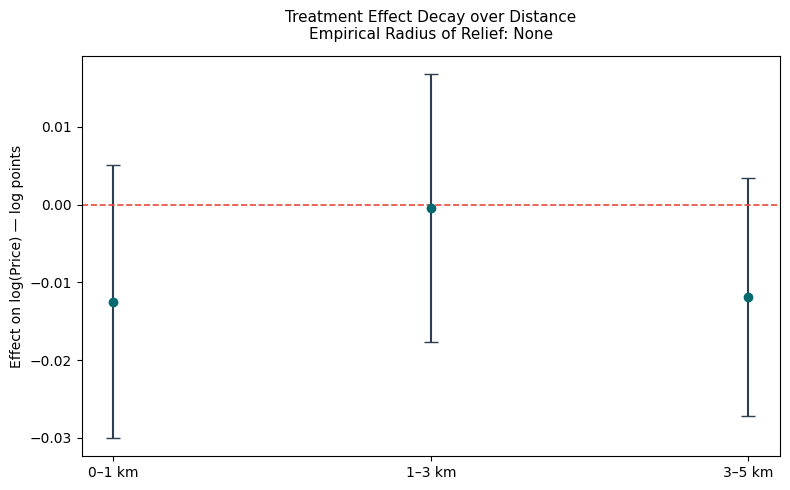

✅ Saved: /Users/amh/Desktop/CEU-EDP/THESIS/Data/figures/radius_of_relief_coefs_40.png


In [178]:
# ── 12. COEFFICIENT PLOT ──────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))

x_pos           = np.arange(len(res_df))
coefs           = res_df['coef'].values
errs            = 1.96 * res_df['se'].values
bin_labels_plot = ['0–1 km', '1–3 km', '3–5 km'][:len(res_df)]

ax.errorbar(x_pos, coefs, yerr=errs,
            fmt='o', color='#01696f', ecolor='#2c3e50',
            capsize=5, lw=1.5, markersize=6)
ax.axhline(0, color='#e74c3c', linestyle='--', linewidth=1.2)

ax.set_xticks(x_pos)
ax.set_xticklabels(bin_labels_plot)
ax.set_ylabel('Effect on log(Price) — log points', fontsize=10)
ax.set_title(
    f'Treatment Effect Decay over Distance\nEmpirical Radius of Relief: {radius}',
    fontsize=11, pad=12
)

def get_star(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

for i, (idx, row) in enumerate(res_df.iterrows()):
    star = get_star(row['pval'])
    if star:
        ax.annotate(star,
                    xy=(i, row['coef'] + 1.96 * row['se'] + 0.005),
                    ha='center', va='bottom', color='#c0392b', fontsize=10)

plt.tight_layout()
plt.savefig(f"{figures}/radius_of_relief_coefs_40.png", dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Saved: {figures}/radius_of_relief_coefs_40.png")

-----
## 3.A. 2. Event STUDY

In [179]:
# ── OPTION 2: EVENT-STUDY BIN-INTERACTION TWFE ───────────────────────────────
# Specification:
#   Y_ipt = alpha + sum_{k,s} gamma_{k,s} * (1[d_i in Bin_k] x 1[rel_time in S_s])
#           + EntityEffects + TimeEffects + e_ipt
# Reference: Pre-3 (tau <= -6) x all bins (omitted)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from linearmodels import PanelOLS

# ── 1. BUILD RELATIVE TIME ────────────────────────────────────────────────────
df_es = df_ror.copy()

df_es['rel_period'] = np.where(
    df_es['treated_5km'] == 1,
    ((df_es['period_14d'] - df_es['apertura_date']).dt.days / 14).round().astype('Int64'),
    pd.NA
)

# ── 2. ASSIGN RELATIVE TIME BINS ─────────────────────────────────────────────
def assign_rel_bin(r):
    if pd.isna(r):
        return 'control'
    r = int(r)
    if r <= -6:   return 'pre3_ref'   # omitted reference
    elif r <= -4: return 'pre2'
    elif r <= -2: return 'pre1'
    elif r == -1: return 'pre0'
    elif r <= 4:  return 'post1'
    else:         return 'post2'

df_es['rel_bin'] = df_es['rel_period'].apply(assign_rel_bin)

# ── 3. CREATE INTERACTION DUMMIES ─────────────────────────────────────────────
dist_bins = ['bin_0_1km', 'bin_1_3km', 'bin_3_5km']
time_bins = ['pre2', 'pre1', 'pre0', 'post1', 'post2']   # pre3_ref omitted

interaction_cols_es = []
for d in dist_bins:
    for t in time_bins:
        col = f"{d}_x_{t}"
        df_es[col] = (
            (df_es['dist_bin'] == d) & (df_es['rel_bin'] == t)
        ).astype(int)
        interaction_cols_es.append(col)

print(f"Interaction dummies: {len(interaction_cols_es)}")
print("Non-zero obs per dummy:")
print(df_es[interaction_cols_es].sum().to_string())

# ── 4. BUILD PANEL ────────────────────────────────────────────────────────────
df_es = df_es.dropna(subset=['log_price_mean', 'distance_km']).copy()
panel_es   = df_es.set_index(['entity_id', 'period_14d'])
cluster_es = panel_es['district_id']

# ── 5. ESTIMATE ───────────────────────────────────────────────────────────────
formula_es = f"log_price_mean ~ 1 + {' + '.join(interaction_cols_es)} + EntityEffects + TimeEffects"
mod_es = PanelOLS.from_formula(formula_es, data=panel_es)
res_es = mod_es.fit(cov_type='clustered', clusters=cluster_es)

print(res_es.summary)

# ── 6. EXTRACT RESULTS ────────────────────────────────────────────────────────
rows = []
for d in dist_bins:
    for t in time_bins:
        col = f"{d}_x_{t}"
        if col in res_es.params.index:
            rows.append({
                'dist_bin': d,
                'time_bin': t,
                'coef': res_es.params[col],
                'se':   res_es.std_errors[col],
                'pval': res_es.pvalues[col],
            })

es_df = pd.DataFrame(rows)

# Add omitted reference period manually as zero
ref_rows = [
    {'dist_bin': d, 'time_bin': 'pre3_ref', 'coef': 0.0, 'se': 0.0, 'pval': 1.0}
    for d in dist_bins
]
es_df = pd.concat([es_df, pd.DataFrame(ref_rows)], ignore_index=True)

time_order = ['pre3_ref', 'pre2', 'pre1', 'pre0', 'post1', 'post2']
es_df['time_order'] = es_df['time_bin'].map({t: i for i, t in enumerate(time_order)})
es_df = es_df.sort_values(['dist_bin', 'time_order'])

Interaction dummies: 15
Non-zero obs per dummy:
bin_0_1km_x_pre2      136
bin_0_1km_x_pre1      219
bin_0_1km_x_pre0      140
bin_0_1km_x_post1     656
bin_0_1km_x_post2    2221
bin_1_3km_x_pre2      168
bin_1_3km_x_pre1      193
bin_1_3km_x_pre0      126
bin_1_3km_x_post1     588
bin_1_3km_x_post2    2384
bin_3_5km_x_pre2       66
bin_3_5km_x_pre1       83
bin_3_5km_x_pre0       46
bin_3_5km_x_post1     206
bin_3_5km_x_post2     853
                          PanelOLS Estimation Summary                           
Dep. Variable:         log_price_mean   R-squared:                        0.0009
Estimator:                   PanelOLS   R-squared (Between):             -0.0023
No. Observations:               25459   R-squared (Within):               0.0038
Date:                Mon, Jun 08 2026   R-squared (Overall):              0.0004
Time:                        09:53:31   Log-likelihood                    5199.0
Cov. Estimator:             Clustered                                       

In [180]:
print(df_ror['period_14d'].min(), df_ror['period_14d'].max())
print("Pre-treatment obs:", (df_ror['post_t'] == 0).sum())

2022-05-23 00:00:00 2025-12-29 00:00:00
Pre-treatment obs: 18643


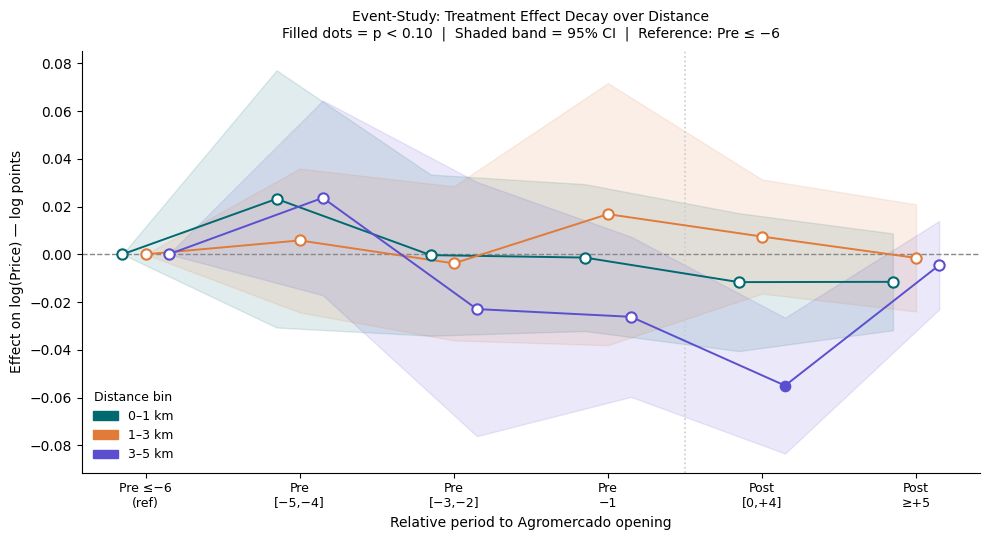

✅ Saved: /Users/amh/Desktop/CEU-EDP/THESIS/Data/figures/radius_of_relief_eventstudy.png


In [181]:
# ── 7. PLOT ───────────────────────────────────────────────────────────────────
colours = {
    'bin_0_1km': '#01696f',
    'bin_1_3km': '#e07b39',
    'bin_3_5km': '#5b4fcf'
}
labels = {
    'bin_0_1km': '0–1 km',
    'bin_1_3km': '1–3 km',
    'bin_3_5km': '3–5 km'
}
x_labels = ['Pre ≤−6\n(ref)', 'Pre\n[−5,−4]', 'Pre\n[−3,−2]', 'Pre\n−1', 'Post\n[0,+4]', 'Post\n≥+5']

fig, ax = plt.subplots(figsize=(10, 5.5))
offsets = {'bin_0_1km': -0.15, 'bin_1_3km': 0.0, 'bin_3_5km': 0.15}

for d in dist_bins:
    sub = es_df[es_df['dist_bin'] == d].sort_values('time_order')
    x = sub['time_order'].values + offsets[d]
    coefs = sub['coef'].values
    errs = 1.96 * sub['se'].values
    c = colours[d]

    ax.fill_between(x, coefs - errs, coefs + errs, alpha=0.12, color=c)
    ax.plot(x, coefs, color=c, linewidth=1.4, zorder=3)

    for xi, ci, pi in zip(x, coefs, sub['pval'].values):
        if pi < 0.10:
            ax.scatter(xi, ci, color=c, s=55, zorder=5, edgecolors=c)
        else:
            ax.scatter(xi, ci, color='white', s=55, zorder=5,
                       edgecolors=c, linewidths=1.5)

ax.axhline(0, color='#888888', linestyle='--', linewidth=1.0, zorder=1)
ax.axvline(3.5, color='#cccccc', linestyle=':', linewidth=1.2, zorder=1)

ax.set_xticks(range(len(time_order)))
ax.set_xticklabels(x_labels, fontsize=9)
ax.set_ylabel('Effect on log(Price) — log points', fontsize=10)
ax.set_xlabel('Relative period to Agromercado opening', fontsize=10)
ax.set_title(
    'Event-Study: Treatment Effect Decay over Distance\n'
    'Filled dots = p < 0.10  |  Shaded band = 95% CI  |  Reference: Pre ≤ −6',
    fontsize=10, pad=10
)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

legend_handles = [mpatches.Patch(color=colours[d], label=labels[d]) for d in dist_bins]
ax.legend(handles=legend_handles, title='Distance bin', fontsize=9,
          title_fontsize=9, frameon=False, loc='lower left')

plt.tight_layout()
plt.savefig(f"{figures}/radius_of_relief_eventstudy.png", dpi=300,
            bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Saved: {figures}/radius_of_relief_eventstudy.png")

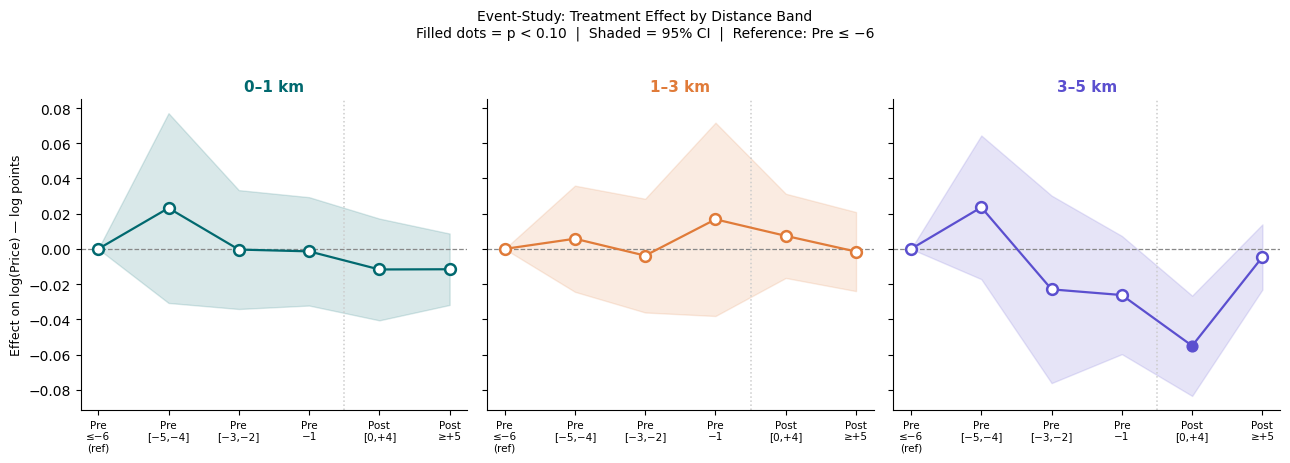

✅ Saved: /Users/amh/Desktop/CEU-EDP/THESIS/Data/figures/radius_of_relief_eventstudy_panels.png


In [182]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4.5), sharey=True)

colours = {'bin_0_1km': '#01696f', 'bin_1_3km': '#e07b39', 'bin_3_5km': '#5b4fcf'}
labels  = {'bin_0_1km': '0–1 km',  'bin_1_3km': '1–3 km',  'bin_3_5km': '3–5 km'}
x_labels = ['Pre\n≤−6\n(ref)', 'Pre\n[−5,−4]', 'Pre\n[−3,−2]', 'Pre\n−1',
            'Post\n[0,+4]', 'Post\n≥+5']

for ax, d in zip(axes, dist_bins):
    sub   = es_df[es_df['dist_bin'] == d].sort_values('time_order')
    x     = sub['time_order'].values
    coefs = sub['coef'].values
    errs  = 1.96 * sub['se'].values
    c     = colours[d]

    ax.fill_between(x, coefs - errs, coefs + errs, alpha=0.15, color=c)
    ax.plot(x, coefs, color=c, linewidth=1.6, zorder=3)

    for xi, ci, pi in zip(x, coefs, sub['pval'].values):
        if pi < 0.10:
            ax.scatter(xi, ci, color=c, s=60, zorder=5, edgecolors=c)
        else:
            ax.scatter(xi, ci, color='white', s=60, zorder=5,
                       edgecolors=c, linewidths=1.8)

    ax.axhline(0, color='#888888', linestyle='--', linewidth=0.9)
    ax.axvline(3.5, color='#cccccc', linestyle=':', linewidth=1.1)
    ax.set_title(labels[d], fontsize=11, color=c, fontweight='bold')
    ax.set_xticks(range(len(time_order)))
    ax.set_xticklabels(x_labels, fontsize=7.5)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axes[0].set_ylabel('Effect on log(Price) — log points', fontsize=9)
fig.suptitle(
    'Event-Study: Treatment Effect by Distance Band\n'
    'Filled dots = p < 0.10  |  Shaded = 95% CI  |  Reference: Pre ≤ −6',
    fontsize=10, y=1.02
)

plt.tight_layout()
plt.savefig(f"{figures}/radius_of_relief_eventstudy_panels.png",
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"✅ Saved: {figures}/radius_of_relief_eventstudy_panels.png")

--------

## 3.A- EX-ANTE D* Estimation (ANNEXES)

In [183]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 19: RADIUS OF RELIEF — SPATIAL DECAY REGRESSION
# Spec: Y_imt = β1·Agro_mt + β2·(Agro_mt × Distance_im) + μ_m + τ_t + ε
# Source: Research Proposal Eq. 3 (Hernández 2026)
# ══════════════════════════════════════════════════════════════════════════════

# ── Distance lookup: one row per district ────────────────────────────────────
dist_lookup = (
    df_treated[['Distrito', 'distance_km']]
    .drop_duplicates(subset='Distrito')
    .rename(columns={'distance_km': 'dist_km'})
)
print(f"Distance lookup: {len(dist_lookup)} districts | "
      f"range [{dist_lookup['dist_km'].min():.1f}, {dist_lookup['dist_km'].max():.1f}] km")

Distance lookup: 43 districts | range [0.1, 22.9] km


In [184]:
# ── Significance helper ────────────────────────────────────────────────────────
def _s(p):
    return '***' if p < 0.01 else '**' if p < 0.05 else '*' if p < 0.10 else ''

### Track 1

In [185]:
# ── TRACK 1: log price mean ───────────────────────────────────────────────────
df_sp1 = df_t1_did.merge(dist_lookup, on='Distrito', how='left')
df_sp1['post']           = (df_sp1['timeid'] >= df_sp1['G']).astype(int)
df_sp1['treated']        = (df_sp1['G'] > 0).astype(int)
df_sp1['agro_active']    = df_sp1['treated'] * df_sp1['post']          # Agro_mt
df_sp1['agro_x_dist']    = df_sp1['agro_active'] * df_sp1['dist_km']   # Agro_mt × Distance_im
df_sp1 = df_sp1.dropna(subset=['log_price_mean', 'dist_km'])

res_sp1 = smf.ols(
    'log_price_mean ~ agro_active + agro_x_dist'
    ' + C(unitid) + C(timeid)',
    data=df_sp1
).fit(cov_type='cluster', cov_kwds={'groups': df_sp1['Distrito']})

b1_sp1 = res_sp1.params['agro_active']
b2_sp1 = res_sp1.params['agro_x_dist']
p1_sp1 = res_sp1.pvalues['agro_active']
p2_sp1 = res_sp1.pvalues['agro_x_dist']

print(f"\nTRACK 1 — Radius of Relief (log price mean)")
print(f"  β1 Agro (distance=0):         {b1_sp1:.4f}{_s(p1_sp1)}  (p={p1_sp1:.4f})")
print(f"  β2 Agro × Distance:           {b2_sp1:.4f}{_s(p2_sp1)}  (p={p2_sp1:.4f})")
print(f"  N: {int(res_sp1.nobs):,} | R²: {res_sp1.rsquared:.4f}")

# Radius of relief: solve β1 + β2·d* = 0 → d* = -β1/β2
if b2_sp1 > 0:
    d_star_1 = -b1_sp1 / b2_sp1
    print(f"  Radius of Relief d*:          {d_star_1:.2f} km  (effect = 0 beyond this point)")
else:
    print("  ⚠️  β2 ≤ 0 — no spatial decay detected (effect uniform or intensifies with distance)")



TRACK 1 — Radius of Relief (log price mean)
  β1 Agro (distance=0):         -0.0101  (p=0.2592)
  β2 Agro × Distance:           0.0017  (p=0.5869)
  N: 27,825 | R²: 0.9453
  Radius of Relief d*:          5.90 km  (effect = 0 beyond this point)


### Track 2

In [186]:
# ── TRACK 2: basket CV ────────────────────────────────────────────────────────
df_sp2 = df_t2.merge(dist_lookup, on='Distrito', how='left')
df_sp2['post']        = (df_sp2['timeid'] >= df_sp2['G']).astype(int)
df_sp2['treated']     = (df_sp2['G'] > 0).astype(int)
df_sp2['agro_active'] = df_sp2['treated'] * df_sp2['post']
df_sp2['agro_x_dist'] = df_sp2['agro_active'] * df_sp2['dist_km']
df_sp2 = df_sp2.dropna(subset=['basket_cv', 'dist_km'])

res_sp2 = smf.ols(
    'basket_cv ~ agro_active + agro_x_dist'
    ' + C(unitid) + C(timeid)',
    data=df_sp2
).fit(cov_type='cluster', cov_kwds={'groups': df_sp2['Distrito']})

b1_sp2 = res_sp2.params['agro_active']
b2_sp2 = res_sp2.params['agro_x_dist']
p1_sp2 = res_sp2.pvalues['agro_active']
p2_sp2 = res_sp2.pvalues['agro_x_dist']

print(f"\nTRACK 2 — Radius of Relief (basket CV)")
print(f"  β1 Agro (distance=0):         {b1_sp2:.4f}{_s(p1_sp2)}  (p={p1_sp2:.4f})")
print(f"  β2 Agro × Distance:           {b2_sp2:.4f}{_s(p2_sp2)}  (p={p2_sp2:.4f})")
print(f"  N: {int(res_sp2.nobs):,} | R²: {res_sp2.rsquared:.4f}")

if b2_sp2 > 0:
    d_star_2 = -b1_sp2 / b2_sp2
    print(f"  Radius of Relief d*:          {d_star_2:.2f} km  (CV effect = 0 beyond this point)")
else:
    print("  ⚠️  β2 ≤ 0 — no spatial decay in CV detected")



TRACK 2 — Radius of Relief (basket CV)
  β1 Agro (distance=0):         -0.0033  (p=0.6389)
  β2 Agro × Distance:           0.0013  (p=0.5098)
  N: 2,611 | R²: 0.3671
  Radius of Relief d*:          2.54 km  (CV effect = 0 beyond this point)


In [187]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 19B: RADIUS OF RELIEF — DISTANCE BIN SPECIFICATION
# Rationale: continuous interaction underpowered given 5km assignment design.
# Bins test threshold decay directly (Hotelling 1929 boundary logic).
# ══════════════════════════════════════════════════════════════════════════════

# ── Define bins ───────────────────────────────────────────────────────────────
BINS   = [0, 2, 5, 10, np.inf]
LABELS = ['0-2km', '2-5km', '5-10km', '>10km']

for df_, col_, label_ in [
    (df_sp1, 'log_price_mean', 'Track 1 (log price mean)'),
    (df_sp2, 'basket_cv',      'Track 2 (basket CV)')
]:
    df_ = df_.copy()
    df_['dist_bin'] = pd.cut(df_['dist_km'], bins=BINS, labels=LABELS, right=True)

    # Interaction: agro_active × bin dummies (omit >10km as reference for treated)
    # Reference category: never-treated (G=0) + dist_bin omitted
    for b in LABELS[:-1]:   # 0-2, 2-5, 5-10; >10km is reference treated bin
        df_[f'agro_{b}'] = (df_['agro_active'] == 1) & (df_['dist_bin'] == b)
        df_[f'agro_{b}'] = df_[f'agro_{b}'].astype(int)
    df_['agro_gt10'] = ((df_['agro_active'] == 1) & (df_['dist_bin'] == '>10km')).astype(int)

    formula = (f'{col_} ~ agro_0-2km + `agro_2-5km` + `agro_5-10km` + agro_gt10'
               f' + C(unitid) + C(timeid)')

    # Use rename to avoid formula parsing issues with hyphens
    df_ = df_.rename(columns={
        'agro_0-2km':  'agro_d1',
        'agro_2-5km':  'agro_d2',
        'agro_5-10km': 'agro_d3',
    })

    res_bin = smf.ols(
        f'{col_} ~ agro_d1 + agro_d2 + agro_d3 + agro_gt10 + C(unitid) + C(timeid)',
        data=df_.dropna(subset=[col_, 'dist_km'])
    ).fit(cov_type='cluster', cov_kwds={'groups': df_['Distrito']})

    print(f"\n{label_} — Distance Bin ATTs (reference: control units, G=0)")
    print(f"  {'Bin':<10} {'ATT':>8}  {'SE':>8}  {'p':>7}  {'sig':>4}")
    print(f"  {'-'*44}")
    for vname, blabel in [('agro_d1','0–2 km'),('agro_d2','2–5 km'),
                           ('agro_d3','5–10 km'),('agro_gt10','>10 km')]:
        b  = res_bin.params[vname]
        se = res_bin.bse[vname]
        p  = res_bin.pvalues[vname]
        print(f"  {blabel:<10} {b:>8.4f}  {se:>8.4f}  {p:>7.4f}  {_s(p):>4}")
    print(f"  N: {int(res_bin.nobs):,} | R²: {res_bin.rsquared:.4f}")

    # Save
    rows = []
    for vname, blabel in [('agro_d1','0-2km'),('agro_d2','2-5km'),
                           ('agro_d3','5-10km'),('agro_gt10','>10km')]:
        rows.append({'bin': blabel, 'att': res_bin.params[vname],
                     'se': res_bin.bse[vname], 'pval': res_bin.pvalues[vname],
                     'track': label_})
    pd.DataFrame(rows).to_csv(
        figures + f"/spatial_bins_{col_}.csv", index=False)

print("\n✅ Distance bin results saved.")


Track 1 (log price mean) — Distance Bin ATTs (reference: control units, G=0)
  Bin             ATT        SE        p   sig
  --------------------------------------------
  0–2 km      -0.0107    0.0076   0.1584      
  2–5 km       0.0016    0.0109   0.8804      
  5–10 km      0.0000    0.0000      nan      
  >10 km       0.0000    0.0000      nan      
  N: 27,825 | R²: 0.9453

Track 2 (basket CV) — Distance Bin ATTs (reference: control units, G=0)
  Bin             ATT        SE        p   sig
  --------------------------------------------
  0–2 km      -0.0023    0.0069   0.7397      
  2–5 km       0.0015    0.0089   0.8646      
  5–10 km      0.0000    0.0000      nan      
  >10 km       0.0000    0.0000      nan      
  N: 2,611 | R²: 0.3672

✅ Distance bin results saved.


In [188]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 19C: WITHIN-TREATED SPATIAL GRADIENT (0-2 km vs 2-5 km)
# Identifies near vs. far heterogeneity within the treatment radius
# ══════════════════════════════════════════════════════════════════════════════

for df_, col_, label_ in [
    (df_sp1, 'log_price_mean', 'Track 1 (log price mean)'),
    (df_sp2, 'basket_cv',      'Track 2 (basket CV)')
]:
    df_ = df_.copy()
    # Restrict to treated units only (G > 0, post == 1)
    df_treated_post = df_[df_['agro_active'] == 1].copy()
    df_treated_post['near'] = (df_treated_post['dist_km'] <= 2).astype(int)  # near=1, far=0

    # Check cell sizes
    print(f"\n{label_} — treated post-period observations:")
    print(df_treated_post.groupby('near')['Distrito'].nunique()
          .rename({0: 'Far (2-5km)', 1: 'Near (0-2km)'}).to_string())

    res_near = smf.ols(
        f'{col_} ~ near + C(unitid) + C(timeid)',
        data=df_treated_post.dropna(subset=[col_])
    ).fit(cov_type='cluster', cov_kwds={'groups': df_treated_post['Distrito']})

    b   = res_near.params['near']
    se  = res_near.bse['near']
    p   = res_near.pvalues['near']
    print(f"  Near (≤2km) vs Far (2–5km) differential:  {b:.4f}{_s(p)}  SE={se:.4f}  p={p:.4f}")
    print(f"  Interpretation: near districts have {abs(b):.4f} {'lower' if b<0 else 'higher'} "
          f"{'log price' if 'price' in col_ else 'CV'} than far districts post-treatment")
    print(f"  N (treated post): {int(res_near.nobs):,}")
    


Track 1 (log price mean) — treated post-period observations:
near
Far (2-5km)      8
Near (0-2km)    24
  Near (≤2km) vs Far (2–5km) differential:  -26548161816.9116  SE=nan  p=nan
  Interpretation: near districts have 26548161816.9116 lower log price than far districts post-treatment
  N (treated post): 7,424

Track 2 (basket CV) — treated post-period observations:
near
Far (2-5km)      8
Near (0-2km)    24
  Near (≤2km) vs Far (2–5km) differential:  0.0070  SE=0.0045  p=0.1209
  Interpretation: near districts have 0.0070 higher CV than far districts post-treatment
  N (treated post): 674


In [189]:
# ══════════════════════════════════════════════════════════════════════════════
# STEP 19C (FIXED): WITHIN-TREATED SPATIAL GRADIENT (0-2 km vs 2-5 km)
# Fix: drop C(unitid) — near is time-invariant, perfectly collinear with unit FEs
# Spec: Y ~ near + C(timeid), restricted to treated post-period only
# ══════════════════════════════════════════════════════════════════════════════

for df_, col_, label_ in [
    (df_sp1, 'log_price_mean', 'Track 1 (log price mean)'),
    (df_sp2, 'basket_cv',      'Track 2 (basket CV)')
]:
    df_ = df_.copy()
    df_treated_post = df_[df_['agro_active'] == 1].dropna(subset=[col_, 'dist_km']).copy()
    df_treated_post['near'] = (df_treated_post['dist_km'] <= 2).astype(int)

    print(f"\n{label_} — treated post-period cell sizes:")
    print(df_treated_post.groupby('near')['Distrito'].nunique()
          .rename({0: 'Far (2–5km)', 1: 'Near (0–2km)'}).to_string())

    # Time FE only — near is cross-sectional, cannot include unit FEs
    res_near = smf.ols(
        f'{col_} ~ near + C(timeid)',
        data=df_treated_post
    ).fit(cov_type='cluster', cov_kwds={'groups': df_treated_post['Distrito']})

    b  = res_near.params['near']
    se = res_near.bse['near']
    p  = res_near.pvalues['near']
    print(f"  Near (≤2km) vs Far (2–5km):  {b:.4f}{_s(p)}  SE={se:.4f}  p={p:.4f}")
    print(f"  Direction: near districts have {abs(b):.4f} "
          f"{'lower' if b<0 else 'higher'} "
          f"{'log price' if 'price' in col_ else 'CV'} than far districts")
    print(f"  N: {int(res_near.nobs):,} | Districts: {df_treated_post['Distrito'].nunique()}")


Track 1 (log price mean) — treated post-period cell sizes:
near
Far (2–5km)      8
Near (0–2km)    24
  Near (≤2km) vs Far (2–5km):  0.0022  SE=0.0198  p=0.9117
  Direction: near districts have 0.0022 higher log price than far districts
  N: 7,424 | Districts: 32

Track 2 (basket CV) — treated post-period cell sizes:
near
Far (2–5km)      8
Near (0–2km)    24
  Near (≤2km) vs Far (2–5km):  -0.0034  SE=0.0216  p=0.8760
  Direction: near districts have 0.0034 lower CV than far districts
  N: 674 | Districts: 32


In [190]:
print(df_treated.columns.tolist())

['ID sondeo', 'Nombre sondeo', 'Categoría', 'Marca', 'Cantidad', 'Unidad', 'Precio', 'Departamento', 'Distrito', 'Fecha Sondeo', 'iso_week', 'week_start', 'yr', 'mo', 'canonical_product', 'market_key', 'distance_km', 'closest_agro', 'treated_5km', 'treated_10km', 'treated_15km', 'first_treated_week', 'apertura_date']


# ANNEXES

### Annex A. heatmaps for missing data across district markets

In [191]:
print("\n=== GENERATING BATCHED MISSINGNESS HEATMAPS ===")

 #── 1. PULL AND PIVOT THE DATA ───────────────────────────────────────────────
heatmap_df = con.execute("""
    SELECT 
        Distrito, 
        iso_week, 
        CASE WHEN COUNT(Precio) > 0 THEN 1 ELSE 0 END AS is_observed
    FROM defensoria_panel
    GROUP BY Distrito, iso_week
""").df()

# Pivot: Rows = Districts, Columns = Weeks
pivot_heatmap = heatmap_df.pivot(index='Distrito', columns='iso_week', values='is_observed').fillna(0)

 # Calculate total coverage to sort (Descending: Best coverage first)
pivot_heatmap['total_obs'] = pivot_heatmap.sum(axis=1)
pivot_heatmap = pivot_heatmap.sort_values('total_obs', ascending=False)
pivot_heatmap = pivot_heatmap.drop(columns=['total_obs'])

 #── 2. LOOP AND GENERATE BATCHES OF 25 ───────────────────────────────────────
BATCH_SIZE = 25
total_districts = len(pivot_heatmap)
num_batches = math.ceil(total_districts / BATCH_SIZE)

for i in range(num_batches):
    start_idx = i * BATCH_SIZE
    end_idx = min((i + 1) * BATCH_SIZE, total_districts)
    
    # Slice the dataframe for the current batch
    batch_data = pivot_heatmap.iloc[start_idx:end_idx]
    
    # Plotting
    plt.figure(figsize=(14, 8)) # Optimal dimensions for 25 rows on A4 paper
    sns.heatmap(
        batch_data, 
        cmap=['#e74c3c', '#2ecc71'], # Red for missing (0), Green for observed (1)
        cbar=False, 
        yticklabels=True, 
        xticklabels=5 # Show every 5th week to avoid X-axis text overlap
    )
    
    plt.title(f'Panel Missingness Matrix: Batch {i+1} of {num_batches}\n(Districts Rank {start_idx+1} to {end_idx} by Coverage)', fontsize=15, pad=15)
    plt.xlabel('ISO Week', fontsize=12)
    plt.ylabel('District', fontsize=12)
    
    plt.tight_layout()
    
    # Save dynamically
    filename = (figures + "/district_missingness_heatmap_batch_" + str(i+1) + ".png")
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.close() # CRITICAL: Close the figure to free up RAM before the next loop
    
    print(f"✅ Saved: district_missingness_heatmap_batch_{i+1}.png (Rows {start_idx+1}-{end_idx})")

print(f"\nSuccessfully generated {num_batches} heatmap panels.")


=== GENERATING BATCHED MISSINGNESS HEATMAPS ===
✅ Saved: district_missingness_heatmap_batch_1.png (Rows 1-25)
✅ Saved: district_missingness_heatmap_batch_2.png (Rows 26-50)
✅ Saved: district_missingness_heatmap_batch_3.png (Rows 51-75)
✅ Saved: district_missingness_heatmap_batch_4.png (Rows 76-100)
✅ Saved: district_missingness_heatmap_batch_5.png (Rows 101-125)
✅ Saved: district_missingness_heatmap_batch_6.png (Rows 126-150)
✅ Saved: district_missingness_heatmap_batch_7.png (Rows 151-175)
✅ Saved: district_missingness_heatmap_batch_8.png (Rows 176-189)

Successfully generated 8 heatmap panels.


## Annex B: Track 1 & 2 TWFE specification:

In [192]:
# At the end of the Step 13C block — add this:
table1_fe = pd.DataFrame({
    'Spec 1': [
        f"{res1.params['Agro_it']:.4f}{_sig(res1.pvalues['Agro_it'])}",  
        '',  
        '',  
        f"{int(res1.nobs):,}"
    ],
    'Spec 2': [
        f"{res2.params['Agro_it']:.4f}{_sig(res2.pvalues['Agro_it'])}",  
        f"{res2.params['Agro_x_Info']:.4f}{_sig(res2.pvalues['Agro_x_Info'])}", 
        '',  
        f"{int(res2.nobs):,}"
    ],
    'Spec 3 (obs gov-price only)': [
        f"{res3.params['Agro_it']:.4f}{_sig(res3.pvalues['Agro_it'])}",  
        '', # <--- Leave this blank! Agro_x_Info cannot exist in Spec 3.
        f"{res3.params['log_gov_price']:.4f}{_sig(res3.pvalues['log_gov_price'])}",  
        f"{int(res3.nobs):,}"
    ],
    'Spec 4 (+log_gov_price)': [
        f"{res4.params['Agro_it']:.4f}{_sig(res4.pvalues['Agro_it'])}",  
        f"{res4.params['Agro_x_Info']:.4f}{_sig(res4.pvalues['Agro_x_Info'])}", 
        f"{res4.params['log_gov_price']:.4f}{_sig(res4.pvalues['log_gov_price'])}",  
        f"{int(res4.nobs):,}"
    ],
}, index=['Agro_it', 'Agro_it × Info_t', 'log_gov_price', 'N'])

print("\nTABLE 1 — FE LADDER: LOG PRICE MEAN")
print(table1_fe.to_string())



table1_fe.to_csv(f"{TABLEDIR}/table1_fe_ladder.csv")
print(f"✅ Saved: {TABLEDIR}/table1_fe_ladder.csv")


TABLE 1 — FE LADDER: LOG PRICE MEAN
                   Spec 1   Spec 2 Spec 3 (obs gov-price only) Spec 4 (+log_gov_price)
Agro_it           -0.0063   0.0026                     -0.0108                  0.0034
Agro_it × Info_t           -0.0117                                             -0.0109
log_gov_price                                        0.4518***               0.2551***
N                  27,825   27,825                       8,122                  27,825
✅ Saved: /Users/amh/Desktop/CEU-EDP/THESIS/Data/defensoria/output/table1_fe_ladder.csv


In [193]:
def stars(p):
    if pd.isna(p):
        return ""
    return "***" if p < 0.01 else "**" if p < 0.05 else "*" if p < 0.10 else ""

def fmt_coef(b, p):
    return "" if pd.isna(b) else f"{b:.4f}{stars(p)}"

def fit_fe(df, y, xvars, entity_col="entity_id", time_col="period_14d", cluster_col="district_id"):
    tmp = df[[entity_col, time_col, cluster_col, y] + xvars].dropna().copy()
    tmp = tmp.set_index([entity_col, time_col])

    X = tmp[xvars].copy()
    keep = []
    for c in X.columns:
        trial = X[keep + [c]] if keep else X[[c]]
        if np.linalg.matrix_rank(trial.to_numpy()) == trial.shape[1]:
            keep.append(c)

    if len(keep) == 0:
        raise ValueError(f"No identified regressors left for {y}: {xvars}")

    mod = PanelOLS(tmp[y], tmp[keep], entity_effects=True, time_effects=True, drop_absorbed=True)
    return mod.fit(cov_type="clustered", clusters=tmp[cluster_col])


def table_from_res(res_list, n_list, ctrl_mean, out_path):
    rows = []
    specs = ["Agro", "Agro + Info", "Agro + Info + observed gov price", "Agro + Info + imputed gov price"]
    for spec, res, n in zip(specs, res_list, n_list):
        rows.append({
            "Spec": spec,
            "Agro": fmt_coef(res.params.get("Agro", np.nan), res.pvalues.get("Agro", np.nan)),
            "Agro × Info": fmt_coef(res.params.get("Agro_x_Info", np.nan), res.pvalues.get("Agro_x_Info", np.nan)),
            "log_gov_price": fmt_coef(res.params.get("log_gov_price", np.nan), res.pvalues.get("log_gov_price", np.nan)),
            "District FE": "✓",
            "Period FE": "✓",
            "Control mean": f"{ctrl_mean:.4f}",
            "Within R²": f"{getattr(res, 'rsquared_within', np.nan):.4f}",
            "N": f"{int(n):,}"
        })
    tab = pd.DataFrame(rows).set_index("Spec")
    tab.to_csv(out_path)
    return tab


In [194]:
# -------------------------
# Track 1: log price mean
# -------------------------
dft1_full = con.execute("SELECT * FROM panel_track1").df().copy()
dft1_full["period_14d"] = pd.to_datetime(dft1_full["period_14d"])
dft1_full["market_key"] = dft1_full["Distrito"].astype(str).str.lower().str.strip()
dft1_full["product_key"] = dft1_full["canonical_product"].astype(str).str.lower().str.strip()

if "treated_5km" not in dft1_full.columns:
    dft1_full = dft1_full.merge(
        treat_timing[["market_key", "treated_5km", "apertura_date"]],
        on="market_key",
        how="left"
    )

dft1_full["treated_5km"] = dft1_full["treated_5km"].fillna(0).astype(int)
dft1_full["apertura_date"] = pd.to_datetime(dft1_full["apertura_date"])

agro_spine1 = (
    agro_spine.loc[:, ["canonical_product", "period_14d", "log_gov_price", "gov_imputed_any"]]
    .copy()
)
agro_spine1["product_key"] = agro_spine1["canonical_product"].apply(norm)
agro_spine1["period_14d"] = pd.to_datetime(agro_spine1["period_14d"])
agro_spine1 = agro_spine1[["product_key", "period_14d", "log_gov_price", "gov_imputed_any"]].copy()

dft1_full = dft1_full.merge(agro_spine1, on=["product_key", "period_14d"], how="left")

dft1_full["Agro"] = ((dft1_full["treated_5km"] == 1) & (dft1_full["period_14d"] >= dft1_full["apertura_date"])).astype(int)
dft1_full["Info"] = (dft1_full["gov_imputed_any"] == 0).astype(int)
dft1_full["Agro_x_Info"] = dft1_full["Agro"] * dft1_full["Info"]
dft1_full["entity_id"] = dft1_full["Distrito"].astype(str) + " | " + dft1_full["canonical_product"].astype(str)
dft1_full["district_id"] = dft1_full["Distrito"].astype("category").cat.codes

dft1_reg = dft1_full.dropna(subset=["log_price_mean"]).copy()
dft1_obs = dft1_reg[dft1_reg["gov_imputed_any"] == 0].copy()

res1_t1 = fit_fe(dft1_reg, "log_price_mean", ["Agro"])
res2_t1 = fit_fe(dft1_reg, "log_price_mean", ["Agro", "Agro_x_Info"])
res3_t1 = fit_fe(dft1_obs, "log_price_mean", ["Agro"])
res4_t1 = fit_fe(dft1_reg, "log_price_mean", ["Agro", "Agro_x_Info", "log_gov_price"])

tab1 = table_from_res(
    [res1_t1, res2_t1, res3_t1, res4_t1],
    [len(dft1_reg), len(dft1_reg), len(dft1_obs), len(dft1_reg)],
    dft1_reg.loc[dft1_reg["treated_5km"] == 0, "log_price_mean"].mean(),
    os.path.join(TABLEDIR, "table1_feladder_log_price.csv")
)

print("TABLE 1")
print(tab1.to_string())

KeyError: "['log_gov_price', 'gov_imputed_any'] not in index"

In [ ]:
# -------------------------
# Track 2: basket CV
# -------------------------
dft2_full = con.execute("SELECT * FROM panel_track2").df().copy()
dft2_full["period_14d"] = pd.to_datetime(dft2_full["period_14d"])
dft2_full["market_key"] = dft2_full["Distrito"].astype(str).str.lower().str.strip()

if "treated_5km" not in dft2_full.columns:
    dft2_full = dft2_full.merge(
        treat_timing[["market_key", "treated_5km", "apertura_date"]],
        on="market_key",
        how="left"
    )

dft2_full["treated_5km"] = dft2_full["treated_5km"].fillna(0).astype(int)
dft2_full["apertura_date"] = pd.to_datetime(dft2_full["apertura_date"])

gov_period = agro_spine.groupby("period_14d", as_index=False).agg(
    log_gov_price=("log_gov_price", "mean"),
    gov_imputed_any=("gov_imputed_any", "max")
)
gov_period["period_14d"] = pd.to_datetime(gov_period["period_14d"])

dft2_full = dft2_full.merge(gov_period, on="period_14d", how="left")
dft2_full["Agro"] = ((dft2_full["treated_5km"] == 1) & (dft2_full["period_14d"] >= dft2_full["apertura_date"])).astype(int)
dft2_full["Info"] = (dft2_full["gov_imputed_any"] == 0).astype(int)
dft2_full["Agro_x_Info"] = dft2_full["Agro"] * dft2_full["Info"]
dft2_full["entity_id"] = dft2_full["Distrito"].astype(str)
dft2_full["district_id"] = dft2_full["Distrito"].astype("category").cat.codes

dft2_reg = dft2_full.dropna(subset=["basket_cv"]).copy()
dft2_obs = dft2_reg[dft2_reg["gov_imputed_any"] == 0].copy()

res1_t2 = fit_fe(dft2_reg, "basket_cv", ["Agro"])
res2_t2 = fit_fe(dft2_reg, "basket_cv", ["Agro", "Agro_x_Info"])
res3_t2 = fit_fe(dft2_obs, "basket_cv", ["Agro"])
res4_t2 = fit_fe(dft2_reg, "basket_cv", ["Agro", "Agro_x_Info", "log_gov_price"])


tab2 = table_from_res(
    [res1_t2, res2_t2, res3_t2, res4_t2],
    [len(dft2_reg), len(dft2_reg), len(dft2_obs), len(dft2_reg)],
    dft2_reg.loc[dft2_reg["treated_5km"] == 0, "basket_cv"].mean(),
    os.path.join(TABLEDIR, "table2_feladder_basket_cv.csv")
)

print("TABLE 2")
print(tab2.to_string())

## Study Plots

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

BASE = "/path/to/your/outputs/"   # ← update

es1 = pd.read_csv(defens+ "/es_track1_log_price_notyettreated_40.csv")
es2 = pd.read_csv(defens + "/es_track2_basket_cv_notyettreated_40.csv")

def plot_event_study(df, title, ylabel, outpath):
    df = df[(df["event_time"] >= -20) & (df["event_time"] <= 20)].copy()
    pre  = df[df["event_time"] < 0]
    post = df[df["event_time"] >= 0]

    fig, ax = plt.subplots(figsize=(10, 4.5))

    ax.errorbar(pre["event_time"], pre["att"], yerr=1.96*pre["se"],
                fmt="o", color="#7f8c8d", ecolor="#bdc3c7",
                elinewidth=1.0, capsize=2.5, markersize=4,
                linewidth=0, label="Pre-treatment ATT(g,t)")
    ax.errorbar(post["event_time"], post["att"], yerr=1.96*post["se"],
                fmt="o", color="#2c3e50", ecolor="#7f8c8d",
                elinewidth=1.0, capsize=2.5, markersize=5,
                linewidth=0, label="Post-treatment ATT(g,t)")
    ax.plot(post["event_time"], post["att"],
            color="#2c3e50", linewidth=0.8, alpha=0.4)

    ax.axvline(x=-0.5, color="#e74c3c", linewidth=1.4,
               linestyle="--", label="Treatment onset (t = 0)")
    ax.axhline(y=0, color="black", linewidth=0.7, alpha=0.35)
    ax.axvspan(-20.5, -0.5, alpha=0.04, color="steelblue")

    sig_post = post[post["pval"] < 0.05]
    if len(sig_post):
        ax.scatter(sig_post["event_time"], sig_post["att"],
                   color="#e74c3c", s=40, zorder=5,
                   label="Significant post (p<0.05)")

    mean_post = post[post["event_time"].between(0,20)]["att"].mean()
    ax.annotate(f"Mean post-ATT = {mean_post:.4f}",
                xy=(0.98, 0.05), xycoords="axes fraction",
                ha="right", va="bottom", fontsize=8,
                bbox=dict(boxstyle="round,pad=0.3", fc="white",
                          ec="#bdc3c7", alpha=0.8))

    ax.set_xlabel("Event time (bi-weekly periods relative to opening)", fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=11, fontweight="bold", pad=8)
    ax.xaxis.set_major_locator(mticker.MultipleLocator(2))
    ax.tick_params(labelsize=9)
    ax.legend(fontsize=8, framealpha=0.7, loc="upper left")
    fig.tight_layout()
    fig.savefig(outpath, dpi=300, bbox_inches="tight")
    plt.close(fig)
    print(f"Saved: {outpath}")

plot_event_study(es1,
    "Track 1: Effect of Agromercado on Log Price Mean",
    "ATT — Log Price Mean",
    figures +"/fig_event_study_track1.pdf")

plot_event_study(es2,
    "Track 2: Effect of Agromercado on Basket Price CV",
    "ATT — Basket Coefficient of Variation",
    figures +"/fig_event_study_track2.pdf")

In [ ]:


params = {
    "Track 1: Log Price (5 km)": {
        "b1": -0.1015, "b2": 0.0172,
        "se_b1": 0.0542, "se_b2": 0.0109,
        "color": "#2c3e50"},
    "Track 2: Basket CV (5 km)": {
        "b1": -0.0203, "b2": 0.0080,
        "se_b1": 0.0110, "se_b2": 0.0050,
        "color": "#c0392b"},
}

d = np.linspace(0, 10, 500)
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

for ax, (label, p) in zip(axes, params.items()):
    b1, b2, se_b1, se_b2 = p["b1"], p["b2"], p["se_b1"], p["se_b2"]
    c = p["color"]
    att_d = b1 + b2 * d
    se_d  = np.sqrt(se_b1**2 + (d**2) * se_b2**2)
    d_star = -b1 / b2

    ax.fill_between(d, att_d - 1.96*se_d, att_d + 1.96*se_d,
                    alpha=0.15, color=c, label="95% CI (delta method)")
    ax.plot(d, att_d, color=c, linewidth=2.0, label="Predicted ATT($d$)")
    ax.axhline(0, color="black", linewidth=0.7, alpha=0.4)
    ax.axvline(d_star, color=c, linewidth=1.4, linestyle="--",
               label=f"$d^* = {d_star:.2f}$ km")
    ax.axvspan(0, d_star, alpha=0.06, color=c)
    ax.annotate(f"$d^* = {d_star:.2f}$ km",
                xy=(d_star, 0),
                xytext=(min(d_star + 1.2, 9.0), b1 * 0.35),
                arrowprops=dict(arrowstyle="->", color=c, lw=1.0),
                fontsize=8, color=c)
    ax.set_xlabel("Road distance from Agromercado (km)", fontsize=10)
    ax.set_ylabel("Predicted ATT", fontsize=10)
    ax.set_title(label, fontsize=10, fontweight="bold", pad=6)
    ax.set_xlim(0, 10)
    ax.legend(fontsize=8, framealpha=0.75)
    ax.tick_params(labelsize=9)

fig.suptitle("Radius of Relief: Predicted ATT($d$) by Distance",
             fontsize=11, fontweight="bold", y=1.01)
fig.tight_layout()
fig.savefig(f"{figures}/fig_radius_of_relief.png", dpi=300, bbox_inches="tight")
plt.close(fig)
print("Saved: fig_radius_of_relief.png")


# 4. LATEX

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# §3 DATA SECTION — FILL-IN NUMBERS
# Variable names matched to my_thesis_notebook_40.ipynb
# ══════════════════════════════════════════════════════════════════════════════

print("=" * 60)
print("§3.1 RAW DATA COVERAGE")
print("=" * 60)
# Raw data is in DuckDB table 'defensoria_raw', not a pandas df
qa_raw = con.execute("""
    SELECT COUNT(*) AS n_rows,
           COUNT(DISTINCT Distrito) AS n_districts,
           COUNT(DISTINCT Departamento) AS n_departments,
           MIN("Fecha Sondeo") AS date_min,
           MAX("Fecha Sondeo") AS date_max
    FROM defensoria_raw
""").df()
print(qa_raw.to_string(index=False))

print("\n§3.1 ANALYTICAL PANEL WINDOW")
qa_panel = con.execute("""
    SELECT COUNT(*) AS n_rows,
           COUNT(DISTINCT Distrito) AS n_districts,
           COUNT(DISTINCT Departamento) AS n_departments,
           MIN("Fecha Sondeo") AS date_min,
           MAX("Fecha Sondeo") AS date_max,
           COUNT(DISTINCT iso_week) AS n_weeks
    FROM defensoria_panel
""").df()
print(qa_panel.to_string(index=False))

print("\n" + "=" * 60)
print("§3.2 CANONICAL BASKET")
print("=" * 60)
print(f"N products in basket:  {len(MYBASKET)}")
print(f"Products:              {sorted(MYBASKET)}")

print("\n" + "=" * 60)
print("§3.3 AGROMERCADO TREATMENT DATA")
print("=" * 60)
agro_n = con.execute("SELECT COUNT(DISTINCT market_key) FROM agro_spine_full").df().iloc[0,0] \
         if 'agro_spine_full' in [t[0] for t in con.execute("SHOW TABLES").fetchall()] \
         else agro_raw['market_key'].nunique() if 'market_key' in agro_raw.columns \
         else agro_raw.shape[0]
print(f"Agromercado locations: {agro_n}")
print(f"Phase 1 (Agro+Info):   6 Jul 2024 – 28 Nov 2024")
print(f"Phase 2 (Agro only):   29 Nov 2024 – end of sample")
print(f"Multi-agro municipalities: Santa Tecla, San Miguel, Santa Ana")

print("\n" + "=" * 60)
print("§3.4 TREATMENT ASSIGNMENT (5 km, OSRM)")
print("=" * 60)
total_d    = df_treated['Distrito'].nunique()
treated_d  = df_treated[df_treated['treated_5km'] == 1]['Distrito'].nunique()
control_d  = df_treated[df_treated['treated_5km'] == 0]['Distrito'].nunique()
d_min      = df_treated['distance_km'].min()
d_max      = df_treated['distance_km'].max()
d_mean_tr  = df_treated[df_treated['treated_5km'] == 1]['distance_km'].mean()
print(f"Total districts:       {total_d}")
print(f"Treated (≤5 km):       {treated_d}")
print(f"Control  (>5 km):      {control_d}")
print(f"Distance range:        {d_min:.2f} – {d_max:.2f} km")
print(f"Mean dist (treated):   {d_mean_tr:.2f} km")

print("\n" + "=" * 60)
print("§3.5 COVERAGE FILTER (40% threshold)")
print("=" * 60)
cov_stats = con.execute("""
    WITH totals AS (
        SELECT COUNT(DISTINCT period_14d) AS max_periods FROM defensoria_biweekly
    )
    SELECT
        COUNT(DISTINCT d.Distrito) AS districts_surviving,
        ROUND(COUNT(DISTINCT d.Distrito) * 100.0 /
              (SELECT COUNT(DISTINCT Distrito) FROM defensoria_biweekly), 1) AS pct_surviving
    FROM defensoria_biweekly d
    CROSS JOIN totals t
    GROUP BY t.max_periods
    HAVING COUNT(DISTINCT d.period_14d) * 100.0 / t.max_periods >= 40.0
""").df()
print(cov_stats.to_string(index=False))

print("\n" + "=" * 60)
print("§3.5 TRACK 1 PANEL DIMENSIONS")
print("=" * 60)
t1 = con.execute("SELECT * FROM panel_track1").df()
print(f"Total obs:             {len(t1):,}")
print(f"Districts:             {t1['Distrito'].nunique()}")
print(f"Products:              {t1['canonical_product'].nunique()}")
print(f"Bi-weekly periods:     {t1['period_14d'].nunique()}")
print(f"Date range:            {t1['period_14d'].min()} → {t1['period_14d'].max()}")
print(f"Mean log price:        {t1['log_price_mean'].mean():.4f}")
print(f"Mean obs per cell:     {t1['n_obs'].mean():.2f}")

print("\n" + "=" * 60)
print("§3.5 TRACK 2 PANEL DIMENSIONS")
print("=" * 60)
t2 = con.execute("SELECT * FROM panel_track2").df()
print(f"Total obs:             {len(t2):,}")
print(f"Districts:             {t2['Distrito'].nunique()}")
print(f"Bi-weekly periods:     {t2['period_14d'].nunique()}")
print(f"Date range:            {t2['period_14d'].min()} → {t2['period_14d'].max()}")
print(f"Mean basket CV:        {t2['basket_cv'].mean():.4f}")
print(f"Mean products/cell:    {t2['nproducts_validcv'].mean():.2f}")

print("\n" + "=" * 60)
print("§3.5 DiD INPUT — COHORT STRUCTURE")
print("=" * 60)
print(f"Treatment cohorts G>0: {sorted(df_t1_did[df_t1_did['G']>0]['G'].unique())}")
print(f"N cohorts:             {df_t1_did[df_t1_did['G']>0]['G'].nunique()}")
print(f"Treated districts:     {df_t1_did[df_t1_did['G']>0]['Distrito'].nunique()}")
print(f"Control districts:     {df_t1_did[df_t1_did['G']==0]['Distrito'].nunique()}")
print(f"First bi-weekly period:{df_t1_did['period_14d'].min().date()}")
print(f"Last bi-weekly period: {df_t1_did['period_14d'].max().date()}")
print(f"Total periods:         {df_t1_did['timeid'].nunique()}")
min_g = df_t1_did[df_t1_did['G']>0]['G'].min()
n_pre = (df_t1_did['timeid'] < min_g).sum()
print(f"Pre-treatment obs:     {n_pre:,} (timeid < earliest G={min_g})")

print("\n" + "=" * 60)
print("§3.3 AGRO SPINE COVERAGE")
print("=" * 60)
agro_cov = con.execute("""
    SELECT COUNT(DISTINCT canonical_product) AS products_covered,
           COUNT(DISTINCT period_14d)        AS periods_covered,
           MIN(period_14d)                   AS first_period,
           MAX(period_14d)                   AS last_period,
           SUM(gov_imputed_any)              AS n_imputed_periods,
           ROUND(AVG(gov_imputed_any)*100,1) AS pct_imputed
    FROM agro_spine
""").df()
print(agro_cov.to_string(index=False))

# Summary statistics

In [ ]:
from pathlib import Path

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# CHAPTER 2 TABLES — LaTeX output, no jinja2 required
# TABLE 1 — Panel structure & coverage       → tab:panel_structure
# TABLE 4 — Staggered cohort structure       → tab:cohorts
# TABLE 2 — Outcome variable descriptives    → tab:desc_outcomes
# TABLE 3 — Product-level descriptives       → tab:desc_products
# ══════════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np

# ── Manual LaTeX builder (no jinja2) ─────────────────────────────────────────
def to_latex(df, caption, label, col_align=None):
    cols = list(df.columns)
    if col_align is None:
        col_align = "l" + "r" * (len(cols) - 1)
    header = " & ".join(f"\\textbf{{{c}}}" for c in cols) + " \\\\"
    lines = [
        "\\begin{table}[htbp]",
        "\\centering",
        "\\small",
        f"\\caption{{{caption}}}",
        f"\\label{{{label}}}",
        f"\\begin{{tabular}}{{{col_align}}}",
        "\\toprule",
        header,
        "\\midrule",
    ]
    for _, row in df.iterrows():
        lines.append(" & ".join(str(v) for v in row.values) + " \\\\")
    lines += ["\\bottomrule", "\\end{tabular}", "\\end{table}"]
    return "\n".join(lines)

# ── Load panel ────────────────────────────────────────────────────────────────
panel = con.execute("SELECT * FROM panel_outcomes").df()
panel["period_14d"] = pd.to_datetime(panel["period_14d"])

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 1 — PANEL STRUCTURE & COVERAGE
# ══════════════════════════════════════════════════════════════════════════════

n_obs       = len(panel)
n_districts = panel["Distrito"].nunique()
n_treat     = panel[panel["treated_5km"] == 1]["Distrito"].nunique()
n_control   = panel[panel["treated_5km"] == 0]["Distrito"].nunique()
n_products  = panel["canonical_product"].nunique()
n_periods   = panel["period_14d"].nunique()
date_min    = panel["period_14d"].min().strftime("%d %b %Y")
date_max    = panel["period_14d"].max().strftime("%d %b %Y")

table1 = pd.DataFrame({
    "Dimension": [
        "Total cell observations (district $\\times$ product $\\times$ period)",
        "District markets",
        "\\quad Treated ($\\leq$5 km from agromercado)",
        "\\quad Never-treated ($>$5 km)",
        "Canonical products in basket",
        "Bi-weekly periods",
        "Panel start",
        "Panel end",
        "Coverage threshold (bi-weekly periods observed)",
        "Period length (days)",
    ],
    "Value": [
        f"{n_obs:,}",
        str(n_districts),
        str(n_treat),
        str(n_control),
        str(n_products),
        str(n_periods),
        date_min,
        date_max,
        "$\\geq$40\\%",
        "14",
    ]
})

print("══ TABLE 1 — PANEL STRUCTURE ══\n")
print(table1.to_string(index=False))
print("\n\n── LaTeX ──")
print(to_latex(
    table1,
    caption = ("Panel structure and coverage. "
               "The unit of observation is a district--product--biweekly period cell. "
               "Treatment status is defined under the 5 km radius specification. "
               "Districts are retained if at least 40\\% of bi-weekly periods are observed."),
    label   = "tab:panel_structure",
    col_align = "lr"
))

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 4 — STAGGERED COHORT STRUCTURE
# ══════════════════════════════════════════════════════════════════════════════

treat = pd.read_csv(geo + "/treatment_assignment_43.csv")
treat["apertura_date"] = pd.to_datetime(treat["apertura_date"])

cohorts = (
    treat[treat["treated_5km"] == 1]
    .groupby("apertura_date")
    .agg(
        N_districts  = ("market_district", "count"),
        Agromercado  = ("closest_agro",    lambda x: x.value_counts().index[0]),
        Mean_dist_km = ("distance_km",     "mean"),
    )
    .round({"Mean_dist_km": 2})
    .reset_index()
    .rename(columns={"apertura_date": "Cohort (first treated period)"})
    .sort_values("Cohort (first treated period)")
)
cohorts["Cohort (first treated period)"] = (
    cohorts["Cohort (first treated period)"].dt.strftime("%d %b %Y")
)

# Add never-treated row
never = pd.DataFrame([{
    "Cohort (first treated period)": "Never-treated ($G = 0$)",
    "N_districts":                   n_control,
    "Agromercado":                   "---",
    "Mean_dist_km":                  round(treat[treat["treated_5km"] == 0]["distance_km"].mean(), 2),
}])
cohorts = pd.concat([cohorts, never], ignore_index=True)
cohorts.columns = ["Cohort", "$N$ districts", "Nearest agromercado", "Mean dist.\\ (km)"]

print("\n\n══ TABLE 4 — COHORT STRUCTURE ══\n")
print(cohorts.to_string(index=False))
print("\n\n── LaTeX ──")
print(to_latex(
    cohorts,
    caption = ("Staggered treatment cohort structure under the 5 km radius specification. "
               "Each cohort $g$ is defined by the calendar date on which the nearest agromercado "
               "first became operational. Districts in the never-treated group ($G = 0$) have no "
               "agromercado within 5 km during the full sample window and serve as the "
               "comparison group in the Callaway \\& Sant\\`Anna (2021) estimator. "
               "Mean distance is the OSRM road-network distance to the nearest agromercado."),
    label   = "tab:cohorts",
    col_align = "lrrr"
))

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 2 — OUTCOME VARIABLE DESCRIPTIVE STATISTICS
# ══════════════════════════════════════════════════════════════════════════════

def desc_block(df, var, label):
    rows = []
    for grp, sample_lbl in [(None, "Full sample"),
                             (1,    "Treated ($\\leq$5 km)"),
                             (0,    "Never-treated")]:
        sub = df if grp is None else df[df["treated_5km"] == grp]
        s   = sub.dropna(subset=[var])[var]
        rows.append({
            "Variable":  label if grp is None else "",
            "Sample":    sample_lbl,
            "$N$":       f"{len(s):,}",
            "Mean":      f"{s.mean():.4f}",
            "Std dev":   f"{s.std():.4f}",
            "p10":       f"{s.quantile(0.10):.4f}",
            "Median":    f"{s.median():.4f}",
            "p90":       f"{s.quantile(0.90):.4f}",
        })
    return rows

rows = []
rows += desc_block(panel,                          "price_mean",     "Price (USD/unit)")
rows += desc_block(panel,                          "log_price_mean", "Log price")
rows += desc_block(panel.dropna(subset=["price_cv"]), "price_cv",    "Price CV")

table2 = pd.DataFrame(rows)

print("\n\n══ TABLE 2 — OUTCOME VARIABLE DESCRIPTIVES ══\n")
print(table2.to_string(index=False))
print("\n\n── LaTeX ──")
print(to_latex(
    table2,
    caption = ("Descriptive statistics for outcome variables, stratified by treatment status "
               "under the 5 km radius specification. "
               "\\textit{Price} is the per-unit price (USD) normalised by quantity purchased. "
               "\\textit{Price CV} is the coefficient of variation of the canonical basket "
               "computed within each district--product--period cell; it serves as the "
               "main proxy for price dispersion in the Track~2 specification. "
               "Statistics are computed over the full panel window "
               "(January 2023 -- December 2025)."),
    label   = "tab:desc_outcomes",
    col_align = "llrrrrrr"
))

# ══════════════════════════════════════════════════════════════════════════════
# TABLE 3 — PRODUCT-LEVEL DESCRIPTIVE STATISTICS
# ══════════════════════════════════════════════════════════════════════════════

table3 = (
    panel.dropna(subset=["price_mean", "price_cv"])
    .groupby("canonical_product")
    .agg(
        N          = ("price_mean", "count"),
        Mean_price = ("price_mean", "mean"),
        SD_price   = ("price_mean", "std"),
        Mean_CV    = ("price_cv",   "mean"),
        SD_CV      = ("price_cv",   "std"),
        p10        = ("price_mean", lambda x: x.quantile(0.10)),
        p90        = ("price_mean", lambda x: x.quantile(0.90)),
    )
    .round(4)
    .reset_index()
    .sort_values("Mean_price", ascending=False)
    .rename(columns={
        "canonical_product": "Product",
        "Mean_price":        "Mean price",
        "SD_price":          "SD price",
        "Mean_CV":           "Mean CV",
        "SD_CV":             "SD CV",
        "p10":               "p10 price",
        "p90":               "p90 price",
    })
)

print("\n\n══ TABLE 3 — PRODUCT-LEVEL DESCRIPTIVES ══\n")
print(table3.to_string(index=False))
print("\n\n── LaTeX ──")
print(to_latex(
    table3,
    caption = ("Product-level descriptive statistics. "
               "Prices are per-unit (USD), normalised by quantity purchased. "
               "\\textit{Mean CV} is the average within-district coefficient of variation "
               "across all bi-weekly periods. "
               "Products are sorted by mean price in descending order."),
    label   = "tab:desc_products",
    col_align = "lrrrrrrr"
))

print("\n\n✅ All four tables generated.")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# FIGURE: Raw Parallel Trends — 3-row × 2-column grid
# Rows = distance cohorts (5km / 10km / never-treated)
# Cols = outcome (Log Price Mean | Basket CV)
# J&M Figure 2 analogue: connected line + filled squares, per-cohort dashed line
# Inputs: panel_outcomes (via DuckDB con), treat_timing
# ══════════════════════════════════════════════════════════════════════════════
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({
    'font.family':        'serif',
    'axes.spines.top':    False,
    'axes.spines.right':  False,
    'axes.linewidth':     0.8,
})

DARK_RED = '#8B1818'

# ── Pull aggregated series by cohort × period ─────────────────────────────────
df_raw = con.execute("""
    SELECT
        period_14d,
        treated_5km,
        treated_10km,
        treated_15km,
        AVG(log_price_mean) AS mean_log_price,
        AVG(price_cv)       AS mean_cv,
        COUNT(*)            AS n_obs
    FROM panel_outcomes
    WHERE log_price_mean IS NOT NULL
      AND price_cv IS NOT NULL
    GROUP BY period_14d, treated_5km, treated_10km, treated_15km
    ORDER BY period_14d
""").df()
df_raw['period_14d'] = pd.to_datetime(df_raw['period_14d'])

# ── Treatment onset dates per cohort (from your treat_timing df) ──────────────
TREAT_5KM  = pd.Timestamp('2024-07-05')   # first agromercado opening
# never-treated = no line

cohorts = {
    'Treated ≤ 5 km':        df_raw[df_raw['treated_5km']  == 1],
    'Never-treated':          df_raw[(df_raw['treated_5km']  == 0) & (df_raw['treated_10km'] == 0)],
}
treat_dates = {
    'Treated ≤ 5 km':         TREAT_5KM,
    'Never-treated':           None,
}
outcomes = {
    'mean_log_price': 'Log Vegetable Price Mean',
    'mean_cv':        'Basket Coefficient of Variation (CV)',
}

NROWS = len(cohorts)
NCOLS = len(outcomes)

fig, axes = plt.subplots(NROWS, NCOLS, figsize=(13, 9),
                         sharex=False, sharey=False)
fig.subplots_adjust(hspace=0.45, wspace=0.3)

for row_i, (cohort_label, df_cohort) in enumerate(cohorts.items()):
    for col_i, (outcome_col, outcome_label) in enumerate(outcomes.items()):
        ax = axes[row_i, col_i]

        # Aggregate to single series per period (in case multiple treatment cols)
        ser = df_cohort.groupby('period_14d')[outcome_col].mean().reset_index()
        ser = ser.sort_values('period_14d')

        # Connected line + filled squares (J&M style)
        ax.plot(ser['period_14d'], ser[outcome_col],
                color=DARK_RED, lw=1.4, marker='s',
                markersize=3.5, markerfacecolor=DARK_RED, zorder=3)

        # Treatment onset dashed vertical line
        t_date = treat_dates[cohort_label]
        if t_date is not None:
            ax.axvline(t_date, color='#2c3e50', lw=1.2,
                       linestyle='--', zorder=2)
            # Label inside panel (J&M style bottom annotation)
            ymin, ymax = ax.get_ylim()
            ax.text(t_date, ax.get_ylim()[0],
                    ' Agromercado\n opens',
                    fontsize=6.5, va='bottom', ha='left',
                    color='#2c3e50', style='italic')

        # Cohort label inside panel — bottom right (J&M style)
        ax.text(0.98, 0.04, cohort_label,
                transform=ax.transAxes, ha='right', va='bottom',
                fontsize=8, style='italic', family='serif')

        # Axis formatting
        ax.set_ylabel(outcome_label, fontsize=8, family='serif')
        ax.xaxis.set_major_locator(
            plt.matplotlib.dates.MonthLocator(interval=6))
        ax.xaxis.set_major_formatter(
            plt.matplotlib.dates.DateFormatter('%Y-%m'))
        plt.setp(ax.xaxis.get_majorticklabels(),
                 rotation=45, ha='right', fontsize=7)
        ax.tick_params(axis='y', labelsize=7)
        ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.3f'))

# Column headers (outcome labels at top)
for col_i, outcome_label in enumerate(outcomes.values()):
    axes[0, col_i].set_title(f'Panel {"AB"[col_i]}. {outcome_label}',
                              fontsize=9, family='serif', pad=6)

fig.suptitle(
    'Figure 2. Agromercados and Market Outcomes by Treatment Cohort\n'
    'Mean bi-weekly series; dashed line = first agromercado opening',
    fontsize=10, family='serif', y=1.01
)

plt.tight_layout()
plt.savefig(f"{figures}/fig2_treated_vs_control_jm.png",
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print("✅ Saved: fig2_treated_vs_control_jm.png")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TABLE A: Baseline Descriptive Statistics — Treated vs. Control
# J&M Table 1 analogue
# Input: panel_outcomes (DuckDB), treat_timing
# Output: figures/tableA_descriptives_jm.tex + .csv
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from scipy import stats

# ── Pull pre-treatment observations only ─────────────────────────────────────
df_baseline = con.execute("""
    SELECT
        Distrito,
        canonical_product,
        period_14d,
        treated_5km,
        price_mean,
        price_cv,
        log_price_mean,
        n_obs,
        distance_km
    FROM panel_outcomes
    WHERE period_14d < DATE '2024-07-05'   -- pre-treatment only
      AND price_mean IS NOT NULL
""").df()

def desc(s):
    return {
        'Mean':   s.mean(),
        'Std':    s.std(),
        'Min':    s.min(),
        'Max':    s.max(),
        'N':      s.notna().sum(),
    }

variables = {
    'Price mean (USD)':        'price_mean',
    'Log price mean':          'log_price_mean',
    'Price CV':                'price_cv',
    'Distance to agromercado (km)': 'distance_km',
    'Observations per period': 'n_obs',
}

rows = []
for var_label, col in variables.items():
    treated = df_baseline[df_baseline['treated_5km'] == 1][col].dropna()
    control = df_baseline[df_baseline['treated_5km'] == 0][col].dropna()
    # t-test for difference
    tstat, pval = stats.ttest_ind(treated, control, equal_var=False)
    sig = '***' if pval < 0.01 else '**' if pval < 0.05 else '*' if pval < 0.10 else ''

    rows.append({
        'Variable':           var_label,
        'Treated Mean':       f"{treated.mean():.3f}",
        'Treated Std':        f"({treated.std():.3f})",
        'Control Mean':       f"{control.mean():.3f}",
        'Control Std':        f"({control.std():.3f})",
        'Diff. (T−C)':        f"{treated.mean() - control.mean():.3f}{sig}",
        'p-value':            f"{pval:.3f}",
    })

df_desc = pd.DataFrame(rows)
df_desc.to_csv(f"{figures}/tableA_descriptives_jm.csv", index=False)
print(df_desc.to_string(index=False))
print("✅ Saved: tableA_descriptives_jm.csv")

# ── LaTeX ────────────────────────────────────────────────────────────────────
cols = list(df_desc.columns)
lines = [
    r'\begin{table}[htbp]', r'\centering', r'\small',
    r'\caption{Baseline Descriptive Statistics: Treated vs.\ Never-Treated Districts}',
    r'\label{tab:descriptives}',
    r'\begin{tabular}{lcccccc}',
    r'\toprule',
    r' & \multicolumn{2}{c}{\textbf{Treated ($\leq$5 km)}} '
    r'& \multicolumn{2}{c}{\textbf{Never-Treated}} '
    r'& \multicolumn{2}{c}{\textbf{Difference}} \\',
    r'\cmidrule(lr){2-3}\cmidrule(lr){4-5}\cmidrule(lr){6-7}',
    r'\textbf{Variable} & Mean & (SD) & Mean & (SD) & T$-$C & $p$-value \\',
    r'\midrule',
]
for _, row in df_desc.iterrows():
    lines.append(
        f"{row['Variable']} & {row['Treated Mean']} & {row['Treated Std']} "
        f"& {row['Control Mean']} & {row['Control Std']} "
        f"& {row['Diff. (T−C)']} & {row['p-value']} \\\\"
    )

# District and product counts as footer
n_treat_dist = df_baseline[df_baseline['treated_5km']==1]['Distrito'].nunique()
n_ctrl_dist  = df_baseline[df_baseline['treated_5km']==0]['Distrito'].nunique()
n_products   = df_baseline['canonical_product'].nunique()

lines += [
    r'\midrule',
    f"Districts & \\multicolumn{{2}}{{c}}{{{n_treat_dist}}} & \\multicolumn{{2}}{{c}}{{{n_ctrl_dist}}} & & \\\\",
    f"Canonical products & \\multicolumn{{6}}{{c}}{{{n_products}}} \\\\",
    r'\bottomrule',
    r'\end{tabular}',
    r'\begin{minipage}{\linewidth}',
    r'\vspace{2pt}',
    r'\footnotesize\textit{Notes:} Pre-treatment period only (before 2024-W28). '
    r'Standard deviations in parentheses. Difference column reports Welch '
    r'$t$-test; *** $p<0.01$, ** $p<0.05$, * $p<0.10$.',
    r'\end{minipage}',
    r'\end{table}',
]
with open(f"{figures}/tableA_descriptives_jm.tex", 'w') as f:
    f.write('\n'.join(lines))
print("✅ Saved: tableA_descriptives_jm.tex")

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# TABLE B: C&S DiD Main Results — J&M Table 2 analogue
# Panels = distance specs (5km / 10km / 15km)
# Columns = outcomes (Log Price | Basket CV)
# Input: overall_att_t1/t2, overall_se_t1/t2 per spec (re-run or load from CSV)
# Output: figures/tableB_did_jm.tex + .csv
# ══════════════════════════════════════════════════════════════════════════════
import pandas as pd
import numpy as np
from scipy import stats


# ── Paste your ATT/SE values here from Steps 16A & 16B ───────────────────────
# Format: (overall_att, overall_se) per [panel, outcome]
# If you re-ran for 10km and 15km, substitute those values below.
results = {
    'Panel A: Treatment radius = 5 km': {
        'Log Price Mean': (overall_att_t1, overall_se_t1),
        'Basket CV':      (overall_att_t2, overall_se_t2),
    },
    # ── Uncomment and fill once you run 10km & 15km specs ──────────────────
    # 'Panel B: Treatment radius = 10 km': {
    #     'Log Price Mean': (overall_att_t1_10km, overall_se_t1_10km),
    #     'Basket CV':      (overall_att_t2_10km, overall_se_t2_10km),
    # },
    # 'Panel C: Treatment radius = 15 km': {
    #     'Log Price Mean': (overall_att_t1_15km, overall_se_t1_15km),
    #     'Basket CV':      (overall_att_t2_15km, overall_se_t2_15km),
    # },
}

outcomes    = ['Log Price Mean', 'Basket CV']
col_fmt     = 'l' + 'c' * len(outcomes)

# ── Build display df for CSV ──────────────────────────────────────────────────
csv_rows = []
for panel_name, res_dict in results.items():
    csv_rows.append({'Panel': panel_name, 'Row': '', **{o: '' for o in outcomes}})
    # ATT row
    att_vals = {}
    se_vals  = {}
    for o in outcomes:
        att, se = res_dict[o]
        pval    = 2 * (1 - stats.norm.cdf(abs(att / se)))
        att_vals[o] = f"{att:.4f}{_sig(pval)}"
        se_vals[o]  = f"({se:.4f})"
    csv_rows.append({'Panel': panel_name, 'Row': 'Overall ATT', **att_vals})
    csv_rows.append({'Panel': panel_name, 'Row': 'SE',          **se_vals})

pd.DataFrame(csv_rows).to_csv(f"{figures}/tableB_did_jm.csv", index=False)
print("✅ Saved: tableB_did_jm.csv")

# ── LaTeX ─────────────────────────────────────────────────────────────────────
lines = [
    r'\begin{table}[htbp]',
    r'\centering', r'\small',
    r'\caption{Effect of Agromercados on Vegetable Prices and Price Dispersion}',
    r'\label{tab:did_main}',
    r'\begin{tabular}{' + col_fmt + r'}',
    r'\toprule',
    r' & ' + ' & '.join([f'\\textbf{{({i+1})}}\\\\ \\textbf{{{o}}}'
                          for i, o in enumerate(outcomes)]) + r' \\',
    r'\midrule',
]

for panel_name, res_dict in results.items():
    lines += [
        f'\\multicolumn{{{len(outcomes)+1}}}{{l}}'
        f'{{\\textit{{{panel_name}}}}} \\\\',
        r'\midrule',
    ]
    # ATT row
    att_cells = []
    se_cells  = []
    for o in outcomes:
        att, se = res_dict[o]
        pval    = 2 * (1 - stats.norm.cdf(abs(att / se)))
        att_cells.append(f"{att:.4f}{_sig(pval)}")
        se_cells.append(f"({se:.4f})")
    lines.append('Overall ATT & ' + ' & '.join(att_cells) + r' \\')
    lines.append('            & ' + ' & '.join(se_cells)  + r' \\')

    # Obs row (Track 1 obs count from df_t1_est)
    n_t1 = df_t1_did['unitid'].nunique()
    n_t2 = df_t2['unitid'].nunique()
    lines.append(f'Observations & {n_t1:,} & {n_t2:,} \\\\')
    lines.append(r'\midrule')

# Footer
footer_rows = [
    ('Unit of obs.',   'District $\\times$ Product', 'District'),
    ('Period',         '\\multicolumn{2}{c}{Bi-weekly, 2022-W23 – 2025-W52}'),
    ('Control group',  '\\multicolumn{2}{c}{Not-yet-treated districts}'),
    ('Estimator',      '\\multicolumn{2}{c}{Doubly Robust (C\\&S 2021)}'),
    ('Anticipation',   '\\multicolumn{2}{c}{0 periods}'),
    ('Clustering',     '\\multicolumn{2}{c}{District level}'),
    ('District FE',    '\\multicolumn{2}{c}{Yes}'),
    ('Period FE',      '\\multicolumn{2}{c}{Yes}'),
]
for row in footer_rows:
    if len(row) == 3:
        lines.append(f'{row[0]} & {row[1]} & {row[2]} \\\\')
    else:
        lines.append(f'{row[0]} & {row[1]} \\\\')

lines += [
    r'\bottomrule',
    r'\end{tabular}',
    r'\begin{minipage}{\linewidth}',
    r'\vspace{2pt}',
    r'\footnotesize\textit{Notes:} Overall ATT from \texttt{aggte(typec=\'simple\')}. '
    r'Standard errors in parentheses, clustered at the district level. '
    r'*** $p<0.01$, ** $p<0.05$, * $p<0.10$.',
    r'\end{minipage}',
    r'\end{table}',
]

with open(f"{figures}/tableB_did_jm.tex", 'w') as f:
    f.write('\n'.join(lines))
print('\n'.join(lines))

## Figures

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
from matplotlib.ticker import MultipleLocator
import warnings
warnings.filterwarnings('ignore')

# ── 1. LOAD & PARSE ──────────────────────────────────────────────────────────
path = '/Users/amh/Desktop/CEU-EDP/THESIS/Data/defensoria/cpi/Índice_de_Precios_al_Consumidor_(IPC).csv'

raw = pd.read_csv(path, header=None, encoding='utf-8-sig')

# Row 3 = year labels (sparse), Row 4 = month labels, Row 5 = data values
year_row   = raw.iloc[3, 1:].tolist()
month_row  = raw.iloc[4, 1:].tolist()
data_row   = raw.iloc[5, 1:].tolist()

# Forward-fill years
years = []
current_year = None
for y in year_row:
    if str(y).strip() not in ['', 'nan']:
        current_year = str(y).strip()
    years.append(current_year)

# Build dates (first day of each month)
dates, values = [], []
month_map = {
    'Ene':'01','Feb':'02','Mar':'03','Abr':'04','May':'05','Jun':'06',
    'Jul':'07','Ago':'08','Sep':'09','Oct':'10','Nov':'11','Dic':'12'
}
for yr, mo, val in zip(years, month_row, data_row):
    mo_str = str(mo).strip()
    if mo_str in month_map and yr is not None:
        try:
            dates.append(pd.Timestamp(f"{yr}-{month_map[mo_str]}-01"))
            values.append(float(val))
        except (ValueError, TypeError):
            continue

df = pd.DataFrame({'date': dates, 'cpi_yoy': values}).sort_values('date').reset_index(drop=True)

# ── 2. KEY PROGRAMME DATES ────────────────────────────────────────────────────
events = [
    ('2024-07-06', 'First 8 agromercados\nopen (6 Jul 2024)',    'above'),
    ('2024-07-31', '30 sites confirmed\n(31 Jul 2024)',          'below'),
    ('2024-11-28', 'Information blackout\nbegins (28 Nov 2024)', 'above'),
    ('2025-02-01', '60+ sites operational\n(early 2025)',        'below'),
]

phase1_start = pd.Timestamp('2024-07-06')
phase1_end   = pd.Timestamp('2024-11-28')
phase2_end   = pd.Timestamp('2025-12-31')  # end of sample

# ── 3. STYLE — matches your existing thesis palette ───────────────────────────
TEAL    = '#2e7d7d'   # matches treated series colour
DARK    = '#1a1a2e'
GREY    = '#555555'
P1_COL  = '#2e7d7d'   # Agro+Info phase
P2_COL  = '#c0392b'   # Agro-only phase
PRE_COL = '#e8e8e8'   # pre-treatment window

plt.rcParams.update({
    'font.family':      'serif',
    'font.size':        10,
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.linewidth':   0.8,
    'xtick.major.size': 4,
    'ytick.major.size': 4,
})

fig, ax = plt.subplots(figsize=(13, 5.5))

# ── 4. SHADED PHASES ──────────────────────────────────────────────────────────
ax.axvspan(df['date'].min(), phase1_start,
           color=PRE_COL, alpha=0.55, zorder=0, label='Pre-treatment window')
ax.axvspan(phase1_start, phase1_end,
           color=P1_COL, alpha=0.12, zorder=0, label='Phase 1: Agro + Info broadcast')
ax.axvspan(phase1_end, phase2_end,
           color=P2_COL, alpha=0.08, zorder=0, label='Phase 2: Agro-only (blackout)')

# Phase labels inside bands
ax.text(phase1_start + pd.Timedelta(days=20), ax.get_ylim()[0] if False else -2.8,
        'Phase 1\nAgro + Info', color=P1_COL, fontsize=7.5,
        ha='left', va='bottom', style='italic', zorder=5)
ax.text(phase1_end + pd.Timedelta(days=20), -2.8,
        'Phase 2\nAgro-only', color=P2_COL, fontsize=7.5,
        ha='left', va='bottom', style='italic', zorder=5)

# ── 5. CPI LINE ───────────────────────────────────────────────────────────────
ax.plot(df['date'], df['cpi_yoy'],
        color=DARK, linewidth=1.8, zorder=3,
        label='Food & non-alcoholic beverages CPI (YoY %)')
ax.axhline(0, color=GREY, linewidth=0.7, linestyle='--', zorder=2)

# ── 6. EVENT MARKERS ─────────────────────────────────────────────────────────
marker_y_above =  1.8
marker_y_below = -1.8
offset_text    =  0.6

for date_str, label, pos in events:
    dt = pd.Timestamp(date_str)
    ax.axvline(dt, color='#7f7f7f', linewidth=0.9,
               linestyle=':', alpha=0.85, zorder=4)
    y_sq = marker_y_above if pos == 'above' else marker_y_below
    ax.plot(dt, y_sq, marker='s', markersize=7,
            color='white', markeredgecolor=DARK,
            markeredgewidth=1.2, zorder=6)
    y_txt = y_sq + offset_text if pos == 'above' else y_sq - offset_text
    va    = 'bottom' if pos == 'above' else 'top'
    ax.text(dt, y_txt, label,
            ha='center', va=va, fontsize=7.2,
            color=DARK, zorder=7,
            bbox=dict(boxstyle='round,pad=0.2', fc='white',
                      ec='none', alpha=0.75))

# ── 7. AXES & LABELS ─────────────────────────────────────────────────────────
ax.set_xlabel('Month', fontsize=10, labelpad=6)
ax.set_ylabel('Food CPI — Year-on-Year Change (%)', fontsize=10, labelpad=6)
ax.set_title(
    'Figure X. Food Price Inflation and Agromercados Programme Timeline\n'
    'El Salvador — Food & Non-Alcoholic Beverages CPI (YoY %), June 2022 – April 2026',
    fontsize=10.5, fontweight='bold', pad=12, loc='left'
)

ax.xaxis.set_major_locator(plt.matplotlib.dates.MonthLocator(bymonth=[1,4,7,10]))
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=35, ha='right', fontsize=8.5)
ax.yaxis.set_minor_locator(MultipleLocator(1))
ax.tick_params(axis='y', which='minor', length=2)

ax.set_xlim(df['date'].min(), df['date'].max())

# ── 8. LEGEND ────────────────────────────────────────────────────────────────
cpi_line    = mlines.Line2D([], [], color=DARK, linewidth=1.8,
                             label='Food & non-alcoholic beverages CPI (YoY %)')
sq_marker   = mlines.Line2D([], [], marker='s', color='white',
                             markeredgecolor=DARK, markeredgewidth=1.2,
                             markersize=6, linestyle='None',
                             label='Programme event')
pre_patch   = mpatches.Patch(color=PRE_COL, alpha=0.7,  label='Pre-treatment window')
p1_patch    = mpatches.Patch(color=P1_COL,  alpha=0.35, label='Phase 1: Agro + Info broadcast')
p2_patch    = mpatches.Patch(color=P2_COL,  alpha=0.25, label='Phase 2: Agro-only (blackout)')

ax.legend(handles=[cpi_line, sq_marker, pre_patch, p1_patch, p2_patch],
          fontsize=8, frameon=True, framealpha=0.9,
          edgecolor='#cccccc', loc='upper right', ncol=1)

ax.text(0.01, -0.12,
        'Sources: Banco Central de Reserva de El Salvador (BCR); '
        'Ministerio de Agricultura y Ganadería (MAG). '
        'CPI series: "Alimentos y bebidas no alcohólicas", base Dec 2009 = 100.',
        transform=ax.transAxes, fontsize=7.2, color='#666666',
        ha='left', va='top')

plt.tight_layout()
plt.savefig('fig_programme_timeline.pdf', dpi=300, bbox_inches='tight', format='pdf')
plt.savefig('fig_programme_timeline.png', dpi=300, bbox_inches='tight')
plt.show()
print("Saved: fig_programme_timeline.pdf / .png")

In [ ]:
import os

BASE = '/Users/amh/Desktop/CEU-EDP/THESIS/Figures/fig_programme_timeline'
os.makedirs(os.path.dirname(BASE), exist_ok=True)  # creates Figures/ if missing

fig.savefig(BASE + '.pdf', format='pdf')
fig.savefig(BASE + '.png', format='png')

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.dates import DateFormatter, MonthLocator
import matplotlib.ticker as ticker
from pathlib import Path


# =============================================================================
# 1. CONFIG
# =============================================================================

cpi_raw = pd.read_csv('/Users/amh/Desktop/CEU-EDP/THESIS/Data/defensoria/cpi/CPI.csv',
                      header=None, encoding='utf-8-sig')

cpi_raw


## PROGRAMME GRAPH:

Food:    43 obs | 2022-06-01 → 2025-12-01
Overall: 43 obs | 2022-06-01 → 2025-12-01


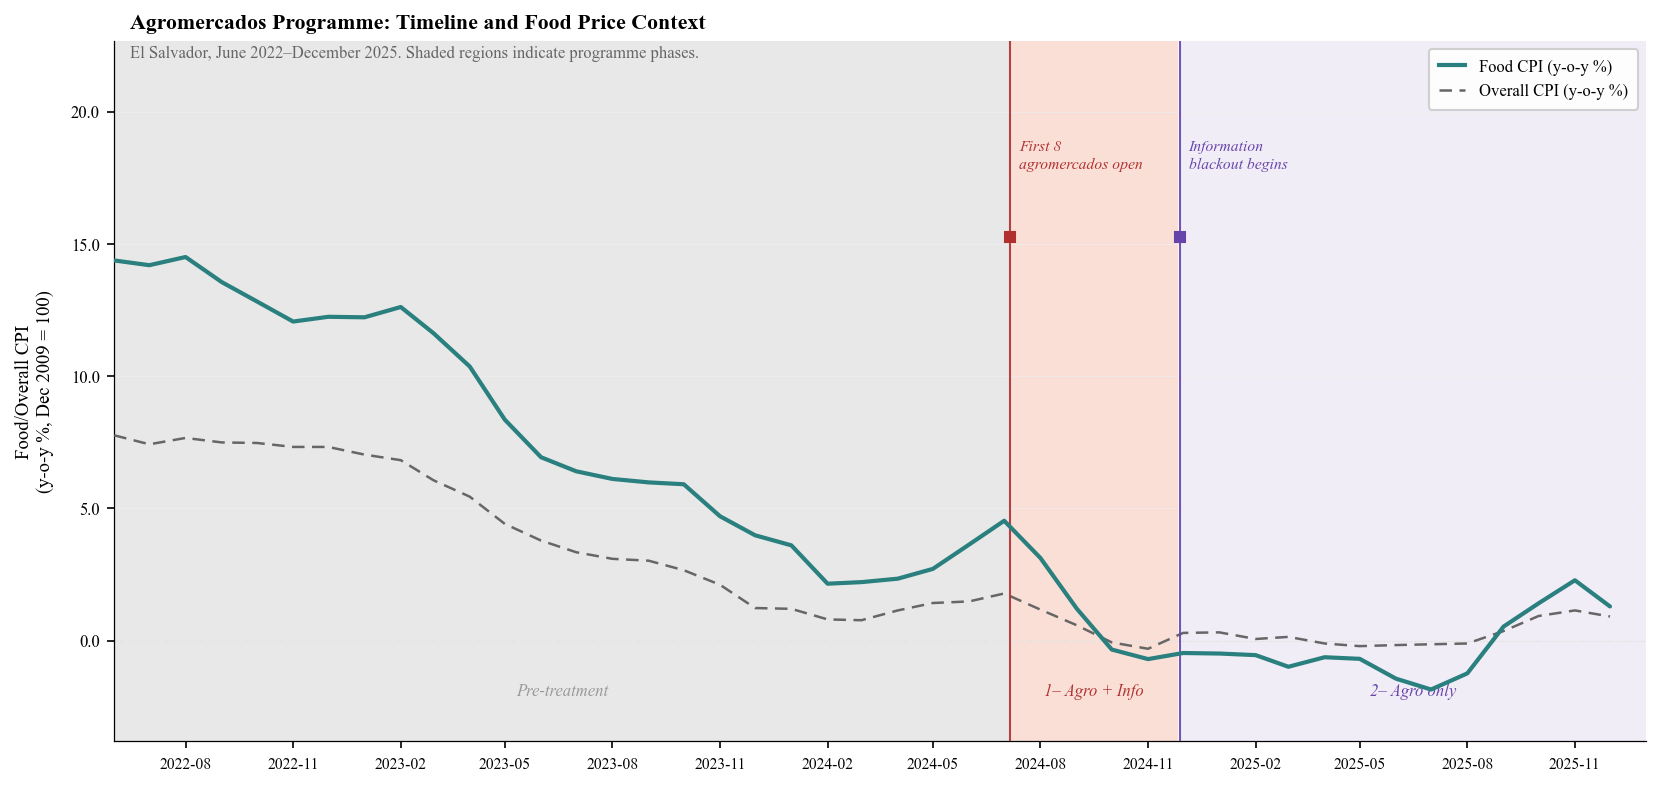

Saved → /Users/amh/Desktop/CEU-EDP/THESIS/Figures/programme.[pdf/png]


In [195]:
"""
fig_programme_timeline.py  —  Hernández (2026)
Uses CPI_clean-2.csv (wide format).
CHANGE: 'Programme reaches 60+ sites' marker removed per supervisor feedback.
"""

import os
import pandas as pd
import numpy  as np
import matplotlib.pyplot  as plt
import matplotlib.dates   as mdates
import matplotlib.patches as mpatches
import matplotlib.ticker  as mticker
from   matplotlib.lines   import Line2D

# ── 0. RCPARAMS ───────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family'        : 'serif',
    'font.serif'         : ['Times New Roman', 'DejaVu Serif', 'Georgia'],
    'font.size'          : 9,
    'axes.labelsize'     : 9,
    'xtick.labelsize'    : 7.5,
    'ytick.labelsize'    : 8,
    'axes.spines.top'    : False,
    'axes.spines.right'  : False,
    'axes.grid'          : False,
    'figure.dpi'         : 150,
    'savefig.dpi'        : 300,
    'savefig.bbox'       : 'tight',
    'savefig.pad_inches' : 0.1,
})

# ── 1. LOAD & PARSE wide-format CSV ──────────────────────────────────────────
PATH = '/Users/amh/Desktop/CEU-EDP/THESIS/Data/defensoria/cpi/CPI_clean.csv'

raw = pd.read_csv(PATH, header=[0, 1], index_col=0, encoding='utf-8-sig')

MONTH = {'Jan':1,'Feb':2,'Mar':3,'Abr':4,'May':5,'Jun':6,
         'Jul':7,'Ago':8,'Sep':9,'Oct':10,'Nov':11,'Dic':12,
         'Ene':1}

def parse_wide(row_label):
    """Extract a time-series from a labelled row in the wide CSV."""
    row = raw.loc[raw.index.str.strip() == row_label].squeeze()
    dates, vals = [], []
    for (yr_col, mo_col), v in row.items():
        year = int(yr_col.replace('y_', ''))
        mo   = MONTH.get(mo_col.strip())
        if mo is None: continue
        try:
            dates.append(pd.Timestamp(year=year, month=mo, day=1))
            vals.append(float(v))
        except: continue
    return pd.DataFrame({'date': dates, 'yoy': vals}).sort_values('date').reset_index(drop=True)

food    = parse_wide('Alimentos y bebidas no alcohólicas')
overall = parse_wide('Índice general')

print(f"Food:    {len(food)} obs | {food.date.iloc[0].date()} → {food.date.iloc[-1].date()}")
print(f"Overall: {len(overall)} obs | {overall.date.iloc[0].date()} → {overall.date.iloc[-1].date()}")

# ── 2. COLOURS & DATES ───────────────────────────────────────────────────────
C_FOOD    = '#2a7f7f'   # teal
C_OVERALL = '#666666'   # grey dashed
C_P1      = '#f7c5b5'   # salmon / Phase 1
C_P2      = '#e0d8ef'   # lavender / Phase 2
C_PRE     = '#e8e8e8'   # light grey / pre-treatment

P1_START  = pd.Timestamp('2024-07-06')
P1_END    = pd.Timestamp('2024-11-27')
P2_START  = pd.Timestamp('2024-11-28')
XMIN      = pd.Timestamp('2022-06-01')
XMAX      = food.date.max() + pd.DateOffset(months=1)

# ── 3. LAYOUT ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))

y_lo = min(food.yoy.min(), overall.yoy.min())
y_hi = max(food.yoy.max(), overall.yoy.max())
yspan = y_hi - y_lo
YMIN = y_lo - yspan * 0.12
YMAX = y_hi + yspan * 0.50   # headroom for annotations

ax.set_xlim(XMIN, XMAX)
ax.set_ylim(YMIN, YMAX)

# ── 4. PHASE BANDS ────────────────────────────────────────────────────────────
ax.axvspan(XMIN,    P1_START, facecolor=C_PRE, alpha=1.0, zorder=0)
ax.axvspan(P1_START, P1_END,  facecolor=C_P1,  alpha=0.55, zorder=0)
ax.axvspan(P2_START, XMAX,    facecolor=C_P2,  alpha=0.45, zorder=0)

# ── 5. REFERENCE LINE & GRID ─────────────────────────────────────────────────
ax.axhline(0, color='#aaaaaa', linewidth=0.5, linestyle=':', zorder=1)
ax.yaxis.grid(True, color='#eeeeee', linewidth=0.35, zorder=0)

# ── 6. SERIES ────────────────────────────────────────────────────────────────
ax.plot(food.date,    food.yoy,    color=C_FOOD,    linewidth=2.0,
        zorder=4, solid_capstyle='round', label='Food CPI (y-o-y %)')
ax.plot(overall.date, overall.yoy, color=C_OVERALL, linewidth=1.2,
        zorder=3, linestyle='--', dashes=(5, 3),
        solid_capstyle='round', label='Overall CPI (y-o-y %)')

# ── 7. EVENT MARKERS — solid lines only; dashed red line REMOVED ─────────────
EVENTS = [
    # (date, color, linestyle, label_text, y_text_frac)
    (pd.Timestamp('2024-07-06'), '#b03030', '-',
     'First 8\nagromercados open', 0.86),
    (pd.Timestamp('2024-11-28'), '#6644aa', '-',
     'Information\nblackout begins',  0.86),
    # ── 'Programme reaches 60+ sites' dashed line REMOVED ──
]

for xdate, col, ls, label, yfrac in EVENTS:
    ax.axvline(xdate, color=col, linewidth=1.0,
               linestyle=ls, zorder=3, alpha=0.9)
    # Coloured square marker at top of line
    ymarker = YMIN + (YMAX - YMIN) * 0.72
    ax.plot(xdate, ymarker, marker='s', markersize=5,
            color=col, zorder=5, clip_on=False)
    # Annotation text
    ytext = YMIN + (YMAX - YMIN) * yfrac
    ax.text(xdate + pd.Timedelta(days=8), ytext, label,
            fontsize=7.5, color=col, va='top',
            linespacing=1.4, style='italic', zorder=6)

# ── 8. PHASE LABELS (bottom of band, inside data area) ───────────────────────
Y_PHASE = YMIN + (YMAX - YMIN) * 0.06   # sits just above x-axis

def xmid(a, b): return a + (b - a) / 2

ax.text(xmid(XMIN, P1_START),  Y_PHASE, 'Pre-treatment',
        ha='center', va='bottom', fontsize=8,
        color='#999999', style='italic')
ax.text(xmid(P1_START, P1_END), Y_PHASE, '1– Agro + Info',
        ha='center', va='bottom', fontsize=8,
        color='#b03030', style='italic')
ax.text(xmid(P2_START, XMAX),  Y_PHASE, '2– Agro only',
        ha='center', va='bottom', fontsize=8,
        color='#6644aa', style='italic')

# ── 9. FIGURE TITLE & SUBTITLE ────────────────────────────────────────────────
fig.text(0.01, 1.01, 'Agromercados Programme: Timeline and Food Price Context',
         transform=ax.transAxes,
         fontsize=10.5, fontweight='bold', va='bottom')
fig.text(0.01, 0.97, 'El Salvador, June 2022–December 2025. Shaded regions indicate programme phases.',
         transform=ax.transAxes,
         fontsize=8, color='#666666', va='bottom')

# ── 10. AXES ──────────────────────────────────────────────────────────────────
ax.set_xlabel('', labelpad=4)
ax.set_ylabel('Food/Overall CPI\n(y-o-y %, Dec 2009 = 100)', labelpad=8)

ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[2, 5, 8, 11]))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax.get_xticklabels(), rotation=0, ha='center')

ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%.1f'))
for sp in ['left', 'bottom']:
    ax.spines[sp].set_linewidth(0.6)

# ── 11. LEGEND ────────────────────────────────────────────────────────────────
ax.legend(loc='upper right',
          handles=[
              Line2D([0],[0], color=C_FOOD,    linewidth=2.0, label='Food CPI (y-o-y %)'),
              Line2D([0],[0], color=C_OVERALL, linewidth=1.2, linestyle='--',
                     dashes=(5,3), label='Overall CPI (y-o-y %)'),
          ],
          fontsize=8, handlelength=1.6,
          borderpad=0.6, frameon=True,
          edgecolor='#cccccc', framealpha=0.9)

# ── 12. SAVE ──────────────────────────────────────────────────────────────────
BASE = '/Users/amh/Desktop/CEU-EDP/THESIS/Figures/programme'
os.makedirs(os.path.dirname(BASE), exist_ok=True)
fig.tight_layout(pad=0.5)
fig.savefig(BASE + '.pdf', format='pdf')
fig.savefig(BASE + '.png', format='png')
plt.show()
print(f'Saved → {BASE}.[pdf/png]')